In [1]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
from collections import deque
import os
import math
import random
import re
from pathlib import Path
from scipy import optimize
import matplotlib.cm as cm
from matplotlib.patches import Polygon, Patch, Rectangle
from scipy.spatial import ConvexHull
from sklearn.manifold import MDS, TSNE, Isomap
from sklearn.metrics import pairwise_distances
from collections import defaultdict, OrderedDict

In [2]:
#names of the dot files that contain the data:
data_name_1 = "../Dataset/JazzNetwork.dot"
data_name_2 = "../Dataset/LesMiserables.dot" #
data_name_3 = "../Dataset/devonshiredebate_withclusters.dot"
data_name_4 = "../Dataset/g.20.27.dot"
data_name_5 = "../Dataset/g.42.88.dot"
data_name_6 = "../Dataset/GD97.dot"
data_name_7 = "../Dataset/LeagueNetwork.dot" 
data_name_8 = "../Dataset/mesh graph.dot"
data_name_9 = "../Dataset/noname.dot" 
data_name_10 = "../Dataset/polblogs.dot"
data_name_11 = "../Dataset/robot graph.dot"
data_name_12 = "../Dataset/rome.dot"
data_name_13 = "../Dataset/snail graph.dot"

file_name = data_name_1

# Functions

## step 1

In [3]:
def step1(filename):
    graph = pydot.graph_from_dot_file(data_name_2)[0]
    def get_unique_random_position(existing_positions, max_attempts=100):
        """Generate a unique random position that does not overlap significantly with existing ones."""
        for _ in range(max_attempts):
            pos = np.random.rand(2)
            if all(np.linalg.norm(pos - existing) > 0.05 for existing in existing_positions.values()):
                return pos
        return np.random.rand(2)  # Fallback if no unique position is found

    # Get the list of nodes and edges
    nodes = graph.get_nodes()
    edges = graph.get_edges()

    # Create a dictionary to store node positions
    node_positions = {}

    # Initialize the plot
    fig, ax = plt.subplots()

    # Generate a random position and plot a circle for each node
    for node in nodes:
        pos = np.random.rand(2)
        node_positions[node.get_name()] = pos
        ax.add_patch(Circle(pos, radius=0.03, edgecolor='black', facecolor='skyblue'))
        ax.text(pos[0], pos[1], node.get_name(), fontsize=10, ha='center', va='center')

    # Draw lines to connect the circles based on edges
    for edge in edges:
        source_pos = node_positions[edge.get_source()]
        destination_pos = node_positions[edge.get_destination()]
        ax.add_patch(ConnectionPatch(
            source_pos, destination_pos, 'data', 'data', color='#A9A9A9', # dark grey lines
            linestyle=':', linewidth=0.3  # Make lines thinner and dotted
        ))


    # Set plot limits
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Hide the axes
    ax.axis('off')

    plt.show()

    # random 2
    def get_unique_random_position(existing_positions, max_attempts=100):
        """Generate a unique random position that does not overlap significantly with existing ones."""
        for _ in range(max_attempts):
            pos = (0.1 + (0.9 - 0.1) * np.random.rand(2))*10
            if all(np.linalg.norm(pos - existing) > 0.5 for existing in existing_positions.values()):
                return pos
        return np.random.rand(2)  # Fallback if no unique position is found

    # Get nodes and edges
    nodes = graph.get_nodes()
    edges = graph.get_edges()

    # Store node positions
    node_positions = {}

    # Initialize the plot
    fig, ax = plt.subplots(figsize=(8, 8))

    # Assign unique random positions to nodes
    for node in nodes:
        node_name = node.get_name()
        if node_name.isdigit():  # Ensure we ignore special characters
            node_positions[node_name] = get_unique_random_position(node_positions)
            ax.add_patch(Circle(node_positions[node_name], radius=0.28, edgecolor='black', facecolor='skyblue'))
            ax.text(node_positions[node_name][0], node_positions[node_name][1], node_name, fontsize=8, ha='center', va='center')

    # Draw edges with weights
    for edge in edges:
        source, target = edge.get_source(), edge.get_destination()
        if source.isdigit() and target.isdigit():
            source_pos = node_positions[source]
            target_pos = node_positions[target]
            weight = edge.get_attributes().get("weight", "1")  # Get weight, default to 1
            ax.add_patch(ConnectionPatch(
                source_pos, target_pos, 'data', 'data', color='#A9A9A9', linestyle=':', linewidth=0.6
            ))
            mid_pos = (source_pos + target_pos) / 2  # Midpoint for weight label
            ax.text(mid_pos[0], mid_pos[1], weight, fontsize=6, color='red', ha='center', va='center')

    # Set plot limits
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    plt.show()

    #circle layout

    # Convert pydot graph to networkx graph
    G_nx = nx.nx_pydot.from_pydot(graph)

    # Get nodes and their degrees
    node_degrees = dict(G_nx.degree())
    sorted_nodes = sorted(node_degrees, key=node_degrees.get, reverse=True)

    # Calculate positions in a circular layout
    num_nodes = len(sorted_nodes)
    angles = np.linspace(0, 2 * np.pi, num_nodes, endpoint=False)
    radius = 5

    node_positions = {}
    for i, node in enumerate(sorted_nodes):
        angle = angles[i]
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        node_positions[node] = (x, y)

    # Initialize the plot
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot nodes
    for node, pos in node_positions.items():
        ax.add_patch(Circle(pos, radius=0.1, edgecolor='black', facecolor='skyblue'))
        ax.text(pos[0], pos[1], node, fontsize=8, ha='center', va='center')

    # Plot edges
    for edge in G_nx.edges():
        source_pos = node_positions[edge[0]]
        target_pos = node_positions[edge[1]]
        ax.add_patch(ConnectionPatch(
            source_pos, target_pos, 'data', 'data', color='#A9A9A9', linestyle=':', linewidth=0.6
        ))


    # Set plot limits
    ax.set_xlim(-radius-1, radius+1)
    ax.set_ylim(-radius-1, radius+1)
    ax.axis('off')

    plt.show()

## step 2

In [5]:

def parse_dot_file(file_path):
    graph = pydot.graph_from_dot_file(file_path)[0]
    adjacency_list = {}

    #list of edges run for each node of the graph

    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        if src not in adjacency_list:
            adjacency_list[src] = []
        if dst not in adjacency_list:
            adjacency_list[dst] = []
        adjacency_list[src].append(dst)
        adjacency_list[dst].append(src)  # for undirected graph

    return adjacency_list

def extract_edges(graph):
    edges = []
    for node, neighbors in graph.items():
        for neighbor in neighbors:
            edge = (node, neighbor)
            if edge not in edges and (neighbor, node) not in edges:
                edges.append(edge)
    return edges

def bfs_tree(graph, root):
    visited = set()
    queue = deque([root])
    bfs_tree = {root: []}
    
    while queue:
        node = queue.popleft()
        visited.add(node)

        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
                bfs_tree[node].append(neighbor)
                bfs_tree[neighbor] = []
    
    return bfs_tree

def dfs_tree(graph, root, visited=None, tree=None):
    if visited is None:
        visited = set()
    if tree is None:
        tree = {root: []}

    visited.add(root)

    for neighbor in graph.get(root, []):
        if neighbor not in visited:
            tree[root].append(neighbor)
            tree[neighbor] = []
            dfs_tree(graph, neighbor, visited, tree)

    return tree

def missing_edges(spanning_tree, full_edge_list):
    # edges of the spanning tree
    sp_edges = [(node, child) for node, children in spanning_tree.items() for child in children]
    sp_edges_set = set(sp_edges)
    # all edges of the graph
    full_edges_set = set(full_edge_list)
    # edges not present in the spanning tree
    non_tree_edges = full_edges_set - sp_edges_set
    return non_tree_edges

def compute_postorder_spacing(tree, node, spacing, boundaries, min_separation=1.0):
    """ Postorder traversal to compute spacing between nodes. """
    if node not in tree or not tree[node]:  # No children
        boundaries[node] = (spacing[node], spacing[node])
        return
    
    children = tree[node]
    
    # Process all children first
    for child in children:
        compute_postorder_spacing(tree, child, spacing, boundaries, min_separation)
    
    # Special handling for nodes with 3+ children
    if len(children) >= 3:
        # Ensure adequate spacing between all children
        for i in range(len(children) - 1):
            current_child = children[i]
            next_child = children[i + 1]
            
            # Get current right boundary and next left boundary
            _, current_right = boundaries[current_child]
            next_left, _ = boundaries[next_child]
            
            # If children are too close, shift the next child and all its subtree
            if next_left - current_right < min_separation:
                shift_amount = (current_right + min_separation) - next_left
                
                # Shift the next child and all nodes in its subtree
                shift_subtree(tree, next_child, shift_amount, spacing, boundaries)
    
    # Calculate leftmost and rightmost boundaries from children
    leftmost = min(boundaries[child][0] for child in children)
    rightmost = max(boundaries[child][1] for child in children)
    
    # Center the parent node with respect to its children
    midpoint = (leftmost + rightmost) / 2
    spacing[node] = midpoint
    
    # Set the parent's boundaries to encompass all children
    # Add some padding to ensure parent doesn't overlap with other nodes
    padding = 0.5  # Adjust as needed
    boundaries[node] = (leftmost - padding, rightmost + padding)

def shift_subtree(tree, node, shift_amount, spacing, boundaries):
    """ Shift a node and all its descendants by a specified amount. """
    # Shift current node
    spacing[node] += shift_amount
    left, right = boundaries[node]
    boundaries[node] = (left + shift_amount, right + shift_amount)
    
    # Recursively shift all descendants
    if node in tree:
        for child in tree[node]:
            shift_subtree(tree, child, shift_amount, spacing, boundaries)

def not_using_compute_postorder_spacing(tree, node, spacing, boundaries):
    """ Postorder traversal to compute spacing between nodes. """
    if node not in tree:
        return

    leftmost, rightmost = None, None

    for child in tree[node]:
        compute_postorder_spacing(tree, child, spacing, boundaries)
        
        # Set boundaries for subtree
        if leftmost is None:
            leftmost = boundaries[child][0]
        rightmost = boundaries[child][1]

    if leftmost is not None:
        # Assign horizontal spacing based on children's boundaries
        boundaries[node] = (leftmost, rightmost)
        spacing[node] = (leftmost + rightmost) / 2
    else:
        # Leaf node case
        boundaries[node] = (spacing[node], spacing[node])

def assign_preorder_positions(tree, node, x_positions, y_positions, depth, spacing):
    """ Preorder traversal to assign final x and y coordinates. """
    x_positions[node] = spacing[node]
    y_positions[node] = -depth  # Negative depth for layered layout

    for child in tree[node]:
        assign_preorder_positions(tree, child, x_positions, y_positions, depth + 1, spacing)

def draw_layered_tree(tree, title="Level-Based Tree Layout", show_node_ids=True):
    """ Draw the tree with improved positioning. """
    spacing = {}  # Computed x-coordinates
    boundaries = {}  # Store subtree boundaries

    # Assign initial x-coordinates (order of appearance)
    order = 0
    for node in tree:
        spacing[node] = order
        order += 2  # Assign initial spacing (will be refined in postorder)

    # Compute proper spacing using postorder traversal
    root = next(iter(tree))  # Get root node
    compute_postorder_spacing(tree, root, spacing, boundaries)

    # Assign final positions using preorder traversal
    x_positions, y_positions = {}, {}
    assign_preorder_positions(tree, root, x_positions, y_positions, depth=0, spacing=spacing)

    # Draw the tree
    plt.figure(figsize=(8, 6))
    for parent, children in tree.items():
        for child in children:
            x1, y1 = x_positions[parent], y_positions[parent]
            x2, y2 = x_positions[child], y_positions[child]
            plt.plot([x1, x2], [y1, y2], 'k-', linewidth=0.2)

    if show_node_ids:
        for node, (x, y) in zip(x_positions.keys(), zip(x_positions.values(), y_positions.values())):
            plt.text(x, y, node, ha='center', va='center', fontsize=5,
                     bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))
    else: # without node ids
        for node, (x, y) in zip(x_positions.keys(), zip(x_positions.values(), y_positions.values())):
            plt.text(x, y, " ", ha='center', va='center', fontsize=2,
                     bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))

    # Draw red dotted lines at each level
    unique_levels = sorted(set(y_positions.values()), reverse=True)
    for i, level in enumerate(unique_levels):
        plt.axhline(y=level, color='red', linestyle='--', linewidth=0.5)
        plt.text(min(x_positions.values()) - 15.5, level + 0.1, f"level {i}", color='red', fontsize=6, va='center')

    plt.title(title)
    plt.axis('off')
    plt.show()

def draw_tree_with_all_edges(non_tree_edges, tree, title="Level-Based Tree Layout", random=True):
    """ Draw the tree with improved positioning. """
    spacing = {}  # Computed x-coordinates
    boundaries = {}  # Store subtree boundaries

    # Assign initial x-coordinates (order of appearance)
    order = 0
    for node in tree:
        spacing[node] = order
        order += 2  # Assign initial spacing (will be refined in postorder)

    # Compute proper spacing using postorder traversal
    root = next(iter(tree))  # Get root node
    compute_postorder_spacing(tree, root, spacing, boundaries)

    # Assign final positions using preorder traversal
    x_positions, y_positions = {}, {}
    assign_preorder_positions(tree, root, x_positions, y_positions, depth=0, spacing=spacing)

    # Draw the tree
    plt.figure(figsize=(8, 6))
    for parent, children in tree.items():
        for child in children:
            x1, y1 = x_positions[parent], y_positions[parent]
            x2, y2 = x_positions[child], y_positions[child]
            plt.plot([x1, x2], [y1, y2], 'k-', linewidth=0.2)

    for node, (x, y) in zip(x_positions.keys(), zip(x_positions.values(), y_positions.values())):
        plt.text(x, y, node, ha='center', va='center', fontsize=2,
                 bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))
    if random:
        # draw the non-tree edges as bended lines between nodes with different colors:
        colors = plt.cm.rainbow(np.linspace(0, 1, len(non_tree_edges)))
        for edge, color in zip(non_tree_edges, colors):
            x1, y1 = x_positions[edge[0]], y_positions[edge[0]]
            x2, y2 = x_positions[edge[1]], y_positions[edge[1]]

            # Generate random curvature
            curvature = np.random.uniform(-0.2, 0.2)

            # Calculate control points for Bezier curve
            ctrl_x = (x1 + x2) / 2 + curvature * (y2 - y1)
            ctrl_y = (y1 + y2) / 2 + curvature * (x1 - x2)

            # Plot Bezier curve
            bezier_x = [x1, ctrl_x, x2]
            bezier_y = [y1, ctrl_y, y2]
            plt.plot(bezier_x, bezier_y, linestyle='--', linewidth=0.2, color=color)
    else:
        for edge in non_tree_edges:
            x1, y1 = x_positions[edge[0]], y_positions[edge[0]]
            x2, y2 = x_positions[edge[1]], y_positions[edge[1]]
            plt.plot([x1, x2], [y1, y2], 'b--', linewidth=0.2)

    plt.title(title)
    plt.axis('off')
    plt.show()

def save_drawing(tree, image_title):
    """ Draw the tree with improved positioning. """
    spacing = {}  # Computed x-coordinates
    boundaries = {}  # Store subtree boundaries

    # Assign initial x-coordinates (order of appearance)
    order = 0
    for node in tree:
        spacing[node] = order
        order += 2  # Assign initial spacing (will be refined in postorder)

    # Compute proper spacing using postorder traversal
    root = next(iter(tree))  # Get root node
    compute_postorder_spacing(tree, root, spacing, boundaries)

    # Assign final positions using preorder traversal
    x_positions, y_positions = {}, {}
    assign_preorder_positions(tree, root, x_positions, y_positions, depth=0, spacing=spacing)

    # Draw the tree
    plt.figure(figsize=(8, 6))
    for parent, children in tree.items():
        for child in children:
            x1, y1 = x_positions[parent], y_positions[parent]
            x2, y2 = x_positions[child], y_positions[child]
            plt.plot([x1, x2], [y1, y2], 'k-', linewidth=0.2)

    for node, (x, y) in zip(x_positions.keys(), zip(x_positions.values(), y_positions.values())):
        plt.text(x, y, node, ha='center', va='center', fontsize=8,
                bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='circle'))

    plt.title(image_title)
    plt.axis('off')
    plt.savefig(image_title)


## step 3

In [6]:
def draw_colorful_force_directed_graph_fruchterman_reingold_inertia(file_path, iterations=100, C=1.0, 
                                                  save_frames=True, output_dir="../Outputs_force", 
                                                  convergence_threshold=0.001, display_node_id=False):
    # Create output directory if it doesn't exist
    output_dir = os.path.join(output_dir, os.path.basename(file_path))
    if save_frames and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    # Extract file name from path for naming outputs
    file_name = os.path.basename(file_path)
    graph_name = os.path.splitext(file_name)[0]
    # Clean graph name tu use them as filename
    graph_name = re.sub(r'[^\w\-_.]', '_', graph_name)
    
    # Load the graph directly with NetworkX
    nx_graph = nx.nx_pydot.read_dot(file_path)
    # Extract nodes and edges
    nodes = list(nx_graph.nodes())
    edges = list(nx_graph.edges())
    # number of nodes
    n = len(nodes)
    
    

    # Calculate node degrees for coloring
    node_degrees = {node: len(list(nx_graph.neighbors(node))) for node in nodes}
    min_degree = min(node_degrees.values()) if node_degrees else 0
    max_degree = max(node_degrees.values()) if node_degrees else 1
    # Create colormap for degrees
    cmap = plt.cm.cool
    normalize = plt.Normalize(min_degree, max_degree)
    
    # Get node degrees and calculate masses for inertia
    node_masses = {node: 1 + node_degrees[node] / 2 for node in nodes}

    # SCALING: Calculate canvas size based on number of nodes
    scale_factor = math.sqrt(n) / 4
    width = height = max(1.0, scale_factor)
    area = width * height
    # SCALING: Adjust figure size based on number of nodes
    fig_width = max(8, min(24, 8 + math.sqrt(n)))
    fig_height = max(6, min(20, 6 + math.sqrt(n)))
    # SCALING: Calculate node size, font size and edge_width inversely proportional n
    node_size = max(30, min(500, 800 / math.sqrt(n)))
    font_size = max(4, min(12, 14 / math.sqrt(n)))
    edge_width = max(0.5, min(5, 5 / math.sqrt(n)))
    
    # Optimal force constant l with updated formula l = C · √(area/n) (SCALAR)
    l = C * math.sqrt(area / n)
    
    # Initial temperature set to 0.1 that will then decrease with each iteration
    t = 0.1
    
    # Initialize node positions randomly within the scaled canvas
    pos = {node: np.array([random.random() * width, random.random() * height]) for node in nodes}
    
    # Prepare the figure with scaled dimensions
    plt.figure(figsize=(fig_width, fig_height))
    
    # Variables to track convergence
    old_positions = {node: np.array([0.0, 0.0]) for node in nodes}
    max_movement = float('inf')
    
    i = 0
    while i < iterations and max_movement > convergence_threshold:
        #t = 1 / (i + 1)
        # Save old positions to calculate movement
        for node in nodes:
            old_positions[node] = np.copy(pos[node])
        
        # Initialize force vectors for each node
        f_rep = {node: np.array([0.0, 0.0]) for node in nodes}
        f_attr = {node: np.array([0.0, 0.0]) for node in nodes}
        f_total = {node: np.array([0.0, 0.0]) for node in nodes}
        
        # PHASE 1: Calculate REPULSIVE forces (between all nodes)
        for u in nodes:
            for v in nodes:
                if u != v:
                    # Vector from u to v
                    delta = pos[v] - pos[u]
                    
                    # Euclidean distance between u and v
                    distance = max(0.01, np.linalg.norm(delta))
                    
                    # Calculate repulsive force
                    repulsive_magnitude = l * l / distance
                    
                    # Calculate direction
                    direction = delta / distance
                    
                    # Store repulsive force
                    f_rep[u] -= direction * repulsive_magnitude
        
        # PHASE 2: Calculate ATTRACTIVE forces (only between nodes connected by edges)
        for u, v in edges:
            # Vector from u to v
            delta = pos[v] - pos[u]
            
            # Euclidean distance between u and v
            distance = max(0.01, np.linalg.norm(delta))
            
            # Calculate attractive force
            attractive_magnitude = distance * distance / l
            
            # Calculate direction
            direction = delta / distance
            
            # Apply attraction to both u
            f_attr[u] += direction * (attractive_magnitude / node_masses[u])
        
        # PHASE 3: Calculate total force and update positions
        for v in nodes:
            # Combine repulsive and attractive forces
            f_total[v] = f_rep[v] + f_attr[v]
            
            # Update position
            pos[v] = pos[v] + t * f_total[v]
            
            # Constrain nodes within drawing space
            pos[v][0] = min(width - 0.01, max(0.01, pos[v][0]))
            pos[v][1] = min(height - 0.01, max(0.01, pos[v][1]))
        
        # Calculate maximum movement among all nodes
        movements = [np.linalg.norm(pos[node] - old_positions[node]) for node in nodes]
        max_movement = max(movements) if movements else 0
        
        
        # Draw the graph every 10 iterations or at the last iteration or if it converged to a minimum movement
        if i % 10 == 0 or i == iterations - 1 or max_movement <= convergence_threshold:
            plt.clf()
            
            # Draw edges
            for u, v in edges:
                plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='gray', alpha=0.7, zorder=1, linewidth=edge_width)
            
            # Draw nodes with color based on degree
            for node in nodes:
                node_color = cmap(normalize(node_degrees[node]))
                plt.scatter(pos[node][0], pos[node][1], s=node_size, color=node_color, edgecolor='black', zorder=2)
                if display_node_id:
                    plt.text(pos[node][0], pos[node][1], str(node), ha='center', va='center', fontsize=font_size, zorder=3)
                else:
                    plt.text(pos[node][0], pos[node][1], " ", ha='center', va='center', fontsize=font_size, zorder=3)
            
            # Add colorbar
            if i % 10 == 0 or i == iterations - 1 or max_movement <= convergence_threshold:
                sm = plt.cm.ScalarMappable(cmap=cmap, norm=normalize)
                sm.set_array([])
                cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.75)
                cbar.set_label('Node Degree')
            
            # Set axis limits with proper margin
            margin = 0.3 * width
            plt.xlim(-margin, width + margin)
            plt.ylim(-margin, height + margin)
            plt.title(f'Fruchterman-Reingold (C={C}) - {graph_name} - Iteration {i+1}\nMax movement: {max_movement:.6f}')
            plt.axis('off')
            plt.tight_layout()
            
            # Save the current frame
            if save_frames:
                frame_path = os.path.join(output_dir, f"{graph_name}_FR_C{C}_iter_{i+1:04d}.png")
                plt.savefig(frame_path, dpi=150)
                print(f"Saved frame {i+1} to {frame_path}")
            
            # Pause to allow interface update
            plt.pause(0.01)
        
        i += 1
        # Proportional cooling
        t = t * 0.95
    
    # Show convergence message
    if max_movement <= convergence_threshold:
        print(f"Algorithm converged at iteration {i} with maximum movement {max_movement:.6f}")
    else:
        print(f"Algorithm terminated after {i} iterations. Final movement: {max_movement:.6f}")
    
    plt.show()
    
    
def draw_force_directed_graph_fruchterman_reingold_inertia(file_path, iterations=100, C=1.0, 
                                                  save_frames=True, output_dir="../Outputs_force", 
                                                  convergence_threshold=0.001, display_node_id=False):
    # Create output directory if it doesn't exist
    output_dir = os.path.join(output_dir, os.path.basename(file_path))
    if save_frames and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    # Extract file name from path for naming outputs
    file_name = os.path.basename(file_path)
    graph_name = os.path.splitext(file_name)[0]
    # Clean graph name tu use them as filename
    graph_name = re.sub(r'[^\w\-_.]', '_', graph_name)
    
    # Load the graph directly with NetworkX
    nx_graph = nx.nx_pydot.read_dot(file_path)
    # Extract nodes and edges
    nodes = list(nx_graph.nodes())
    edges = list(nx_graph.edges())
    # number of nodes
    n = len(nodes)
    

    # Get node degrees and calculate masses for inertia
    node_degrees = {node: len(list(nx_graph.neighbors(node))) for node in nodes}
    node_masses = {node: 1 + node_degrees[node] / 2 for node in nodes}

    # SCALING: Calculate canvas size based on number of nodes
    scale_factor = math.sqrt(n) / 4
    width = height = max(1.0, scale_factor)
    area = width * height
    # SCALING: Adjust figure size based on number of nodes
    fig_width = max(8, min(24, 8 + math.sqrt(n)))
    fig_height = max(6, min(20, 6 + math.sqrt(n)))
    # SCALING: Calculate node size, font size and edge_width inversely proportional n
    node_size = max(30, min(500, 800 / math.sqrt(n)))
    font_size = max(4, min(12, 14 / math.sqrt(n)))
    edge_width = max(0.5, min(5, 5 / math.sqrt(n)))
    
    # Optimal force constant l with updated formula l = C · √(area/n) (SCALAR)
    l = C * math.sqrt(area / n)
    
    # Initial temperature set to 0.1 that will then decrease with each iteration
    t = 0.1
    
    # Initialize node positions randomly within the scaled canvas
    pos = {node: np.array([random.random() * width, random.random() * height]) for node in nodes}
    
    # Prepare the figure with scaled dimensions
    plt.figure(figsize=(fig_width, fig_height))
    
    # Variables to track convergence
    old_positions = {node: np.array([0.0, 0.0]) for node in nodes}
    max_movement = float('inf')
    
    i = 0
    while i < iterations and max_movement > convergence_threshold:
        #t = 1 / (i + 1)
        # Save old positions to calculate movement
        for node in nodes:
            old_positions[node] = np.copy(pos[node])
        
        # Initialize force vectors for each node
        f_rep = {node: np.array([0.0, 0.0]) for node in nodes}
        f_attr = {node: np.array([0.0, 0.0]) for node in nodes}
        f_total = {node: np.array([0.0, 0.0]) for node in nodes}
        
        # PHASE 1: Calculate REPULSIVE forces (between all nodes)
        for u in nodes:
            for v in nodes:
                if u != v:
                    # Vector from u to v
                    delta = pos[v] - pos[u]
                    
                    # Euclidean distance between u and v
                    distance = max(0.01, np.linalg.norm(delta))
                    
                    # Calculate repulsive force
                    repulsive_magnitude = l * l / distance
                    
                    # Calculate direction
                    direction = delta / distance
                    
                    # Store repulsive force
                    f_rep[u] -= direction * repulsive_magnitude
        
        # PHASE 2: Calculate ATTRACTIVE forces (only between nodes connected by edges)
        for u, v in edges:
            # Vector from u to v
            delta = pos[v] - pos[u]
            
            # Euclidean distance between u and v
            distance = max(0.01, np.linalg.norm(delta))
            
            # Calculate attractive force
            attractive_magnitude = distance * distance / l
            
            # Calculate direction
            direction = delta / distance
            
            # Apply attraction to u
            f_attr[u] += direction * (attractive_magnitude / node_masses[u])
        
        # PHASE 3: Calculate total force and update positions
        for v in nodes:
            # Combine repulsive and attractive forces
            f_total[v] = f_rep[v] + f_attr[v]
            
            # Update position
            pos[v] = pos[v] + t * f_total[v]
            
            # Constrain nodes within drawing space
            pos[v][0] = min(width - 0.01, max(0.01, pos[v][0]))
            pos[v][1] = min(height - 0.01, max(0.01, pos[v][1]))
        
        # Calculate maximum movement among all nodes
        movements = [np.linalg.norm(pos[node] - old_positions[node]) for node in nodes]
        max_movement = max(movements) if movements else 0
        
        
        # Draw the graph every 10 iterations or at the last iteration or if it converged to a minimum movement
        if i % 10 == 0 or i == iterations - 1 or max_movement <= convergence_threshold:
            plt.clf()
            
            # Draw edges
            for u, v in edges:
                plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='gray', alpha=0.7, zorder=1, linewidth=edge_width)
            
            # Draw nodes with scaled size
            for node in nodes:
                plt.scatter(pos[node][0], pos[node][1], s=node_size, color='skyblue', edgecolor='black', zorder=2)
                if display_node_id:
                    plt.text(pos[node][0], pos[node][1], str(node), ha='center', va='center', fontsize=font_size, zorder=3)
                else:
                    plt.text(pos[node][0], pos[node][1], " ", ha='center', va='center', fontsize=font_size, zorder=3)
            
            # Set axis limits with proper margin
            margin = 0.3 * width
            plt.xlim(-margin, width + margin)
            plt.ylim(-margin, height + margin)
            plt.title(f'Fruchterman-Reingold (C={C}) - {graph_name} - Iteration {i+1}\nMax movement: {max_movement:.6f}')
            plt.axis('off')
            plt.tight_layout()
            
            # Save the current frame
            if save_frames:
                frame_path = os.path.join(output_dir, f"{graph_name}_FR_C{C}_iter_{i+1:04d}.png")
                plt.savefig(frame_path, dpi=150)
                print(f"Saved frame {i+1} to {frame_path}")
            
            # Pause to allow interface update
            plt.pause(0.01)
        
        i += 1
        # Proportional cooling
        t = t * 0.95
    
    # Show convergence message
    if max_movement <= convergence_threshold:
        print(f"Algorithm converged at iteration {i} with maximum movement {max_movement:.6f}")
    else:
        print(f"Algorithm terminated after {i} iterations. Final movement: {max_movement:.6f}")
    
    plt.show()
    

## step 4

In [7]:
#circular layout

## step 5

In [8]:
def process_dot_file_for_subgraphs(file_path, subgraph_names):
    """
    Process a DOT file and extract specified subgraphs.
    
    Parameters:
    -----------
    file_path : str
        Path to the DOT file
    subgraph_names : list
        List of subgraph names to extract
        
    Returns:
    --------
    dict
        Dictionary with:
        - 'subgraphs': Dict mapping subgraph name to list of nodes with attributes
        - 'edges': List of edge tuples (source, target, attributes)
    """
    # Parse the DOT file
    dot_graphs = pydot.graph_from_dot_file(file_path)
    dot_graph = dot_graphs[0]  # Assume there's only one main graph
    
    # Process subgraphs
    subgraphs = {}
    subgraph_objects = {}
    
    # Extract all subgraphs
    for subgraph in dot_graph.get_subgraphs():
        name = subgraph.get_name().strip('"')
        if name in subgraph_names:
            subgraphs[name] = []
            subgraph_objects[name] = subgraph
            
            # Process nodes in this subgraph
            for node in subgraph.get_nodes():
                node_id = node.get_name().strip('"')
                attrs = {k: v.strip('"') for k, v in node.get_attributes().items()}
                # Add node with its attributes
                subgraphs[name].append((node_id, attrs))
    
    # Extract node IDs for edge filtering
    all_nodes = set()
    for name in subgraphs:
        for node_id, _ in subgraphs[name]:
            all_nodes.add(node_id)
    
    # Extract edges where both endpoints are in the included subgraphs
    edges = []
    for edge in dot_graph.get_edges():
        source = edge.get_source().strip('"')
        target = edge.get_destination().strip('"')
        
        if source in all_nodes and target in all_nodes:
            attrs = {k: v.strip('"') for k, v in edge.get_attributes().items()}
            edges.append((source, target, attrs))
    
    return {
        'subgraphs': subgraphs,
        'edges': edges
    }

def draw_colorful_FDG_FR_inertia_subgraphs(
    subgraphs_data, 
    output_name=None, 
    iterations=100, 
    C=1.0,
    save_frames=False, 
    output_dir="Output_subgraphs", 
    subgraph_names=None,
    convergence_threshold=0.001, 
    display_node_id=False,
    separation_factor=1.5,  # Controls overall scale
    subgraph_spacing=0.5    # Controls space BETWEEN subgraphs
):
    """
    Draw a force-directed graph layout with subgraphs placed in different regions,
    with each subgraph running its own force-directed layout until convergence.
    
    Parameters:
    -----------
    subgraphs_data : dict
        Dictionary with 'subgraphs' and 'edges' as returned by process_dot_file_for_subgraphs
    output_name : str, optional
        Path to save the final output image
    iterations : int, optional
        Maximum number of iterations for the algorithm
    C : float, optional
        Force constant scaling factor
    save_frames : bool, optional
        Whether to save intermediate frames
    output_dir : str, optional
        Base directory to save frames
    subgraph_names : list, optional
        List of subgraph names (used for creating subfolder)
    convergence_threshold : float, optional
        Threshold for considering the layout converged
    display_node_id : bool, optional
        Whether to display node IDs
    separation_factor : float, optional
        Controls the overall scale of the visualization
    subgraph_spacing : float, optional
        Controls the space between subgraphs (0.0=touching, 1.0=wide spacing)
    """
    # Extract subgraphs and edges
    subgraphs = subgraphs_data['subgraphs']
    edges_data = subgraphs_data['edges']
    
    # Create a subfolder name from subgraph names
    if subgraph_names:
        subfolder_name = "_".join([re.sub(r'[^\w\-_]', '_', name) for name in subgraph_names])
        if len(subfolder_name) > 50:
            subfolder_name = subfolder_name[:47] + "..."
        full_output_dir = os.path.join(output_dir, subfolder_name)
    else:
        full_output_dir = output_dir
    
    # Create output directory if it doesn't exist
    if save_frames and not os.path.exists(full_output_dir):
        os.makedirs(full_output_dir)
    
    # Create a NetworkX graph
    G = nx.DiGraph()
    
    # Track node to subgraph mapping
    node_to_subgraph = {}
    
    # Add nodes with attributes
    for subgraph_name, nodes_data in subgraphs.items():
        for node_id, attrs in nodes_data:
            G.add_node(node_id, **attrs, subgraph=subgraph_name)
            node_to_subgraph[node_id] = subgraph_name
    
    # Add edges with attributes
    for source, target, attrs in edges_data:
        G.add_edge(source, target, **attrs)
    
    # Extract nodes and edges
    nodes = list(G.nodes())
    edges = list(G.edges())
    
    # Total number of nodes
    n = len(nodes)
    
    # Number of subgraphs
    num_subgraphs = len(subgraphs)
    
    # Calculate how many nodes are in each subgraph
    subgraph_node_counts = {name: len(nodes_data) for name, nodes_data in subgraphs.items()}
    
    # Get node degrees and calculate masses
    node_degrees = {node: len(list(G.neighbors(node))) for node in nodes}
    node_masses = {node: 1 + node_degrees[node] / 2 for node in nodes}
    
    # Create colormap for subgraphs
    color_map = {}
    for i, subgraph_name in enumerate(subgraphs.keys()):
        color_map[subgraph_name] = plt.cm.tab10(i % 10)
    
    # Calculate base size for subgraph regions based on node counts
    total_nodes = sum(subgraph_node_counts.values())
    base_region_size = math.sqrt(n) / 4 * separation_factor
    
    # Determine canvas divisions based on subgraph count
    if num_subgraphs <= 1:
        grid_rows = grid_cols = 1
    elif num_subgraphs <= 2:
        grid_rows = 1
        grid_cols = 2
    elif num_subgraphs <= 4:
        grid_rows = grid_cols = 2
    else:
        grid_rows = grid_cols = math.ceil(math.sqrt(num_subgraphs))
    
    # Calculate subgraph region sizes proportionally to their node count
    # Ensure every subgraph gets at least a minimum size
    min_region_size = base_region_size * 0.5
    subgraph_sizes = {}
    for name, count in subgraph_node_counts.items():
        size = max(min_region_size, base_region_size * math.sqrt(count / max(1, total_nodes/num_subgraphs)))
        subgraph_sizes[name] = size
    
    # Calculate total width and height needed with spacing
    max_width_per_col = [0] * grid_cols
    max_height_per_row = [0] * grid_rows
    
    # Assign positions in grid and track max dimensions
    idx = 0
    subgraph_positions = {}
    for name, size in subgraph_sizes.items():
        row = idx // grid_cols
        col = idx % grid_cols
        subgraph_positions[name] = {'row': row, 'col': col, 'size': size}
        
        max_width_per_col[col] = max(max_width_per_col[col], size)
        max_height_per_row[row] = max(max_height_per_row[row], size)
        idx += 1
    
    # Calculate spacing between regions
    spacing_x = base_region_size * subgraph_spacing
    spacing_y = base_region_size * subgraph_spacing
    
    # Calculate total canvas dimensions
    total_width = sum(max_width_per_col) + spacing_x * (grid_cols - 1)
    total_height = sum(max_height_per_row) + spacing_y * (grid_rows - 1)
    
    # Now calculate actual positions with spacing
    x_offsets = [0] * grid_cols
    y_offsets = [0] * grid_rows
    running_x = 0
    for i in range(grid_cols):
        x_offsets[i] = running_x
        running_x += max_width_per_col[i] + spacing_x
    
    running_y = 0
    for i in range(grid_rows):
        y_offsets[i] = running_y
        running_y += max_height_per_row[i] + spacing_y
    
    # Assign final regions to each subgraph
    subgraph_regions = {}
    for name, pos_data in subgraph_positions.items():
        row = pos_data['row']
        col = pos_data['col']
        size = pos_data['size']
        
        # Calculate center position
        center_x = x_offsets[col] + max_width_per_col[col] / 2
        center_y = y_offsets[row] + max_height_per_row[row] / 2
        
        # Define region boundaries
        x_min = center_x - size/2
        y_min = center_y - size/2
        x_max = center_x + size/2
        y_max = center_y + size/2
        
        subgraph_regions[name] = {
            'x_min': x_min, 'x_max': x_max,
            'y_min': y_min, 'y_max': y_max,
            'center': (center_x, center_y),
            'width': size,
            'height': size,
            'radius': size / 2
        }
    
    # SCALING: Adjust figure size 
    fig_width = max(10, min(24, 8 + math.sqrt(n)))
    fig_height = max(8, min(20, 6 + math.sqrt(n)))
    
    # SCALING: Calculate node size and font size based on total nodes
    node_size = max(30, min(500, 800 / math.sqrt(n)))
    font_size = max(4, min(12, 14 / math.sqrt(n)))
    edge_width = max(0.5, min(5, 5 / math.sqrt(n)))
    
    # Set view limits for the entire canvas with padding
    view_padding = base_region_size * 0.1
    view_x_min = -view_padding
    view_y_min = -view_padding
    view_x_max = total_width + view_padding
    view_y_max = total_height + view_padding
    
    # Optimal force constant per subgraph
    subgraph_l = {}
    for name, nodes_data in subgraphs.items():
        subgraph_n = len(nodes_data)
        region = subgraph_regions[name]
        region_area = region['width'] * region['height']
        subgraph_l[name] = C * math.sqrt(region_area / max(1, subgraph_n))
    
    # Group edges by subgraph
    subgraph_edges = {name: [] for name in subgraphs.keys()}
    cross_subgraph_edges = []
    
    for u, v in edges:
        u_subgraph = node_to_subgraph[u]
        v_subgraph = node_to_subgraph[v]
        
        if u_subgraph == v_subgraph:
            subgraph_edges[u_subgraph].append((u, v))
        else:
            cross_subgraph_edges.append((u, v))
    
    # Group nodes by subgraph
    subgraph_nodes = {name: [node_id for node_id, _ in data] for name, data in subgraphs.items()}
    
    # Initialize node positions within their assigned regions
    pos = {}
    for node in nodes:
        subgraph_name = node_to_subgraph[node]
        region = subgraph_regions[subgraph_name]
        
        # Random position within the region
        x = random.uniform(region['x_min'], region['x_max'])
        y = random.uniform(region['y_min'], region['y_max'])
        pos[node] = np.array([x, y])
    
    # Prepare the figure and set fixed bounds
    plt.figure(figsize=(fig_width, fig_height))
    
    # Track convergence for each subgraph
    subgraph_converged = {name: False for name in subgraphs.keys()}
    max_movement_by_subgraph = {name: float('inf') for name in subgraphs.keys()}
    
    # Frame counter
    frame_count = 0
    
    # Initial plot to set the view bounds
    plt.clf()
    plt.xlim(view_x_min, view_x_max)
    plt.ylim(view_y_min, view_y_max)
    
    # Draw region boundaries
    for subgraph_name, region in subgraph_regions.items():
        color = color_map[subgraph_name]
        rect = Rectangle(
            (region['x_min'], region['y_min']),
            region['width'], region['height'],
            fill=True, alpha=0.1, linewidth=2,
            edgecolor=color, facecolor=color, zorder=0
        )
        plt.gca().add_patch(rect)
    
    # Draw initial positions
    for node in nodes:
        subgraph_name = node_to_subgraph[node]
        node_color = color_map[subgraph_name]
        plt.scatter(pos[node][0], pos[node][1], s=node_size, color=node_color, edgecolor='black', zorder=2)
    
    plt.title("Initial Layout")
    plt.axis('off')
    plt.tight_layout()
    
    # Save initial frame
    if save_frames:
        frame_path = os.path.join(full_output_dir, f"subgraph_layout_iter_0000.png")
        plt.savefig(frame_path, dpi=150)
    
    plt.pause(0.1)  # Pause to allow the GUI to update
    
    # Main layout loop - run until all subgraphs converge or max iterations reached
    iteration = 0
    previous_converged_status = {name: False for name in subgraphs.keys()}
    newly_converged = False

    while iteration < iterations and not all(subgraph_converged.values()):
        iteration += 1
        newly_converged = False  # Reset at the beginning of each iteration
        
        # Process each subgraph independently if not yet converged
        for subgraph_name in subgraphs.keys():
            if subgraph_converged[subgraph_name]:
                continue  # Skip subgraphs that have already converged
            
            # Initial temperature per subgraph
            t = 0.1 * (0.95 ** iteration)  # Cooling schedule
            
            # Get nodes and edges for this subgraph
            sg_nodes = subgraph_nodes[subgraph_name]
            sg_edges = subgraph_edges[subgraph_name]
            region = subgraph_regions[subgraph_name]
            l = subgraph_l[subgraph_name]
            
            # Skip if no nodes
            if not sg_nodes:
                subgraph_converged[subgraph_name] = True
                continue
            
            # Save previous positions for this subgraph
            prev_pos = {node: np.copy(pos[node]) for node in sg_nodes}
            
            # Initialize force vectors for this subgraph
            f_total = {node: np.array([0.0, 0.0]) for node in sg_nodes}
            
            # PHASE 1: Calculate REPULSIVE forces within subgraph
            for u in sg_nodes:
                for v in sg_nodes:
                    if u != v:
                        # Vector from u to v
                        delta = pos[v] - pos[u]
                        
                        # Euclidean distance (prevent division by zero)
                        distance = max(0.01, np.linalg.norm(delta))
                        
                        # Calculate repulsive force
                        repulsive_magnitude = (l * l) / distance
                        
                        # Direction
                        direction = delta / distance
                        
                        # Apply repulsive force
                        f_total[u] -= direction * repulsive_magnitude
            
            # PHASE 2: Calculate ATTRACTIVE forces within subgraph
            for u, v in sg_edges:
                # Vector from u to v
                delta = pos[v] - pos[u]
                
                # Euclidean distance
                distance = max(0.01, np.linalg.norm(delta))
                
                # Calculate attractive force
                attractive_magnitude = (distance * distance) / l
                
                # Direction
                direction = delta / distance
                
                # Apply attraction to both nodes
                f_total[u] += direction * attractive_magnitude / node_masses[u]
            
            # PHASE 3: Add containment forces to keep nodes within their region
            containment_strength = 10.0  # Strong containment force
            for node in sg_nodes:
                # Calculate distance to region boundaries
                x, y = pos[node]
                
                # Apply forces to keep node within the region
                if x < region['x_min']:
                    force = region['x_min'] - x
                    f_total[node][0] += containment_strength * force
                if x > region['x_max']:
                    force = region['x_max'] - x
                    f_total[node][0] += containment_strength * force
                    
                if y < region['y_min']:
                    force = region['y_min'] - y
                    f_total[node][1] += containment_strength * force
                if y > region['y_max']:
                    force = region['y_max'] - y
                    f_total[node][1] += containment_strength * force
                
                # Also add a light gravity towards center
                center_x, center_y = region['center']
                dx = center_x - x
                dy = center_y - y
                distance = max(0.01, math.sqrt(dx*dx + dy*dy))
                
                # Weak gravity toward center (stronger if near edges)
                edge_proximity = min(
                    abs(x - region['x_min']),
                    abs(x - region['x_max']),
                    abs(y - region['y_min']),
                    abs(y - region['y_max'])
                ) / min(region['width'], region['height'])
                
                gravity_strength = 0.03 * (1 + (1 - min(1, edge_proximity)) * 2)
                
                f_total[node][0] += gravity_strength * dx
                f_total[node][1] += gravity_strength * dy
            
            # PHASE 4: Update positions with Hard boundary enforcement for this subgraph
            for node in sg_nodes:
                pos[node][0] = max(region['x_min'], min(region['x_max'], pos[node][0]))
                pos[node][1] = max(region['y_min'], min(region['y_max'], pos[node][1]))
            
            # Calculate maximum movement for this subgraph
            movements = [np.linalg.norm(pos[node] - prev_pos[node]) for node in sg_nodes]
            max_movement = max(movements) if movements else 0
            max_movement_by_subgraph[subgraph_name] = max_movement
            
            # Check if this subgraph has converged
            if max_movement <= convergence_threshold:
                subgraph_converged[subgraph_name] = True
                print(f"Subgraph '{subgraph_name}' converged at iteration {iteration} with max movement {max_movement:.6f}")
            
            for subgraph_name in subgraphs.keys():
                if subgraph_converged[subgraph_name] and not previous_converged_status[subgraph_name]:
                    newly_converged = True
                    print(f"Subgraph '{subgraph_name}' newly converged at iteration {iteration}")
        
            # Update previous status for next iteration
            previous_converged_status = dict(subgraph_converged)
        
        
        # Draw the graph at intervals or when a subgraph converges
        def actual_drawing(subgraph_name, region, color_map, nodes, subgraph_nodes, pos, edges, node_to_subgraph, node_size, font_size, edge_width, view_x_min, view_x_max, view_y_min, view_y_max, save_frames, full_output_dir, frame_count, subgraph_regions, subgraph_converged, max_movement_by_subgraph, num_subgraphs, iteration, display_node_id):
            plt.clf()

            # Set fixed axis limits to maintain consistent zoom
            plt.xlim(view_x_min, view_x_max)
            plt.ylim(view_y_min, view_y_max)

            # Draw region boundaries
            for subgraph_name, region in subgraph_regions.items():
                color = color_map[subgraph_name]
                rect = Rectangle(
                    (region['x_min'], region['y_min']),
                    region['width'], region['height'],
                    fill=True, alpha=0.1, linewidth=2,
                    edgecolor=color, facecolor=color, zorder=0
                )
                plt.gca().add_patch(rect)

            # Draw subgraph convex hulls
            for subgraph_name, sg_node_list in subgraph_nodes.items():
                if sg_node_list:
                    # Get positions of all nodes in this subgraph
                    x_coords = [pos[node][0] for node in sg_node_list]
                    y_coords = [pos[node][1] for node in sg_node_list]

                    if x_coords and y_coords and len(x_coords) > 2:
                        try:
                            # Calculate the convex hull
                            points = np.vstack((x_coords, y_coords)).T
                            hull = ConvexHull(points)
                            hull_points = points[hull.vertices]

                            # Draw hull
                            color = color_map[subgraph_name]
                            polygon = Polygon(hull_points, fill=True, alpha=0.2, 
                                             facecolor=color, edgecolor=color, 
                                             linewidth=2, zorder=0.5)
                            plt.gca().add_patch(polygon)
                        except:
                            pass  # Skip hull drawing if it fails
                        
            # Draw all edges
            for u, v in edges:
                # Get edge type for styling
                edge_type = G.edges[u, v].get('edge_type', 'default')
                color = 'gray'
                linestyle = '-'


                # Cross-subgraph edges are fainter
                alpha = 0.3 if node_to_subgraph[u] != node_to_subgraph[v] else 0.6

                plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], 
                        color=color, alpha=alpha, zorder=1, 
                        linewidth=edge_width, linestyle=linestyle)

            # Draw nodes
            for node in nodes:
                # Get node attributes
                node_type = G.nodes[node].get('type', '')
                subgraph_name = node_to_subgraph[node]
                marker = 'o'

                # Get color from subgraph
                node_color = color_map[subgraph_name]

                plt.scatter(pos[node][0], pos[node][1], 
                           s=node_size, color=node_color, 
                           edgecolor='black', zorder=2, marker=marker)

                # Display node labels if requested
                if display_node_id:
                    # Use node title as label if available, otherwise use node ID
                    label = G.nodes[node].get('title', node)
                    if len(label) > 20:
                        label = label[:17] + "..."
                    plt.text(pos[node][0], pos[node][1], label, 
                            ha='center', va='center', fontsize=font_size, 
                            fontname='sans-serif', zorder=3)

            # Add legends
            legend_patches = []
            for subgraph_name, color in color_map.items():
                # Add convergence status to the legend
                status = "✓" if subgraph_converged[subgraph_name] else f"({max_movement_by_subgraph[subgraph_name]:.4f})"
                legend_patches.append(Patch(color=color, label=f"{subgraph_name} {status}"))

            plt.legend(handles=legend_patches, loc='best', fontsize=font_size)

            # Add title with convergence information
            converged_count = sum(1 for sg in subgraph_converged.values() if sg)
            plt.axis('off')
            plt.tight_layout()
    
            # Save the current frame if requested
            if save_frames:
                frame_path = os.path.join(full_output_dir, f"subgraph_layout_iter_{frame_count:04d}.png")
                plt.savefig(frame_path, dpi=150)
                print(f"Saved frame {frame_count} to {frame_path}")

            # Pause to allow interface update
            plt.pause(0.01)

        
        #if iteration % 10 == 0 or iteration == iterations or newly_converged:
        if iteration == iterations or newly_converged:
            frame_count += 1
            actual_drawing(subgraph_name, region, color_map, nodes, subgraph_nodes, pos, edges, node_to_subgraph, node_size, font_size, edge_width, view_x_min, view_x_max, view_y_min, view_y_max, save_frames, full_output_dir, frame_count, subgraph_regions, subgraph_converged, max_movement_by_subgraph, num_subgraphs, iteration, display_node_id)
    
    # Save final output if requested
    if output_name:
        plt.savefig(output_name, dpi=300, bbox_inches='tight')
        print(f"Saved final layout to {output_name}")
    
    # Show the final graph
    plt.show()
    # returning an array of elements needed for the actual drawing: subgraph_name, region, color_map, subgraph_nodes, pos, edges, node_to_subgraph, node_size, font_size, edge_width, view_x_min, view_x_max, view_y_min, view_y_max, save_frames, full_output_dir, frame_count, subgraph_regions, subgraph_converged, max_movement_by_subgraph, num_subgraphs, iteration, display_node_id
    return_array = [subgraph_name, region, color_map, nodes, subgraph_nodes, pos, edges, node_to_subgraph, node_size, font_size, edge_width, view_x_min, view_x_max, view_y_min, view_y_max, save_frames, full_output_dir, frame_count, subgraph_regions, subgraph_converged, max_movement_by_subgraph, num_subgraphs, iteration, display_node_id]
    return G, pos, return_array

def force_directed_edge_bundling(G, pos, P=1, S=0.1, I=50, compatibility_threshold=0.6):
    """
    Apply Force-Directed Edge Bundling (FDEB) to the graph G.
    
    Parameters:
    -----------
    G : networkx.Graph
        The input graph
    pos : dict
        Dictionary of node positions
    P : int, optional
        Number of control points per edge
    S : float, optional
        Step size for moving control points
    I : int, optional
        Number of iterations
    compatibility_threshold : float, optional
        Threshold for edge compatibility
    
    Returns:
    --------
    dict
        Dictionary of bundled edge paths
    """
    def edge_compatibility(e1, e2):
        """
        Calculate the compatibility between two edges.
        """
        def angle_compatibility(e1, e2):
            def vector_angle(v1, v2):
                return np.arccos(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))
            
            v1 = pos[e1[1]] - pos[e1[0]]
            v2 = pos[e2[1]] - pos[e2[0]]
            return abs(np.cos(vector_angle(v1, v2)))
        
        def scale_compatibility(e1, e2):
            l1 = np.linalg.norm(pos[e1[1]] - pos[e1[0]])
            l2 = np.linalg.norm(pos[e2[1]] - pos[e2[0]])
            return 2 / (l1 / l2 + l2 / l1)
        
        def position_compatibility(e1, e2):
            mid1 = (pos[e1[0]] + pos[e1[1]]) / 2
            mid2 = (pos[e2[0]] + pos[e2[1]]) / 2
            l1 = np.linalg.norm(pos[e1[1]] - pos[e1[0]])
            l2 = np.linalg.norm(pos[e2[1]] - pos[e2[0]])
            return l1 / (l1 + np.linalg.norm(mid1 - mid2))
        
        def visibility_compatibility(e1, e2):
            def project_point_on_line(p, l1, l2):
                l = l2 - l1
                t = np.dot(p - l1, l) / np.dot(l, l)
                return l1 + t * l
            
            mid1 = (pos[e1[0]] + pos[e1[1]]) / 2
            mid2 = (pos[e2[0]] + pos[e2[1]]) / 2
            proj1 = project_point_on_line(mid1, pos[e2[0]], pos[e2[1]])
            proj2 = project_point_on_line(mid2, pos[e1[0]], pos[e1[1]])
            return max(0, 1 - 2 * np.linalg.norm(mid1 - proj1) / np.linalg.norm(pos[e2[1]] - pos[e2[0]]))
        
        return angle_compatibility(e1, e2) * scale_compatibility(e1, e2) * position_compatibility(e1, e2) * visibility_compatibility(e1, e2)
    
    def initialize_control_points(e):
        return [pos[e[0]]] + [pos[e[0]] + (pos[e[1]] - pos[e[0]]) * (i / (P + 1)) for i in range(1, P + 1)] + [pos[e[1]]]
    
    def apply_spring_force(cp1, cp2, k):
        delta = cp2 - cp1
        distance = np.linalg.norm(delta)
        force = k * (distance - S)
        return force * delta / distance
    
    def apply_electrostatic_force(cp1, cp2, k):
        delta = cp2 - cp1
        distance = np.linalg.norm(delta)
        force = k / (distance ** 2)
        return -force * delta / distance
    
    # Initialize control points for each edge
    edge_control_points = {e: initialize_control_points(e) for e in G.edges()}
    
    # Iterate to control points
    for _ in range(I):
        for e1 in G.edges():
            for e2 in G.edges():
                if e1 != e2 and edge_compatibility(e1, e2) > compatibility_threshold:
                    for i in range(1, P + 1):
                        spring_force = apply_spring_force(edge_control_points[e1][i], edge_control_points[e2][i], 0.1)
                        electrostatic_force = apply_electrostatic_force(edge_control_points[e1][i], edge_control_points[e2][i], 0.1)
                        edge_control_points[e1][i] += S * (spring_force + electrostatic_force)
    
    return edge_control_points

# Apply FDEB to inter-cluster edges
def apply_fdeb_to_inter_cluster_edges(G, pos, cluster1, cluster2, **kwargs):
    inter_cluster_edges = [(u, v) for u, v in G.edges() if (u in cluster1 and v in cluster2) or (u in cluster2 and v in cluster1)]
    subgraph = G.edge_subgraph(inter_cluster_edges).copy()
    return force_directed_edge_bundling(subgraph, pos, **kwargs)

def actual_drawing_boundled(subgraph_name, region, color_map, nodes, subgraph_nodes, pos, edges, node_to_subgraph, node_size, font_size, edge_width, view_x_min, view_x_max, view_y_min, view_y_max, save_frames, full_output_dir, frame_count, subgraph_regions, subgraph_converged, max_movement_by_subgraph, num_subgraphs, iteration, display_node_id, bundled_edges):
    # Draw the graph at intervals or when a subgraph converges
    plt.clf()
    
    # Set fixed axis limits to maintain consistent zoom
    plt.xlim(view_x_min, view_x_max)
    plt.ylim(view_y_min, view_y_max)
    
    # Draw region boundaries
    for subgraph_name, region in subgraph_regions.items():
        color = color_map[subgraph_name]
        rect = Rectangle(
            (region['x_min'], region['y_min']),
            region['width'], region['height'],
            fill=True, alpha=0.1, linewidth=2,
            edgecolor=color, facecolor=color, zorder=0
        )
        plt.gca().add_patch(rect)
    
    # Draw subgraph convex hulls
    for subgraph_name, sg_node_list in subgraph_nodes.items():
        if sg_node_list:
            # Get positions of all nodes in this subgraph
            x_coords = [pos[node][0] for node in sg_node_list]
            y_coords = [pos[node][1] for node in sg_node_list]
            
            if x_coords and y_coords and len(x_coords) > 2:
                try:
                    # Calculate the convex hull
                    points = np.vstack((x_coords, y_coords)).T
                    hull = ConvexHull(points)
                    hull_points = points[hull.vertices]
                    
                    # Draw hull
                    color = color_map[subgraph_name]
                    polygon = Polygon(hull_points, fill=True, alpha=0.2, 
                                     facecolor=color, edgecolor=color, 
                                     linewidth=2, zorder=0.5)
                    plt.gca().add_patch(polygon)
                except:
                    pass  # Skip hull drawing if it fails
    
    # list of bundled edges
    il_edges = list(bundled_edges.keys())
    il_edges

    # Draw all edges
    for u, v in edges:
        # Skip if this edge is already in the bundled edges
        if (u, v) in il_edges or (v, u) in il_edges:
            continue
        # Get edge type for styling
        #edge_type = G.edges[u, v].get('edge_type', 'default')
        color = 'gray'
        linestyle = '-'
        
        
        # Cross-subgraph edges are fainter
        alpha = 0.3 if node_to_subgraph[u] != node_to_subgraph[v] else 0.6
        
        plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], 
                color=color, alpha=alpha, zorder=1, 
                linewidth=edge_width, linestyle=linestyle)
        
    # Draw bundled edges
    for e, control_points in bundled_edges.items():
        xs, ys = zip(*control_points)
        plt.plot(xs, ys, color='orange', alpha=0.6, zorder=1)
    
    # Draw nodes
    for node in nodes:
        # Get node attributes
        node_type = G.nodes[node].get('type', '')
        subgraph_name = node_to_subgraph[node]
        marker = 'o'
        
        # Get color from subgraph
        node_color = color_map[subgraph_name]
        
        plt.scatter(pos[node][0], pos[node][1], 
                   s=node_size, color=node_color, 
                   edgecolor='black', zorder=2, marker=marker)
        
        # Display node labels if requested
        if display_node_id:
            # Use node title as label if available, otherwise use node ID
            label = G.nodes[node].get('title', node)
            if len(label) > 20:
                label = label[:17] + "..."
            plt.text(pos[node][0], pos[node][1], label, 
                    ha='center', va='center', fontsize=font_size, 
                    fontname='sans-serif', zorder=3)
    
    # Add legends
    legend_patches = []
    for subgraph_name, color in color_map.items():
        # Add convergence status to the legend
        status = "✓" if subgraph_converged[subgraph_name] else f"({max_movement_by_subgraph[subgraph_name]:.4f})"
        legend_patches.append(Patch(color=color, label=f"{subgraph_name} {status}"))
    
    plt.legend(handles=legend_patches, loc='best', fontsize=font_size)
    
    # Add title with convergence information
    converged_count = sum(1 for sg in subgraph_converged.values() if sg)
    
    
    plt.axis('off')
    plt.tight_layout()
    
    # Save the current frame if requested
    if save_frames:
        frame_path = os.path.join(full_output_dir, f"subgraph_layout_iter_{frame_count:04d}.png")
        plt.savefig(frame_path, dpi=150)
        print(f"Saved frame {frame_count} to {frame_path}")
    
    # Pause to allow interface update
    plt.pause(0.01)
    
import numpy as np
from scipy.signal import convolve
from scipy.signal.windows import gaussian

def smooth_edge(x_coords, y_coords, kernel_width=11, sigma=2):
    """
    Smooth the x and y coordinates of points along an edge using a Gaussian kernel.

    Parameters:
        x_coords (np.ndarray): Array of x-coordinates of the points.
        y_coords (np.ndarray): Array of y-coordinates of the points.
        kernel_width (int): Width of the Gaussian kernel.
        sigma (float): Standard deviation of the Gaussian kernel.

    Returns:
        np.ndarray, np.ndarray: Smoothed x and y coordinates.
    """
    # Generate Gaussian kernel
    kernel = gaussian(kernel_width, std=sigma)
    kernel /= kernel.sum()  # Normalize the kernel so weights add to one

    # Convolve x and y coordinates with the kernel
    smoothed_x = convolve(x_coords, kernel, mode='same')
    smoothed_y = convolve(y_coords, kernel, mode='same')

    # Fix boundary conditions: keep edge endpoints fixed
    smoothed_x[0], smoothed_x[-1] = x_coords[0], x_coords[-1]
    smoothed_y[0], smoothed_y[-1] = y_coords[0], y_coords[-1]

    return smoothed_x, smoothed_y

def resample_edge(x_coords, y_coords, num_points=100):
    """
    Resample points along the edge so they are equally spaced.

    Parameters:
        x_coords (np.ndarray): Array of x-coordinates of the points.
        y_coords (np.ndarray): Array of y-coordinates of the points.
        num_points (int): Number of points to resample.

    Returns:
        np.ndarray, np.ndarray: Resampled x and y coordinates.
    """
    # Compute cumulative distance along the edge
    distances = np.sqrt(np.diff(x_coords)**2 + np.diff(y_coords)**2)
    cumulative_distances = np.insert(np.cumsum(distances), 0, 0)

    # Generate equally spaced distances
    equally_spaced_distances = np.linspace(0, cumulative_distances[-1], num_points)

    # Interpolate x and y coordinates at equally spaced distances
    resampled_x = np.interp(equally_spaced_distances, cumulative_distances, x_coords)
    resampled_y = np.interp(equally_spaced_distances, cumulative_distances, y_coords)

    return resampled_x, resampled_y

def perform_additional_smoothing(edge_control_points, smooth_iterations=2, kernel_width=7, sigma=1.5):
    """
    Perform additional smoothing on already bundled and smoothed edges.
    This function can be called after initial smoothing to further refine the edge paths.
    
    Parameters:
    -----------
    edge_control_points : dict
        Dictionary mapping edge tuples to lists of control points (numpy arrays).
    smooth_iterations : int
        Number of additional smoothing iterations to perform.
    kernel_width : int
        Width of the Gaussian kernel. Should be odd.
    sigma : float
        Standard deviation of the Gaussian kernel.
        
    Returns:
    --------
    dict
        Dictionary of further smoothed control points for each edge.
    """
    # We can reuse the smooth_bundled_edges function for additional smoothing
    further_smoothed_edges = smooth_bundled_edges(edge_control_points, 
                                                iterations=smooth_iterations, 
                                                kernel_width=kernel_width, 
                                                sigma=sigma)
    
    # Optionally resample points to ensure equal spacing after additional smoothing
    resampled_smoothed_edges = resample_edge_points(further_smoothed_edges)
    
    return resampled_smoothed_edges

# Complete workflow function that includes initial bundling, smoothing, and additional smoothing
def complete_edge_bundling_workflow(G, pos, cluster1, cluster2, 
                                   fdeb_params={'P': 10, 'S': 0.1, 'I': 50, 'compatibility_threshold': 0.6},
                                   initial_smoothing={'iterations': 2, 'kernel_width': 5, 'sigma': 1},
                                   additional_smoothing={'iterations': 2, 'kernel_width': 7, 'sigma': 1.5}):
    """
    Complete workflow for force-directed edge bundling with two-stage smoothing.
    
    Parameters:
    -----------
    G : networkx.Graph
        The input graph
    pos : dict
        Dictionary mapping nodes to positions
    cluster1, cluster2 : list
        Lists of nodes in each cluster
    fdeb_params : dict
        Parameters for force-directed edge bundling
    initial_smoothing : dict
        Parameters for initial smoothing
    additional_smoothing : dict
        Parameters for additional smoothing
        
    Returns:
    --------
    dict
        Dictionary of smoothed bundled edge control points after two-stage smoothing
    """
    # Step 1: Extract inter-cluster edges
    inter_cluster_edges = [(u, v) for u, v in G.edges() 
                          if (u in cluster1 and v in cluster2) or 
                             (u in cluster2 and v in cluster1)]
    subgraph = G.edge_subgraph(inter_cluster_edges).copy()
    
    # Step 2: Apply force-directed edge bundling
    bundled_edges = force_directed_edge_bundling(subgraph, pos, **fdeb_params)
    
    # Step 3: Apply initial smoothing
    initially_smoothed_edges = smooth_bundled_edges(bundled_edges, **initial_smoothing)
    initially_smoothed_edges = resample_edge_points(initially_smoothed_edges)
    
    # Step 4: Apply additional smoothing
    further_smoothed_edges = perform_additional_smoothing(initially_smoothed_edges, **additional_smoothing)
    
    return further_smoothed_edges


import numpy as np
import scipy.signal

def smooth_bundled_edges(edge_control_points, iterations=1, kernel_width=5, sigma=1):
    """
    Smooth the bundled edges using Gaussian convolution.
    
    Parameters:
    -----------
    edge_control_points : dict
        Dictionary mapping edge tuples to lists of control points (numpy arrays).
    iterations : int
        Number of smoothing iterations to perform.
    kernel_width : int
        Width of the Gaussian kernel. Should be odd.
    sigma : float
        Standard deviation of the Gaussian kernel.
        
    Returns:
    --------
    dict
        Dictionary of smoothed control points for each edge.
    """
    # Ensure kernel width is odd
    if kernel_width % 2 == 0:
        kernel_width += 1
    
    # Create and normalize Gaussian kernel
    kernel = scipy.signal.windows.gaussian(kernel_width, std=sigma)
    kernel = kernel / np.sum(kernel)  # Normalize to ensure weights sum to 1
    
    smoothed_control_points = {}
    
    for edge, points in edge_control_points.items():
        # Convert list of points to separate arrays of x and y coordinates
        x_coords = np.array([p[0] for p in points])
        y_coords = np.array([p[1] for p in points])
        
        # Save the original endpoints
        start_point = x_coords[0], y_coords[0]
        end_point = x_coords[-1], y_coords[-1]
        
        # Apply smoothing for the specified number of iterations
        for _ in range(iterations):
            # Smooth x and y coordinates separately
            x_smoothed = smooth_coordinates(x_coords, kernel)
            y_smoothed = smooth_coordinates(y_coords, kernel)
            
            # Update coordinates
            x_coords = x_smoothed
            y_coords = y_smoothed
            
            # Restore the original endpoints (they should remain fixed)
            x_coords[0], y_coords[0] = start_point
            x_coords[-1], y_coords[-1] = end_point
        
        # Convert back to list of points
        smoothed_points = [np.array([x, y]) for x, y in zip(x_coords, y_coords)]
        smoothed_control_points[edge] = smoothed_points
    
    return smoothed_control_points

def smooth_coordinates(coords, kernel):
    """
    Apply Gaussian convolution to a set of coordinates.
    Handles boundary conditions by reweighting the kernel.
    
    Parameters:
    -----------
    coords : numpy.ndarray
        1D array of coordinate values
    kernel : numpy.ndarray
        Gaussian kernel for convolution
        
    Returns:
    --------
    numpy.ndarray
        Smoothed coordinates
    """
    n = len(coords)
    k = len(kernel) // 2  # Half-width of kernel
    smoothed = np.zeros_like(coords)
    
    for i in range(n):
        # Determine valid indices for kernel application
        start_idx = max(0, i - k)
        end_idx = min(n, i + k + 1)
        kernel_start = k - (i - start_idx)
        kernel_end = k + (end_idx - i)
        
        # Extract valid portion of kernel
        valid_kernel = kernel[kernel_start:kernel_end]
        
        # Normalize the valid portion of kernel to ensure weights sum to 1
        valid_kernel = valid_kernel / np.sum(valid_kernel)
        
        # Compute weighted average using valid portions
        smoothed[i] = np.sum(valid_kernel * coords[start_idx:end_idx])
    
    return smoothed

def resample_edge_points(edge_control_points, num_points=None):
    """
    Resample points along each edge to ensure equal spacing.
    
    Parameters:
    -----------
    edge_control_points : dict
        Dictionary mapping edge tuples to lists of control points.
    num_points : int, optional
        Number of points to resample to. If None, uses the original number of points.
        
    Returns:
    --------
    dict
        Dictionary of resampled control points for each edge.
    """
    resampled_points = {}
    
    for edge, points in edge_control_points.items():
        if num_points is None:
            num_points = len(points)
        
        # Calculate the total length of the path
        total_length = 0
        segments = []
        
        for i in range(len(points) - 1):
            segment_length = np.linalg.norm(points[i+1] - points[i])
            total_length += segment_length
            segments.append((points[i], points[i+1], segment_length))
        
        # Resample points at equal distances
        resampled = [points[0]]  # Start with the original first point
        
        for i in range(1, num_points - 1):
            target_length = total_length * i / (num_points - 1)
            
            # Find the segment containing this point
            current_length = 0
            for start, end, length in segments:
                if current_length + length >= target_length:
                    # Interpolate within this segment
                    ratio = (target_length - current_length) / length
                    new_point = start + ratio * (end - start)
                    resampled.append(new_point)
                    break
                current_length += length
        
        resampled.append(points[-1])  # End with the original last point
        resampled_points[edge] = resampled
    
    return resampled_points

# Augment the apply_fdeb_to_inter_cluster_edges function to include smoothing
def apply_fdeb_with_smoothing(G, pos, cluster1, cluster2, smooth_iterations=2, kernel_width=5, sigma=1, **kwargs):
    """
    Apply force-directed edge bundling to inter-cluster edges with smoothing.
    
    Parameters:
    -----------
    G : networkx.Graph
        The input graph
    pos : dict
        Dictionary mapping nodes to positions
    cluster1, cluster2 : list
        Lists of nodes in each cluster
    smooth_iterations : int
        Number of smoothing iterations
    kernel_width : int
        Width of the Gaussian kernel
    sigma : float
        Standard deviation of the Gaussian kernel
    **kwargs : 
        Additional parameters for force_directed_edge_bundling
        
    Returns:
    --------
    dict
        Dictionary of smoothed bundled edge control points
    """
    # First apply FDEB
    bundled_edges = apply_fdeb_to_inter_cluster_edges(G, pos, cluster1, cluster2, **kwargs)
    
    # Then smooth the results
    smoothed_edges = smooth_bundled_edges(bundled_edges, iterations=smooth_iterations, 
                                          kernel_width=kernel_width, sigma=sigma)
    
    # Resample the points to ensure equal spacing
    resampled_edges = resample_edge_points(smoothed_edges)
    
    return resampled_edges

def multi_pass_edge_smoothing(edge_control_points, num_passes, iterations_per_pass=1, 
                             kernel_width_schedule=None, sigma_schedule=None):
    """
    Perform multiple passes of edge smoothing with configurable parameters for each pass.
    
    Parameters:
    -----------
    edge_control_points : dict
        Dictionary mapping edge tuples to lists of control points (numpy arrays).
    num_passes : int
        Number of smoothing passes to perform.
    iterations_per_pass : int or list
        Number of iterations for each pass. If an int, uses the same value for all passes.
        If a list, should have length equal to num_passes.
    kernel_width_schedule : list or None
        Kernel width for each pass. If None, uses a gradually increasing schedule.
        If a list, should have length equal to num_passes.
    sigma_schedule : list or None
        Sigma values for each pass. If None, uses a gradually increasing schedule.
        If a list, should have length equal to num_passes.
        
    Returns:
    --------
    dict
        Dictionary of smoothed control points for each edge after all passes.
    tuple
        List of intermediate results after each pass for visualization purposes.
    """
    # Set default schedules if not provided
    if kernel_width_schedule is None:
        # Start with a small kernel and gradually increase
        kernel_width_schedule = [3 + 2 * i for i in range(num_passes)]
    
    if sigma_schedule is None:
        # Start with a small sigma and gradually increase
        sigma_schedule = [0.8 + 0.2 * i for i in range(num_passes)]
    
    # Convert iterations_per_pass to a list if it's a single value
    if isinstance(iterations_per_pass, int):
        iterations_per_pass = [iterations_per_pass] * num_passes
    
    # Validate parameters
    assert len(kernel_width_schedule) == num_passes, "kernel_width_schedule must have length equal to num_passes"
    assert len(sigma_schedule) == num_passes, "sigma_schedule must have length equal to num_passes"
    assert len(iterations_per_pass) == num_passes, "iterations_per_pass must have length equal to num_passes"
    
    # Make a copy of the input to avoid modifying the original
    current_edges = {e: points.copy() for e, points in edge_control_points.items()}
    
    # Store intermediate results for visualization
    intermediate_results = [(current_edges.copy(), f"Original")]
    
    # Apply multiple passes of smoothing
    for i in range(num_passes):
        print(f"Applying smoothing pass {i+1}/{num_passes} with kernel_width={kernel_width_schedule[i]}, "
              f"sigma={sigma_schedule[i]}, iterations={iterations_per_pass[i]}")
        
        # Apply smoothing for this pass
        current_edges = smooth_bundled_edges(
            current_edges,
            iterations=iterations_per_pass[i],
            kernel_width=kernel_width_schedule[i],
            sigma=sigma_schedule[i]
        )
        
        # Resample points after each pass to maintain equal spacing
        current_edges = resample_edge_points(current_edges)
        #rint(f"current_edges: {current_edges}")
        actual_drawing_boundled(*visualization_elements, current_edges)
        # Store intermediate result
        #actual_drawing_boundled(*visualization_elements, intermediate_results)
        intermediate_results.append((current_edges.copy(), f"Pass {i+1}"))
        #print(f"intermediate_results: {intermediate_results}")
    
    return current_edges, intermediate_results


def visualize_smoothing_passes(G, pos, intermediate_results, figsize=(15, 10), ncols=3):
    """
    Visualize the results of multiple smoothing passes.
    
    Parameters:
    -----------
    G : networkx.Graph
        Input graph
    pos : dict
        Dictionary mapping nodes to positions
    intermediate_results : list
        List of tuples (edges_dict, pass_name) from multi_pass_edge_smoothing
    figsize : tuple
        Figure size
    ncols : int
        Number of columns in the subplot grid
        
    Returns:
    --------
    matplotlib.figure.Figure
        Figure containing visualizations
    """
    import matplotlib.pyplot as plt
    import math

    print(intermediate_results)
    
    n_passes = len(intermediate_results)
    nrows = math.ceil(n_passes / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if nrows == 1 and ncols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, (edges, pass_name) in enumerate(intermediate_results):
        if i < len(axes):
            ax = axes[i]
            ax.set_title(f"{pass_name}")
            
            # Draw nodes
            for node in G.nodes():
                ax.scatter(pos[node][0], pos[node][1], s=30, color='blue', edgecolor='black', zorder=2)
            
            # Draw edges
            for e, points in edges.items():
                points_array = np.array(points)
                ax.plot(points_array[:, 0], points_array[:, 1], color='gray', alpha=0.6, zorder=1)
            
            ax.axis('off')
    
    # Hide unused subplots
    for i in range(n_passes, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    return fig

# Function to apply the multi-pass smoothing to inter-cluster edges
def apply_multi_pass_smoothing(G, pos, cluster1, cluster2, num_passes=3, 
                              fdeb_params=None, 
                              iterations_per_pass=None,
                              kernel_width_schedule=None, 
                              sigma_schedule=None):
    """
    Apply force-directed edge bundling with multi-pass smoothing to inter-cluster edges.
    
    Parameters:
    -----------
    G : networkx.Graph
        Input graph
    pos : dict
        Dictionary mapping nodes to positions
    cluster1, cluster2 : list
        Lists of nodes in each cluster
    num_passes : int
        Number of smoothing passes to perform
    fdeb_params : dict or None
        Parameters for force-directed edge bundling
    iterations_per_pass, kernel_width_schedule, sigma_schedule :
        Parameters passed to multi_pass_edge_smoothing
        
    Returns:
    --------
    tuple
        (final_edges, intermediate_results)
    """
    # Default FDEB parameters
    if fdeb_params is None:
        fdeb_params = {'P': 5, 'S': 0.1, 'I': 50, 'compatibility_threshold': 0.6}
    
    # Extract inter-cluster edges
    inter_cluster_edges = [(u, v) for u, v in G.edges() 
                          if (u in cluster1 and v in cluster2) or 
                             (u in cluster2 and v in cluster1)]
    subgraph = G.edge_subgraph(inter_cluster_edges).copy()
    
    # Apply force-directed edge bundling
    bundled_edges = force_directed_edge_bundling(subgraph, pos, **fdeb_params)
    
    # Apply multi-pass smoothing
    final_edges, intermediate_results = multi_pass_edge_smoothing(
        bundled_edges, 
        num_passes, 
        iterations_per_pass=iterations_per_pass,
        kernel_width_schedule=kernel_width_schedule, 
        sigma_schedule=sigma_schedule
    )
    
    print(f"\n\nFinal Edges: {final_edges}")
    print(f"\nIntermediate Results: {intermediate_results}")
    return final_edges, intermediate_results

def edge_smoothing_with_iterations(G, pos, cluster1, cluster2, iterations, fdeb_params=None):
    """
    Apply force-directed edge bundling with multi-pass smoothing to inter-cluster edges,
    where the number of smoothing passes equals the number of iterations.

    Parameters:
    -----------
    G : networkx.Graph
        Input graph
    pos : dict
        Dictionary mapping nodes to positions
    cluster1, cluster2 : list
        Lists of nodes in each cluster
    iterations : int
        Number of smoothing passes (and iterations per pass)
    fdeb_params : dict or None
        Parameters for force-directed edge bundling

    Returns:
    --------
    dict
        Final smoothed edges
    """
    # Default FDEB parameters
    if fdeb_params is None:
        fdeb_params = {'P': 5, 'S': 0.1, 'I': 50, 'compatibility_threshold': 0.6}

    # Extract inter-cluster edges
    inter_cluster_edges = [(u, v) for u, v in G.edges() 
                          if (u in cluster1 and v in cluster2) or 
                             (u in cluster2 and v in cluster1)]
    subgraph = G.edge_subgraph(inter_cluster_edges).copy()

    # Apply force-directed edge bundling
    bundled_edges = force_directed_edge_bundling(subgraph, pos, **fdeb_params)

    # Set the number of passes equal to the number of iterations
    num_passes = iterations

    # Use 1 iteration per pass (since the number of passes equals the total iterations)
    iterations_per_pass = [1] * num_passes

    # Define kernel width and sigma schedules (you can customize these)
    kernel_width_schedule = [3 + 2 * i for i in range(num_passes)]  # Example: 3, 5, 7, ...
    sigma_schedule = [0.8 + 0.2 * i for i in range(num_passes)]  # Example: 0.8, 1.0, 1.2, ...

    # Apply multi-pass smoothing
    final_edges, intermediate_results = multi_pass_edge_smoothing(
        bundled_edges, 
        num_passes, 
        iterations_per_pass=iterations_per_pass,
        kernel_width_schedule=kernel_width_schedule, 
        sigma_schedule=sigma_schedule
    )

    # Visualize the results
    fig = visualize_smoothing_passes(G, pos, intermediate_results)
    #actual_drawing_boundled(*visualization_elements, further_smoothed_edges)
    #actual_drawing_boundled(*visualization_elements, bundled_edges)
    plt.show()

    return final_edges

## step 6:

In [9]:
def data_processing(data_name):
    """
    Processes the input data file and returns a list of nodes and edges adm their dictionaries.
    
    Input:
    - data_name: The name of the input data file (DOT format)
    """
    # Load the graph directly with NetworkX
    dataforfile = os.path.basename(data_name) #used for file creation
    nx_graph = nx.nx_pydot.read_dot(data_name)

    # Check graph type
    is_directed = nx.is_directed(nx_graph)
    print(f"Graph is {'directed' if is_directed else 'undirected'}")

    # Extract nodes and edges and their attributes
    nodes = nx_graph.nodes(data=True)
    edges = nx_graph.edges(data=True)

    # Create an array of dictionaries, one for each edge
    edges_dict = []
    for source, target, attrs in edges:
        # Add the original edge direction
        edge_dict = {
            "edge_nodes": (source, target),
            "directed": is_directed
        }

        # Add all attributes from the attrs dictionary
        for attr_name, attr_value in attrs.items():    
            edge_dict[attr_name] = attr_value

        edges_dict.append(edge_dict)

        # For undirected graphs, add the reverse edge as well
        if not is_directed:
            reverse_edge_dict = {
                "edge_nodes": (target, source),
                "directed": is_directed
            }

            # Copy all attributes from the original edge
            for attr_name, attr_value in attrs.items():    
                reverse_edge_dict[attr_name] = attr_value

            edges_dict.append(reverse_edge_dict)

    nodes_dict = []
    for node_id, attrs in nodes:
        node_dict = {
            "node_id": node_id
        }

        # Add all attributes from the attrs dictionary
        for attr_name, attr_value in attrs.items():        
            node_dict[attr_name] = attr_value

        nodes_dict.append(node_dict)

    # Basic graph information
    print(f"Number of nodes: {len(nodes)}")
    if is_directed:
        print(f"Number of edges: {len(edges)}")
    else:
        print(f"Original Number of Edges:  {len(edges)} \n -- after doubling edges -- \nNumber of edges: {len(edges) * (2 if not is_directed else 1)}")

    return nodes_dict, edges_dict, nodes, edges


def floyd_warshall(nodes_dict, edges_dict):
    """
    Implements the Floyd-Warshall algorithm to find shortest paths between all pairs of nodes in a graph.
    
    Input:
    - nodes_dict: A list of dictionaries where each dict contains 'node_id' and other attributes
    - edges_dict: A list of dictionaries where each dict contains 'edge_nodes' (source, target) tuple
                  and other attributes including possibly weight information
    
    Output:
    - distance_matrix: A 2D matrix where distance_matrix[i][j] is the shortest path distance from node i to node j
    - node_ids: The list of node IDs in the order they appear in the distance matrix
    
    Algorithm explanation:
    The Floyd-Warshall algorithm finds shortest paths between all pairs of nodes by:
    1. Initializing a distance matrix D with infinity for all non-adjacent nodes
    2. Setting D[i,i] = 0 for all nodes (distance from a node to itself)2
    3. Setting D[i,j] = weight for each direct edge (i,j)
    4. Considering each node k as a potential intermediate in paths between i and j
    5. If going through k yields a shorter path, updating D[i,j] accordingly
    
    Time Complexity: O(|V|³) where |V| is the number of nodes
    """
    
    # Extract node IDs from nodes_dict
    node_ids = [node['node_id'] for node in nodes_dict]
    n = len(node_ids)
    
    # Create node to index mapping for the matrix
    node_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
    
    # Initialize distance matrix with infinity
    distance_matrix = [[float('inf') for _ in range(n)] for _ in range(n)]
    
    # Set diagonal elements to 0 (distance from a node to itself)
    for i in range(n):
        distance_matrix[i][i] = 0
    
    # Set edge weights
    for edge in edges_dict:
        source, target = edge['edge_nodes']
        
        # Clean up node IDs (remove quotes if present)
        source = source.strip('"')
        target = target.strip('"')
        
        if source in node_to_idx and target in node_to_idx:
            # Determine the weight - look for a weight attribute, default to 1 if not found
            weight = 1
            if 'weight' in edge:
                try:
                    weight = float(edge['weight'].strip('"'))
                except (ValueError, AttributeError):
                    weight = 1
            elif 'len' in edge:
                try:
                    weight = float(edge['len'].strip('"'))
                except (ValueError, AttributeError):
                    weight = 1
                
            i, j = node_to_idx[source], node_to_idx[target]
            distance_matrix[i][j] = weight
            
            # If the graph is undirected, add the reverse edge as well
            # Uncomment this if your graph is undirected
            # distance_matrix[j][i] = weight
    
    # Floyd-Warshall algorithm
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if distance_matrix[i][j] > distance_matrix[i][k] + distance_matrix[k][j]:
                    distance_matrix[i][j] = distance_matrix[i][k] + distance_matrix[k][j]
    
    return distance_matrix, node_ids
    
def plot_coloured_distance_matrix(distance_matrix, node_ids=None, cmap='viridis_r', figsize=(10, 8)):
    """
    Visualizes the distance matrix from Floyd-Warshall algorithm as a heatmap with annotations.
    
    Parameters:
    - distance_matrix: 2D matrix of shortest path distances between all pairs of nodes
    - node_ids: List of node IDs in the order they appear in the distance matrix (optional)
    - cmap: Colormap to use for the heatmap (default: 'viridis_r')
    - figsize: Figure size (width, height) in inches
    
    Returns:
    - matplotlib figure and axes objects
    """
    
    # Convert to numpy array if not already
    distance_matrix = np.array(distance_matrix)
    
    # Create a masked array for infinity values
    mask = np.isinf(distance_matrix)
    masked_matrix = np.ma.masked_array(distance_matrix, mask)
    
    # Create figure and axes
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot heatmap
    im = ax.imshow(masked_matrix, cmap=cmap)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Shortest Path Distance')
    
    # Set title and labels
    ax.set_title('Shortest Path Distances (Floyd-Warshall Algorithm)')
    
    if node_ids is not None:
        # Clean node IDs (remove quotes if present)
        clean_node_ids = [nid.strip('"') if isinstance(nid, str) else nid for nid in node_ids]
        
        # Only show node labels if there are not too many
        if len(node_ids) <= 30:
            ax.set_xticks(np.arange(len(node_ids)))
            ax.set_yticks(np.arange(len(node_ids)))
            ax.set_xticklabels(clean_node_ids, rotation=45, ha='right')
            ax.set_yticklabels(clean_node_ids)
    
    ax.set_xlabel('Destination Node')
    ax.set_ylabel('Source Node')
    
    # Add text annotations with distances
    if distance_matrix.shape[0] <= 20:  # Only add annotations for smaller matrices
        for i in range(distance_matrix.shape[0]):
            for j in range(distance_matrix.shape[1]):
                value = distance_matrix[i, j]
                text = 'Inf' if np.isinf(value) else f'{value:.1f}'
                text_color = 'white' if not np.isinf(value) and value > np.nanmean(masked_matrix) else 'black'
                ax.text(j, i, text, ha='center', va='center', color=text_color)
    
    # Add a grid to better separate cells
    ax.set_xticks(np.arange(distance_matrix.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(distance_matrix.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=1)
    
    plt.tight_layout()
    return fig, ax

def folder_for_projections(file_name):
    # Define the base output directory one level up from current directory
    parent_dir = os.path.dirname(os.getcwd())
    output_dir = os.path.join(parent_dir, "Step6_outputs-" + file_name[11:])

    # Define subdirectories
    subdirs = ["MDS", "tSNE", "ISOMAP"]

    # Create main output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created main directory: {output_dir}")

    # Create subdirectories
    for subdir in subdirs:
        subdir_path = os.path.join(output_dir, subdir)
        if not os.path.exists(subdir_path):
            os.makedirs(subdir_path)
            print(f"Created directory: {subdir_path}")

        # Create 2D and 3D folders inside ISOMAP
        if subdir == "ISOMAP":
            for dimension in ["2D", "3D"]:
                dimension_path = os.path.join(subdir_path, dimension)
                if not os.path.exists(dimension_path):
                    os.makedirs(dimension_path)
                    print(f"Created directory: {dimension_path}")
        
    return output_dir

def mds_2d_projection(distance_matrix, node_ids, edges, output_dir):
    """
    Performs MDS projection on the distance matrix and saves the results.
    
    Input:
    - distance_matrix: The distance matrix from floyd_warshall
    - node_ids: The list of node IDs from floyd_warshall
    - output_dir: Directory to save the MDS plot
    - n_components: Number of dimensions for MDS (default is 2)
    
    Output:
    - 
    """ 
    mds = MDS(n_components=2, dissimilarity='precomputed')

    # Fit the MDS model to your data
    mds_distance_matrix_reduced = mds.fit_transform(distance_matrix)

    print('Dimesnion of X after MDS = ',mds_distance_matrix_reduced.shape)

    # Plot the reduced data
    plt.figure(figsize=(10, 8))
    plt.scatter(mds_distance_matrix_reduced[:, 0], mds_distance_matrix_reduced[:, 1], s=50)

    # add edges
    for edge in edges:
        source, target, _ = edge
        source = source.strip('"')
        target = target.strip('"')

        # Get the indices of the source and target nodes
        source_idx = node_ids.index(source)
        target_idx = node_ids.index(target)

        # Get the coordinates of the source and target nodes
        source_coords = mds_distance_matrix_reduced[source_idx]
        target_coords = mds_distance_matrix_reduced[target_idx]

        # Plot the edge
        plt.plot([source_coords[0], target_coords[0]], [source_coords[1], target_coords[1]], 'k-', alpha=0.1)

    # Add labels for each point
    for i in range(len(mds_distance_matrix_reduced)):
        node_label = str(i+1)  # Adjust if you have actual node IDs
        plt.annotate(node_label, 
                     (mds_distance_matrix_reduced[i, 0], mds_distance_matrix_reduced[i, 1]), 
                     fontsize=12)

    plt.title("MDS of the Distance Matrix \n n_components = 2")
    plt.xlabel("First MDS Component")
    plt.ylabel("Second MDS Component")
    plt.grid(True)

    # Save the plot
    # Function to get next available file number
    def get_next_file_number():
        existing_files = [f for f in os.listdir(output_dir) 
                         if f.startswith('mds_visualization_') and f.endswith('.png')]
        if not existing_files:
            return 1
        numbers = [int(f.split('_')[2].split('.')[0]) for f in existing_files]
        return max(numbers) + 1

    # Save the plot with incremental number
    file_number = get_next_file_number()
    output_file = os.path.join(output_dir, f"MDS/mds_visualization_{file_number}.png")
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

    # Show the plot after saving
    plt.show()

    print(f"Plot saved as: {output_file}")

    return mds_distance_matrix_reduced

def tsne_2d_projection(distance_matrix_np, node_ids, edges, output_dir, perplexity, angle):
    tsne = TSNE(
        n_components=2,           # Reduced to 2 dimensions
        metric='precomputed',     # This is crucial - tells t-SNE we're providing distances
        learning_rate='auto',     
        init='random',            
        perplexity= perplexity,  # Default is 30
        angle=angle,  
        random_state=42)

    # Apply t-SNE to the NumPy array version of the distance matrix
    tsne_distance_matrix_reduced = tsne.fit_transform(distance_matrix_np)
    print('Dimesnion of X after t-SNE = ', tsne_distance_matrix_reduced.shape)
    # Get t-SNE parameters for the title
    tsne_params = f"perplexity={tsne.perplexity}, learning_rate={tsne.learning_rate}, n_components={tsne.n_components}, method={tsne.method}"
    # Visualize the result
    plt.figure(figsize=(10, 8))
    plt.scatter(tsne_distance_matrix_reduced[:, 0], tsne_distance_matrix_reduced[:, 1], s=100)
    # add edges
    for edge in edges:
        source, target, _ = edge
        source = source.strip('"')
        target = target.strip('"')
        # Get the indices of the source and target nodes
        source_idx = node_ids.index(source)
        target_idx = node_ids.index(target)
        # Get the coordinates of the source and target nodes
        source_coords = tsne_distance_matrix_reduced[source_idx]
        target_coords = tsne_distance_matrix_reduced[target_idx]
        # Plot the edge
        plt.plot([source_coords[0], target_coords[0]], [source_coords[1], target_coords[1]], 'k-', alpha=0.1)
    
    # Add labels for each point
    for i in range(len(tsne_distance_matrix_reduced)):
        node_label = str(i+1)  # Adjust if you have actual node IDs
        plt.annotate(node_label, 
                     (tsne_distance_matrix_reduced[i, 0], tsne_distance_matrix_reduced[i, 1]), 
                     fontsize=12)
    plt.title(f't-SNE Projection of Distance Matrix\n({tsne_params})')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True)
    
    # Function to get next available file number
    def get_next_file_number():
        existing_files = [f for f in os.listdir(output_dir) 
                         if f.startswith('tSNE_visualization_') and f.endswith('.png')]
        if not existing_files:
            return 1
        numbers = [int(f.split('_')[2].split('.')[0]) for f in existing_files]
        return max(numbers) + 1
    
    # Save the plot with incremental number
    file_number = get_next_file_number()
    output_file = os.path.join(output_dir, f"tSNE/tsne_visualization_{file_number}.png")
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

    # Show the plot after saving
    plt.show()
    print(f"Plot saved as: {output_file}")

    return tsne_distance_matrix_reduced


def isomap_2d_projection(distance_matrix_np, node_ids, edges, output_dir, n_neighbors = 60):

    # Create Isomap object
    isomap = Isomap(
        n_components=2,          # Reduce to 2 dimensions
        metric='precomputed',    # Indicate we're using a precomputed distance matrix
        n_neighbors=n_neighbors          # Number of neighbors to consider for each point
    )

    # Apply Isomap to the distance matrix
    isomap_results = isomap.fit_transform(distance_matrix_np)
    print('Dimension of X after Isomap =', isomap_results.shape)

    # Get ISOMAP parameters for the title
    isomap_params = f"n_components={isomap.n_components}, n_neighbors={isomap.n_neighbors}"

    # Visualize the results
    plt.figure(figsize=(10, 8))
    plt.scatter(isomap_results[:, 0], isomap_results[:, 1], s=100)

    # add edges
    for edge in edges:
        source, target, _ = edge
        source = source.strip('"')
        target = target.strip('"')

        # Get the indices of the source and target nodes
        source_idx = node_ids.index(source)
        target_idx = node_ids.index(target)

        # Get the coordinates of the source and target nodes
        source_coords = isomap_results[source_idx]
        target_coords = isomap_results[target_idx]

        # Plot the edge
        plt.plot([source_coords[0], target_coords[0]], [source_coords[1], target_coords[1]], 'k-', alpha=0.1)

    # Add labels for each point
    for i in range(len(isomap_results)):
        node_label = str(i+1)  # Adjust if you have actual node IDs
        plt.annotate(node_label, 
                    (isomap_results[i, 0], isomap_results[i, 1]), 
                    fontsize=12)

    plt.title(f'ISOMAP Projection of Distance Matrix\n({isomap_params})')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True)
    plt.tight_layout()
    
    # Function to get next available file number
    def get_next_file_number():
        existing_files = [f for f in os.listdir(output_dir) 
                         if f.startswith('"ISOMAP/2D/ISOMAP_visualization_') and f.endswith('.png')]
        if not existing_files:
            return 1
        numbers = [int(f.split('_')[2].split('.')[0]) for f in existing_files]
        return max(numbers) + 1

    # Save the plot with incremental number and parameters
    file_number = get_next_file_number()
    output_file = os.path.join(output_dir, 
                              f"ISOMAP/2D/ISOMAP_visualization_{file_number}_comp{isomap.n_components}_neigh{isomap.n_neighbors}.png")
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

    # Show the plot after saving
    plt.show()

    print(f"Plot saved in 2D folder as: {output_file}")

    return isomap_results


def isomap_3d_projection(distance_matrix_np, node_ids, edges, output_dir, n_neighbors=60):

    # Create Isomap object
    isomap = Isomap(
        n_components=3,          # Reduce to 3 dimensions
        metric='precomputed',    # Indicate we're using a precomputed distance matrix
        n_neighbors= n_neighbors            # Number of neighbors to consider for each point
    )

    # Apply Isomap to the distance matrix
    isomap_results = isomap.fit_transform(distance_matrix_np)
    print('Dimension of X after Isomap =', isomap_results.shape)


    # plot isomap 3D with possibility to rotate the view point
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(isomap_results[:, 0], isomap_results[:, 1], isomap_results[:, 2], s=50)

    # add edges
    for edge in edges:
        source, target, _ = edge
        source = source.strip('"')
        target = target.strip('"')

        # Get the indices of the source and target nodes
        source_idx = node_ids.index(source)
        target_idx = node_ids.index(target)

        # Get the coordinates of the source and target nodes
        source_coords = isomap_results[source_idx]
        target_coords = isomap_results[target_idx]

        # Plot the edge
        ax.plot([source_coords[0], target_coords[0]], [source_coords[1], target_coords[1]], [source_coords[2], target_coords[2]], 'k-', alpha=0.2)

    # Add labels for each point
    for i in range(len(isomap_results)):
        node_label = str(i+1)  # Adjust if you have actual node IDs
        ax.text(isomap_results[i, 0], isomap_results[i, 1], isomap_results[i, 2], node_label, fontsize=6)

    # Get ISOMAP parameters for the title
    isomap_params = f"n_components={isomap.n_components}, n_neighbors={isomap.n_neighbors}"

    # Set title and labels
    ax.set_title(f'3D ISOMAP Projection\n({isomap_params})')
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.set_zlabel('Dimension 3')

    # Function to get next available file number
    def get_next_file_number():
        existing_files = [f for f in os.listdir(output_dir) 
                         if f.startswith('ISOMAP/3D/ISOMAP_3D_') and f.endswith('.png')]
        if not existing_files:
            return 1
        numbers = [int(f.split('_')[2].split('.')[0]) for f in existing_files]
        return max(numbers) + 1

    # Save the plot with incremental number and parameters
    file_number = get_next_file_number()
    output_file = os.path.join(output_dir, 
                              f"ISOMAP/3D/ISOMAP_3D_{file_number}_comp{isomap.n_components}_neigh{isomap.n_neighbors}.png")
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

    plt.show()

    print(f"3D plot saved as: {output_file}")

    return isomap_results

## step 7

In [10]:
def normalized_stress(distance_matrix, dr_matrix):
    """
    Calculate the normalized stress quality metric between original distance matrix
    and its lower-dimensional projection.
    
    Parameters:
    -----------
    distance_matrix : numpy.ndarray
        Original distance matrix with shape (n_samples, n_samples)
    dr_matrix : numpy.ndarray
        Projected lower-dimensional coordinates with shape (n_samples, n_dimensions)
    
    Returns:
    --------
    float
        Normalized stress value (lower is better, range [0,1] where 0 is perfect)
    """
    
    n_samples = distance_matrix.shape[0]
    
    numerator = 0.0
    denominator = 0.0
    
    # Iterate over all pairs of points (i,j) where i < j to avoid duplicates
    for i in range(n_samples):
        for j in range(i+1, n_samples):
            # Original distance (already computed)
            dist_original = np.sqrt(np.sum((distance_matrix[i] - distance_matrix[j])**2))
            
            # Calculate Euclidean distance in projected space
            dist_projected = np.sqrt(np.sum((dr_matrix[i] - dr_matrix[j])**2))
            
            # Accumulate to numerator and denominator
            numerator += (dist_original - dist_projected)**2
            denominator += dist_original**2
    
    if denominator == 0:
        return float('inf')  # Avoid division by zero
    
    normalized_stress_value = numerator / denominator
    
    return normalized_stress_value

def plot_shepard_diagram(distance_matrix, dr_matrix, save_path=None):
    """
    Create a Shepard diagram to visualize how well the dimensionality reduction
    preserves the original distances.
    
    Parameters:
    -----------
    distance_matrix : numpy.ndarray
        Original distance matrix with shape (n_samples, n_samples)
    dr_matrix : numpy.ndarray
        Projected lower-dimensional coordinates with shape (n_samples, n_dimensions)
    save_path : str, optional
        Path to save the diagram. If None, the diagram is not saved.
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import linregress
    
    n_samples = distance_matrix.shape[0]
    
    # Compute all pairwise distances in the projected space
    projected_distances = []
    original_distances = []
    
    for i in range(n_samples):
        for j in range(i+1, n_samples):  # Only unique pairs
            # Get original distance
            original_dist = np.sqrt(np.sum((distance_matrix[i] - distance_matrix[j])**2))
            
            # Calculate projected distance
            projected_dist = np.sqrt(np.sum((dr_matrix[i] - dr_matrix[j])**2))
            
            original_distances.append(original_dist)
            projected_distances.append(projected_dist)
    
    # Convert to numpy arrays
    original_distances = np.array(original_distances)
    projected_distances = np.array(projected_distances)
    
    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot scatter points
    ax.scatter(original_distances, projected_distances, alpha=0.5, s=10)
    
    # Add y=x reference line
    max_dist = max(np.max(original_distances), np.max(projected_distances))
    ax.plot([0, max_dist], [0, max_dist], 'r--', label='Perfect preservation (y=x)')
    
    # Calculate linear regression line
    slope, intercept, r_value, _, _ = linregress(original_distances, projected_distances)
    ax.plot(original_distances, slope * original_distances + intercept, 'g-', 
            label=f'Linear fit (angular coefficient={r_value:.3f})')
    
    # Add labels and title
    ax.set_xlabel('Original Distances')
    ax.set_ylabel('Projected Distances')
    ax.set_title('Shepard Diagram: Original vs. Projected Distances')
    ax.grid(True)
    ax.legend()
    
    # title
    ax.set_title(f'Shepard Diagram: Original vs. Projected Distances')
    
    # Save figure if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.tight_layout()
    return fig, ax

def trustworthiness(distance_matrix, reduced_matrix, n_neighbors=5):
    """
    Calculate the trustworthiness of a dimensionality reduction.
    
    Trustworthiness measures if the points that appear close in the low-dimensional 
    projection were also close in the original high-dimensional space.
    
    Parameters:
    -----------
    distance_matrix : numpy.ndarray
        Original data points or distance representation with shape (n_samples, n_features)
    reduced_matrix : numpy.ndarray
        Projected low-dimensional data with shape (n_samples, n_features_low)
    n_neighbors : int, optional (default=5)
        Number of neighbors to consider
        
    Returns:
    --------
    float
        Trustworthiness score between 0 and 1 (1 is perfect trustworthiness)
    """
    
    n_samples = distance_matrix.shape[0]
    
    # Compute pairwise distances in high-dimensional space
    high_dist_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(i+1, n_samples):
            dist = np.sqrt(np.sum((distance_matrix[i] - distance_matrix[j])**2))
            high_dist_matrix[i, j] = dist
            high_dist_matrix[j, i] = dist
    
    # Compute pairwise distances in low-dimensional space
    low_dist_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(i+1, n_samples):
            dist = np.sqrt(np.sum((reduced_matrix[i] - reduced_matrix[j])**2))
            low_dist_matrix[i, j] = dist
            low_dist_matrix[j, i] = dist
    
    # Find k-nearest neighbors in high-dimensional space
    high_neighbors = np.zeros((n_samples, n_neighbors), dtype=int)
    for i in range(n_samples):
        # Get distances from point i to all other points
        dist_i = high_dist_matrix[i].copy()
        # Set distance to self to infinity to exclude it
        dist_i[i] = np.inf
        # Find indices of k nearest neighbors
        high_neighbors[i] = np.argsort(dist_i)[:n_neighbors]
    
    # Find k-nearest neighbors in low-dimensional space
    low_neighbors = np.zeros((n_samples, n_neighbors), dtype=int)
    for i in range(n_samples):
        # Get distances from point i to all other points
        dist_i = low_dist_matrix[i].copy()
        # Set distance to self to infinity to exclude it
        dist_i[i] = np.inf
        # Find indices of k nearest neighbors
        low_neighbors[i] = np.argsort(dist_i)[:n_neighbors]
    
    # For each point, build a set of its neighbors in high-dimensional space
    high_neighbors_set = {}
    for i in range(n_samples):
        high_neighbors_set[i] = set(high_neighbors[i])
    
    # Calculate trustworthiness
    sum_penalty = 0
    
    for i in range(n_samples):
        # Find the neighbors in low_dim that were not neighbors in high_dim
        for j in range(n_neighbors):
            neighbor = low_neighbors[i, j]
            if neighbor not in high_neighbors_set[i]:
                # Calculate the rank of this neighbor in the original space
                # (excluding the points that are in the k-neighborhood)
                rank = 0
                for sample in range(n_samples):
                    if (sample != i and 
                        sample != neighbor and 
                        sample not in high_neighbors_set[i] and
                        high_dist_matrix[i, sample] < high_dist_matrix[i, neighbor]):
                        rank += 1
                        
                sum_penalty += (rank - n_neighbors)
    
    # Apply the formula for trustworthiness
    coeff = 2.0 / (n_samples * n_neighbors * (2 * n_samples - 3 * n_neighbors - 1))
    trustworthiness_value = 1 - coeff * sum_penalty
    
    return trustworthiness_value

def continuity(distance_matrix, reduced_matrix, n_neighbors=5):
    """
    Calculate the continuity of a dimensionality reduction.
    
    Continuity measures if the points that were close in the original high-dimensional 
    space remain close in the low-dimensional projection.
    
    Parameters:
    -----------
    distance_matrix : numpy.ndarray
        Original data points or distance representation with shape (n_samples, n_features)
    reduced_matrix : numpy.ndarray
        Projected low-dimensional data with shape (n_samples, n_features_low)
    n_neighbors : int, optional (default=5)
        Number of neighbors to consider
        
    Returns:
    --------
    float
        Continuity score between 0 and 1 (1 is perfect continuity)
    """
    import numpy as np
    
    n_samples = distance_matrix.shape[0]
    
    # Compute pairwise distances in high-dimensional space
    high_dist_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(i+1, n_samples):
            dist = np.sqrt(np.sum((distance_matrix[i] - distance_matrix[j])**2))
            high_dist_matrix[i, j] = dist
            high_dist_matrix[j, i] = dist
    
    # Compute pairwise distances in low-dimensional space
    low_dist_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(i+1, n_samples):
            dist = np.sqrt(np.sum((reduced_matrix[i] - reduced_matrix[j])**2))
            low_dist_matrix[i, j] = dist
            low_dist_matrix[j, i] = dist
    
    # Find k-nearest neighbors in high-dimensional space
    high_neighbors = np.zeros((n_samples, n_neighbors), dtype=int)
    for i in range(n_samples):
        # Get distances from point i to all other points
        dist_i = high_dist_matrix[i].copy()
        # Set distance to self to infinity to exclude it
        dist_i[i] = np.inf
        # Find indices of k nearest neighbors
        high_neighbors[i] = np.argsort(dist_i)[:n_neighbors]
    
    # Find k-nearest neighbors in low-dimensional space
    low_neighbors = np.zeros((n_samples, n_neighbors), dtype=int)
    for i in range(n_samples):
        # Get distances from point i to all other points
        dist_i = low_dist_matrix[i].copy()
        # Set distance to self to infinity to exclude it
        dist_i[i] = np.inf
        # Find indices of k nearest neighbors
        low_neighbors[i] = np.argsort(dist_i)[:n_neighbors]
    
    # For each point, build a set of its neighbors in low-dimensional space
    low_neighbors_set = {}
    for i in range(n_samples):
        low_neighbors_set[i] = set(low_neighbors[i])
    
    # Calculate continuity
    sum_penalty = 0
    
    for i in range(n_samples):
        # Find the neighbors in high_dim that are not neighbors in low_dim
        for j in range(n_neighbors):
            neighbor = high_neighbors[i, j]
            if neighbor not in low_neighbors_set[i]:
                # Calculate the rank of this neighbor in the projected space
                # (excluding the points that are in the k-neighborhood)
                rank = 0
                for sample in range(n_samples):
                    if (sample != i and 
                        sample != neighbor and 
                        sample not in low_neighbors_set[i] and
                        low_dist_matrix[i, sample] < low_dist_matrix[i, neighbor]):
                        rank += 1
                        
                sum_penalty += (rank - n_neighbors)
    
    # Apply the formula for continuity
    coeff = 2.0 / (n_samples * n_neighbors * (2 * n_samples - 3 * n_neighbors - 1))
    continuity_value = 1 - coeff * sum_penalty
    
    return continuity_value

# Usage:

## step 1

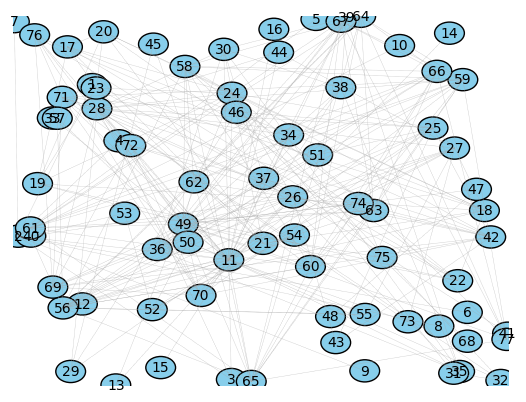

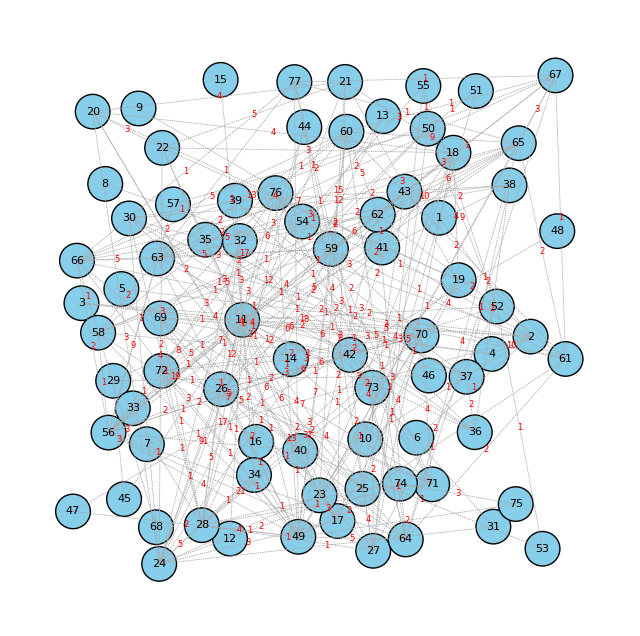

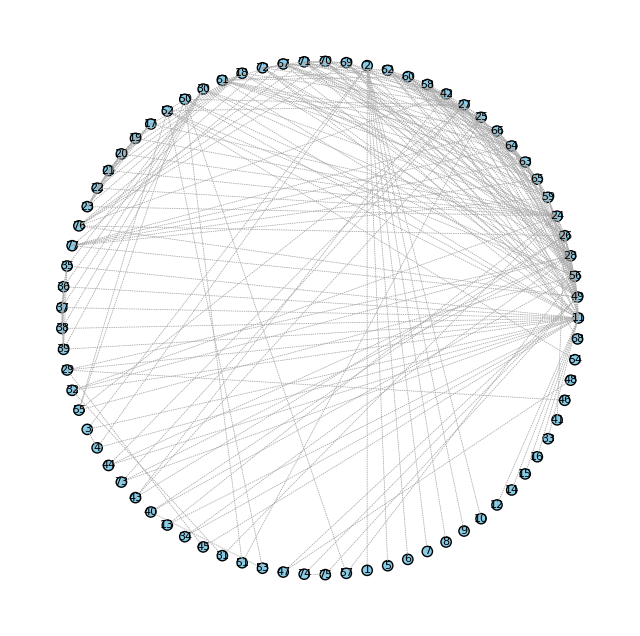

In [6]:
filename = data_name_1
step1(file_name)

## step 2

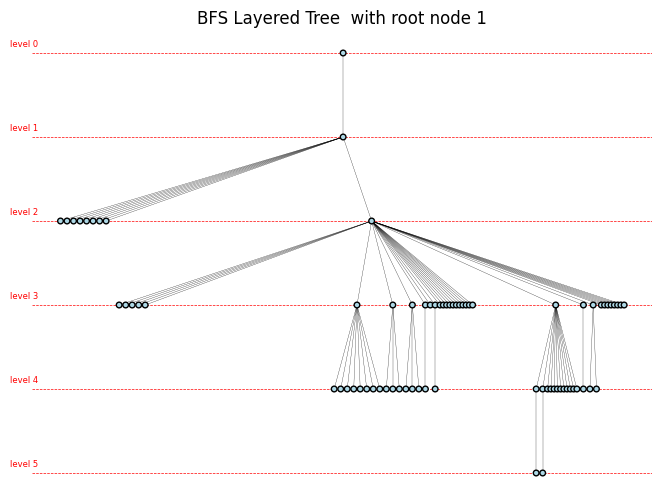

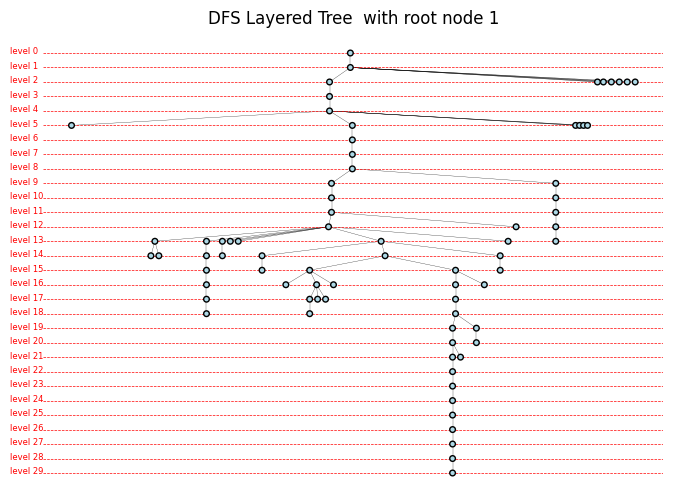

In [12]:
# choosing the graph and the root node
file_name = data_name_2
graph = parse_dot_file(file_name)
root_node = "1"

#running bfs and dfs on the graph
bfs_result = bfs_tree(graph, root_node)
dfs_result = dfs_tree(graph, root_node)

# plotting the trees with level-based layout with the nodes ids
display_node_id = False # by default, it displays the node ids with display_node_id = True
draw_layered_tree(bfs_result, "BFS Layered Tree  with root node 1", display_node_id)
draw_layered_tree(dfs_result, "DFS Layered Tree  with root node 1", display_node_id) 

## step 3

Saved frame 1 to ../Outputs_force\LesMiserables.dot\LesMiserables_FR_C0.75_iter_0001.png


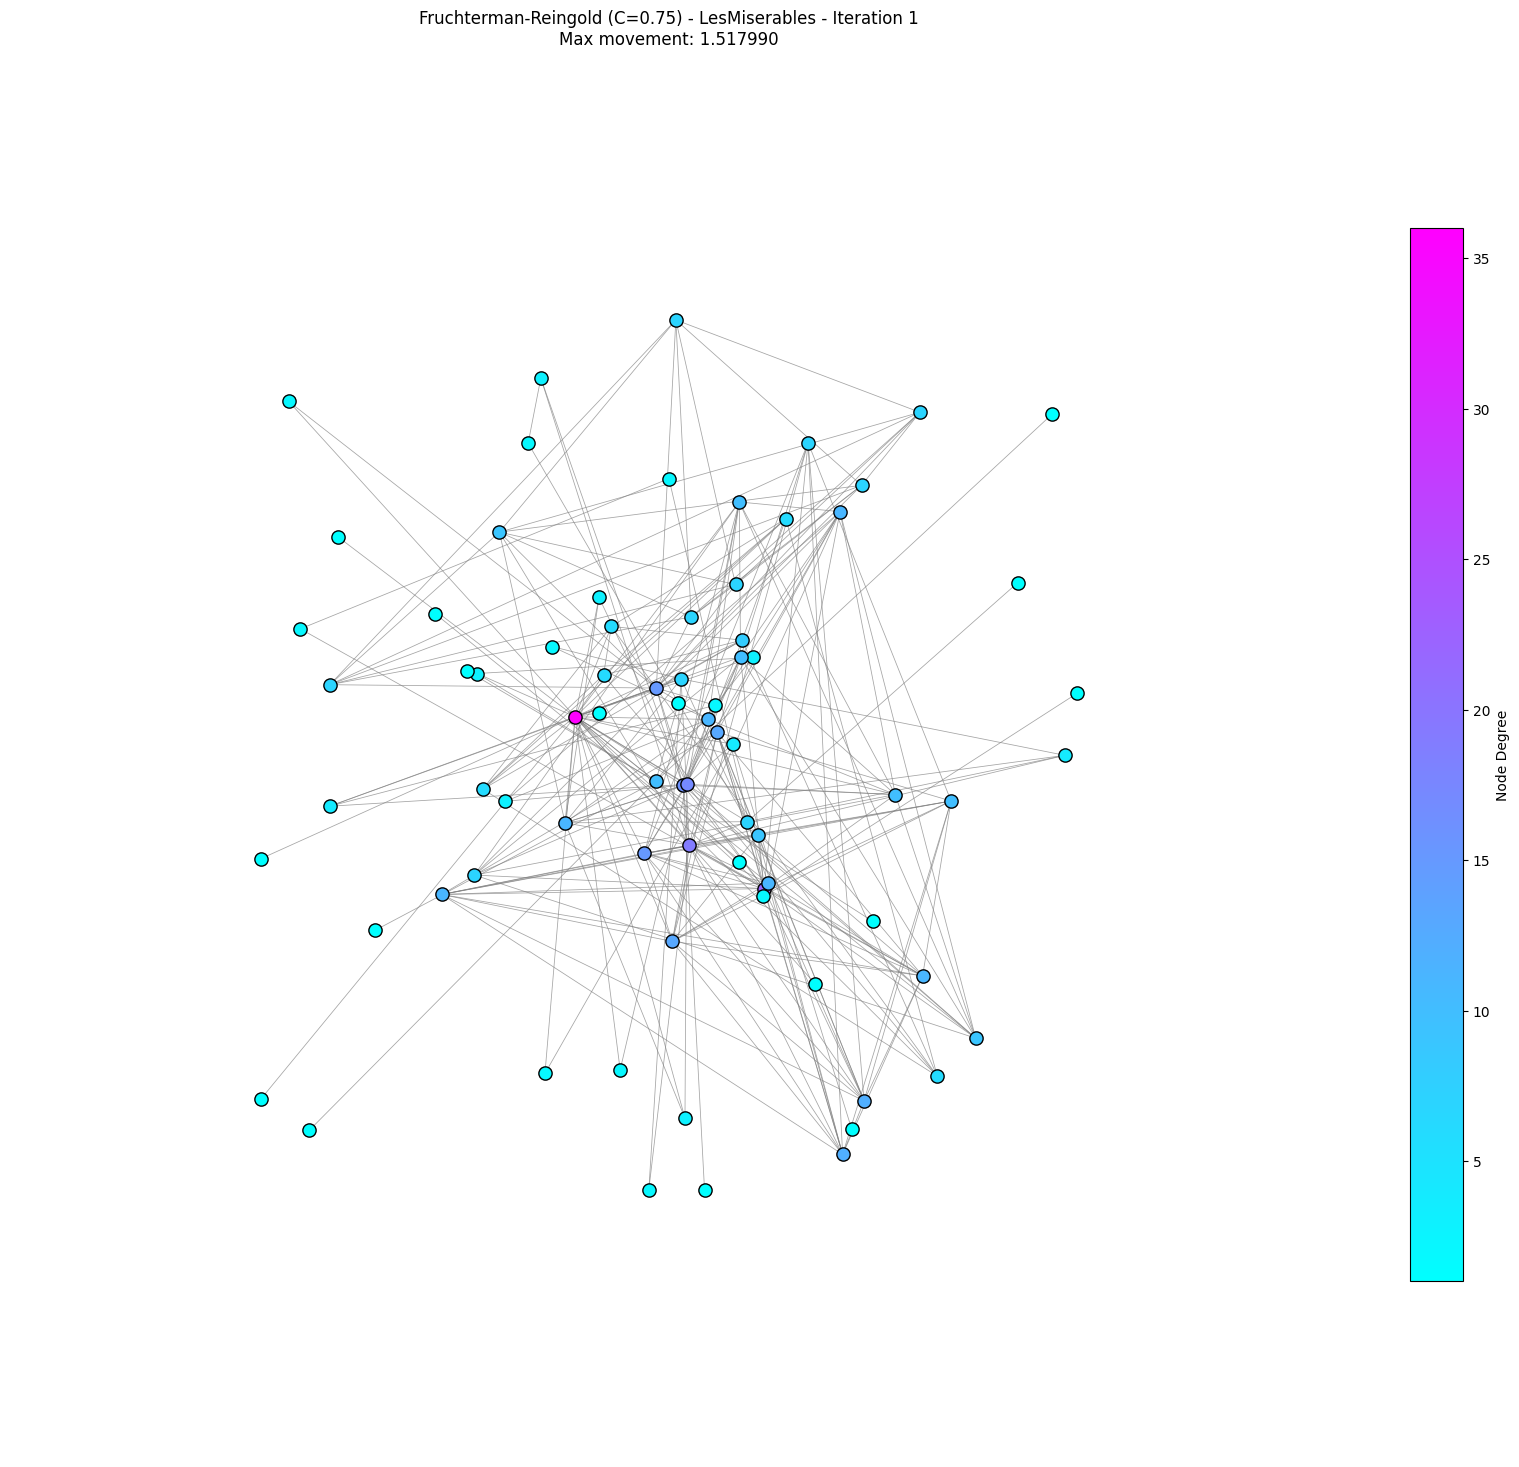

Saved frame 11 to ../Outputs_force\LesMiserables.dot\LesMiserables_FR_C0.75_iter_0011.png


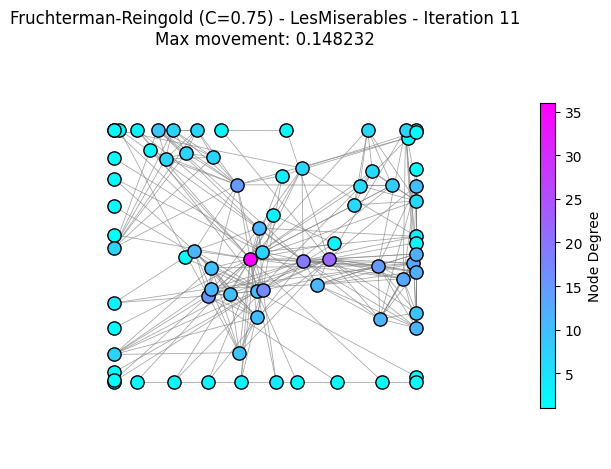

Saved frame 21 to ../Outputs_force\LesMiserables.dot\LesMiserables_FR_C0.75_iter_0021.png


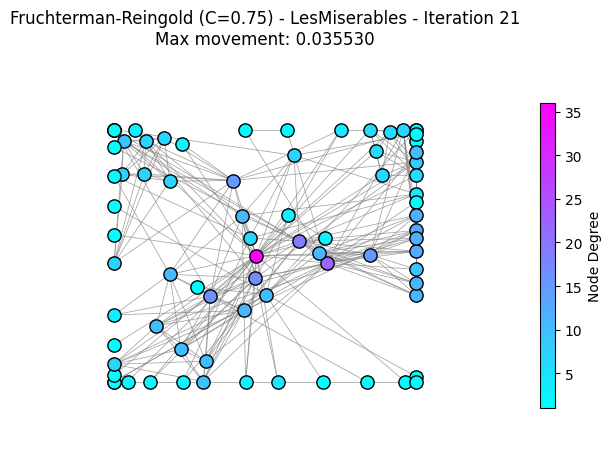

Saved frame 31 to ../Outputs_force\LesMiserables.dot\LesMiserables_FR_C0.75_iter_0031.png


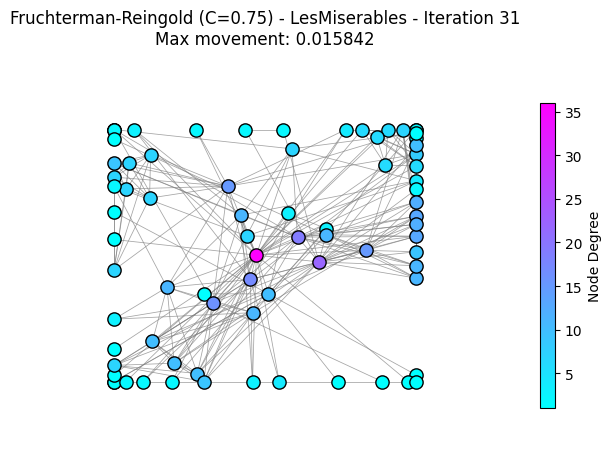

Saved frame 41 to ../Outputs_force\LesMiserables.dot\LesMiserables_FR_C0.75_iter_0041.png


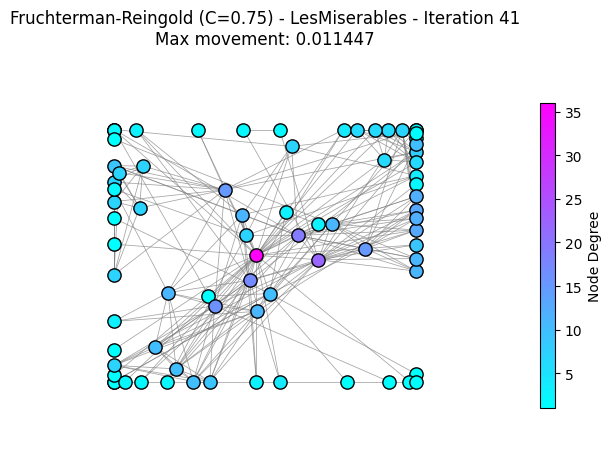

Saved frame 51 to ../Outputs_force\LesMiserables.dot\LesMiserables_FR_C0.75_iter_0051.png


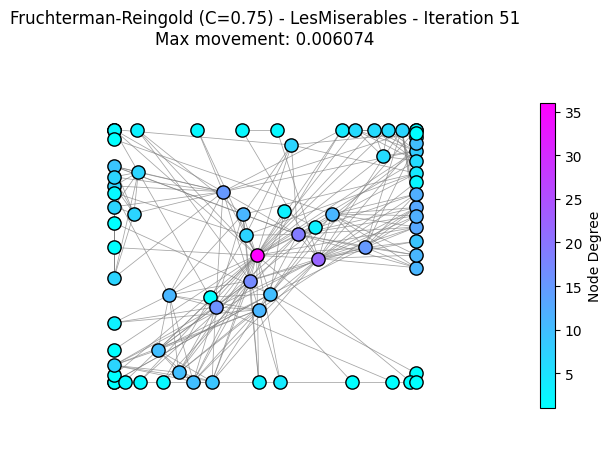

Saved frame 61 to ../Outputs_force\LesMiserables.dot\LesMiserables_FR_C0.75_iter_0061.png


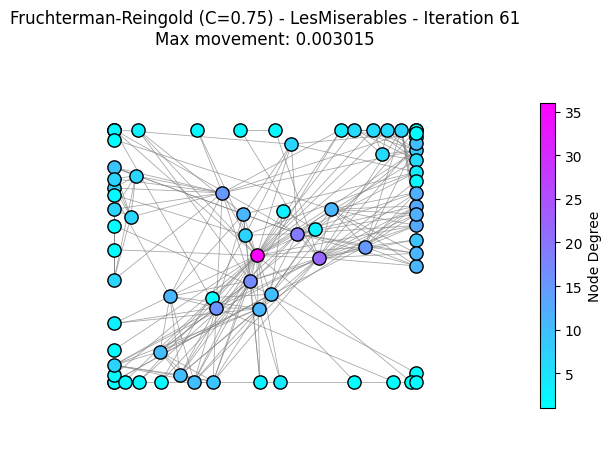

Saved frame 71 to ../Outputs_force\LesMiserables.dot\LesMiserables_FR_C0.75_iter_0071.png


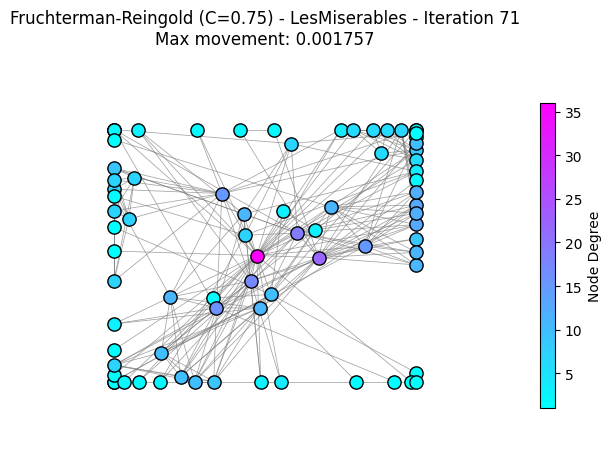

Saved frame 81 to ../Outputs_force\LesMiserables.dot\LesMiserables_FR_C0.75_iter_0081.png


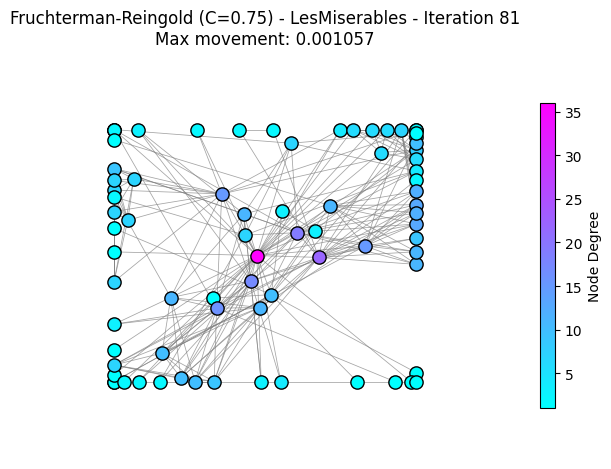

Saved frame 83 to ../Outputs_force\LesMiserables.dot\LesMiserables_FR_C0.75_iter_0083.png


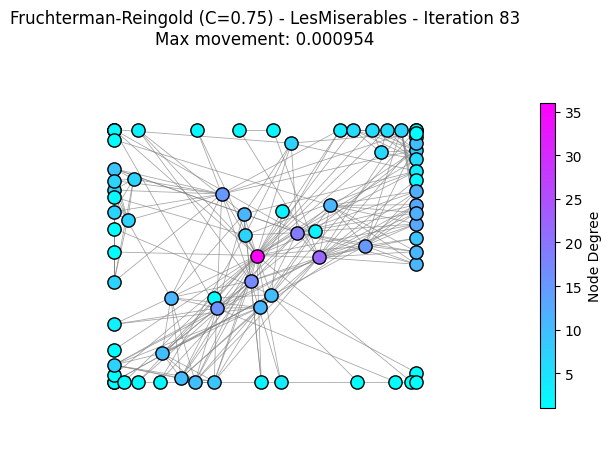

Algorithm converged at iteration 83 with maximum movement 0.000954


In [13]:
draw_colorful_force_directed_graph_fruchterman_reingold_inertia(
    file_name, 
    iterations=200,
    C=0.75,  
    convergence_threshold=0.001,
    display_node_id=False)

## step 4 

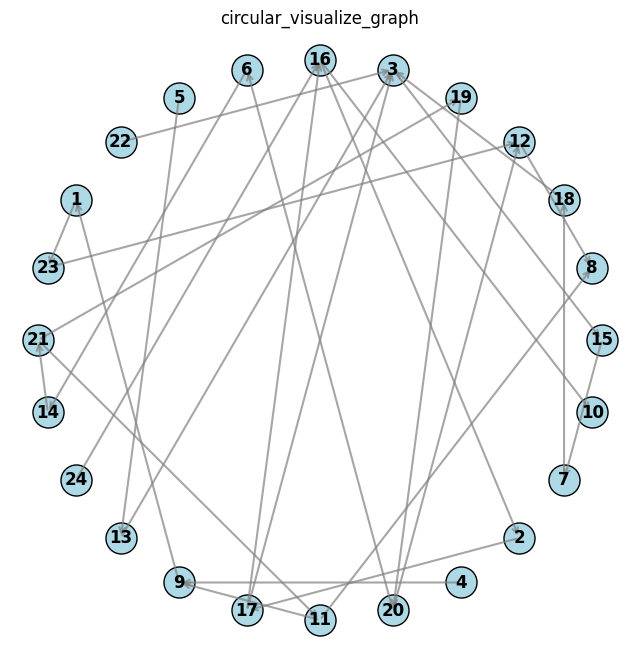

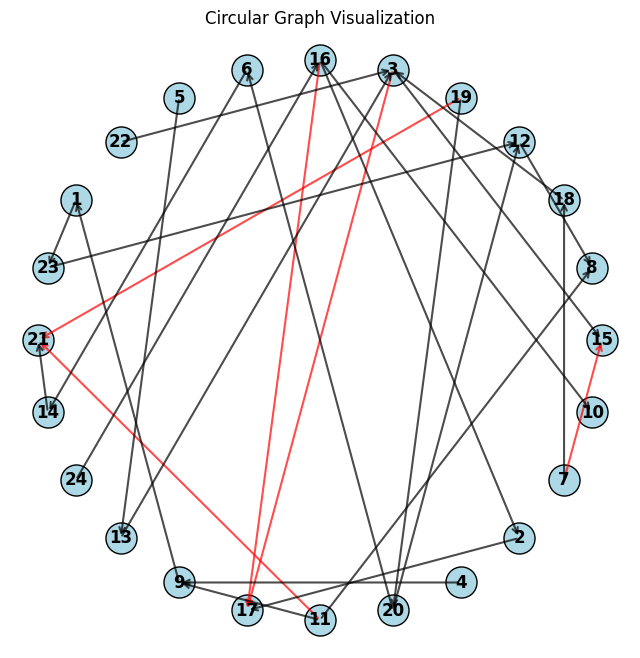

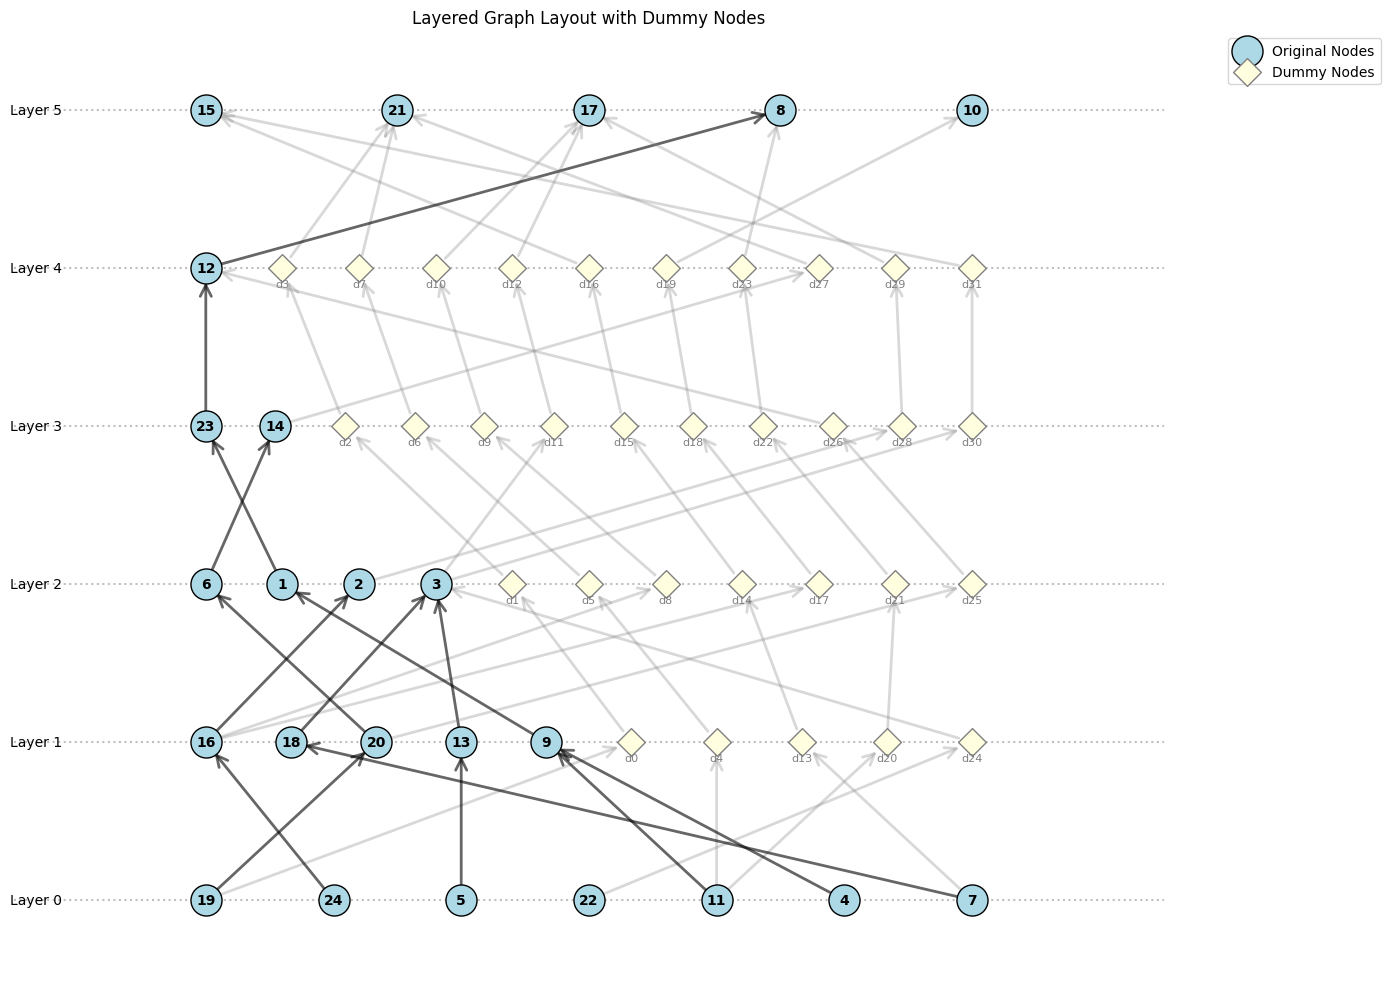

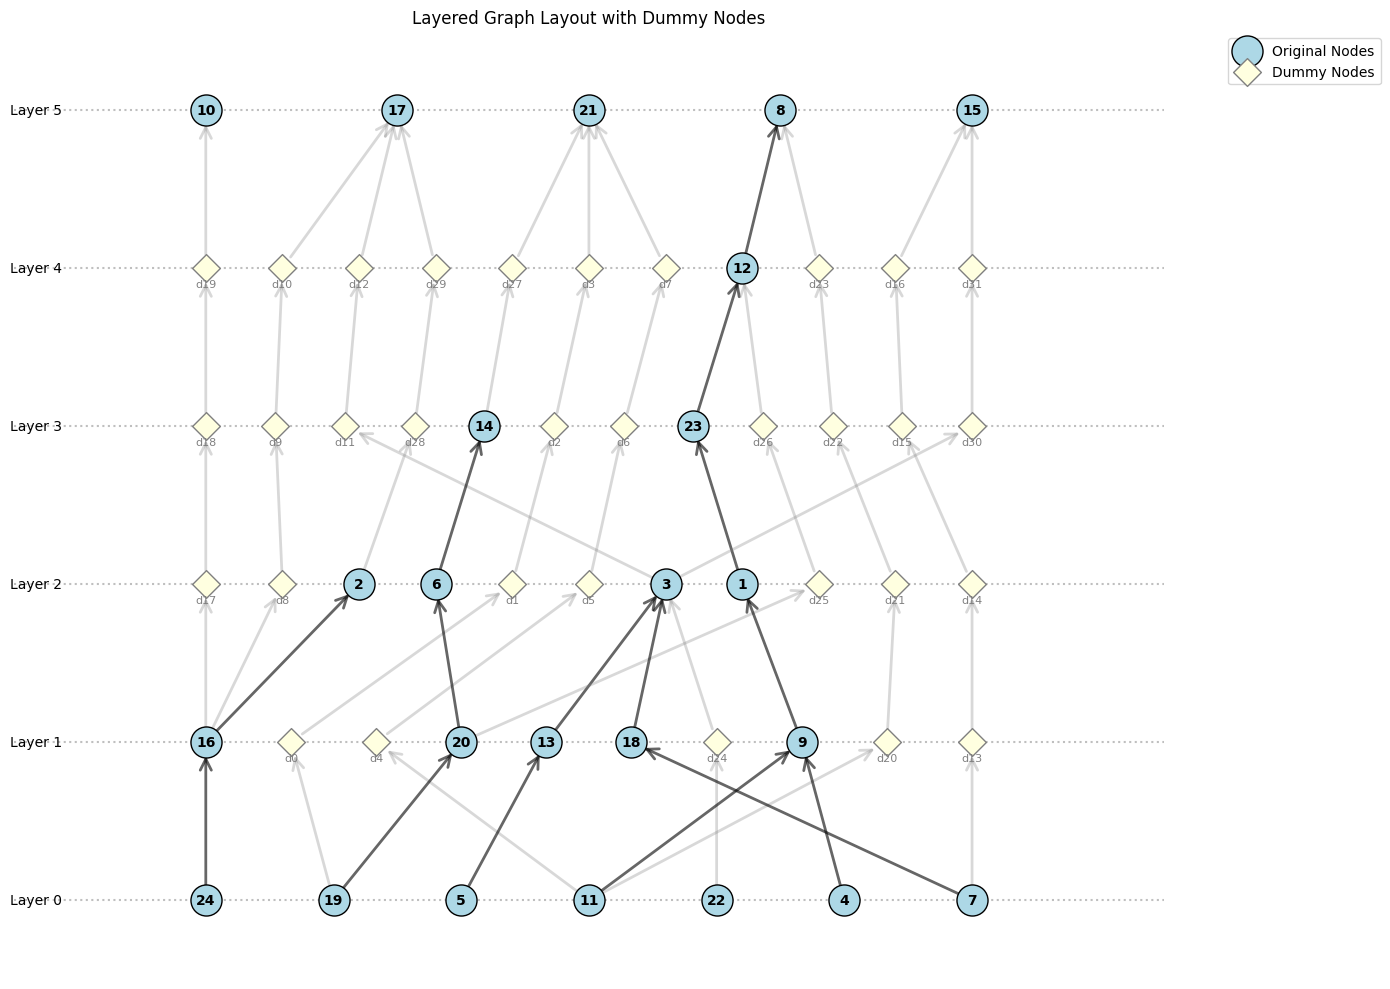

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.3285161177286017
            Iterations: 20
            Function evaluations: 1154
            Gradient evaluations: 20


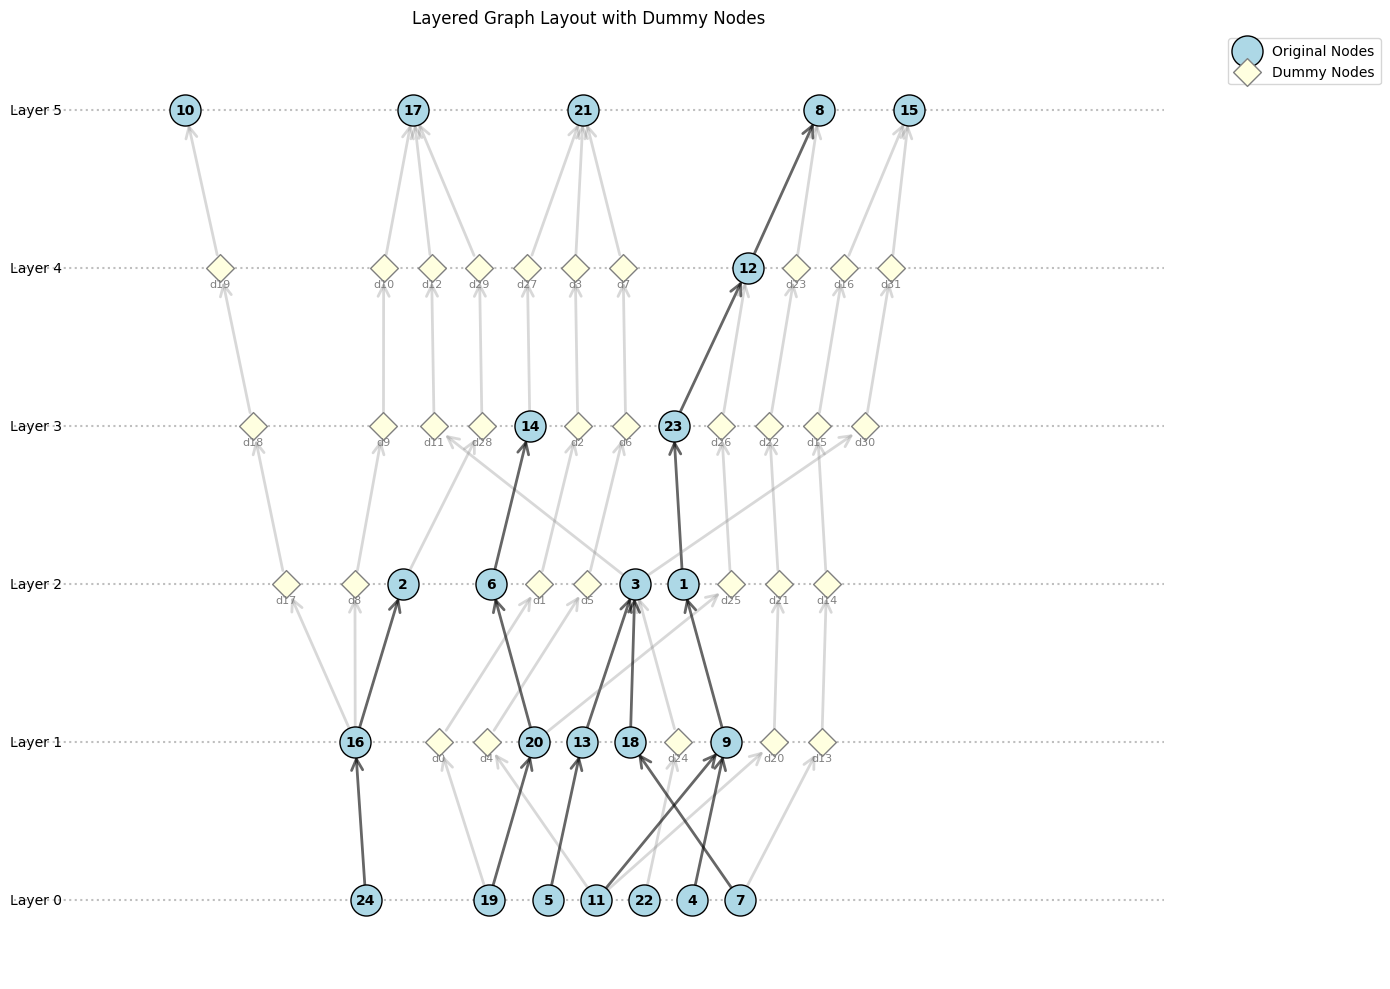

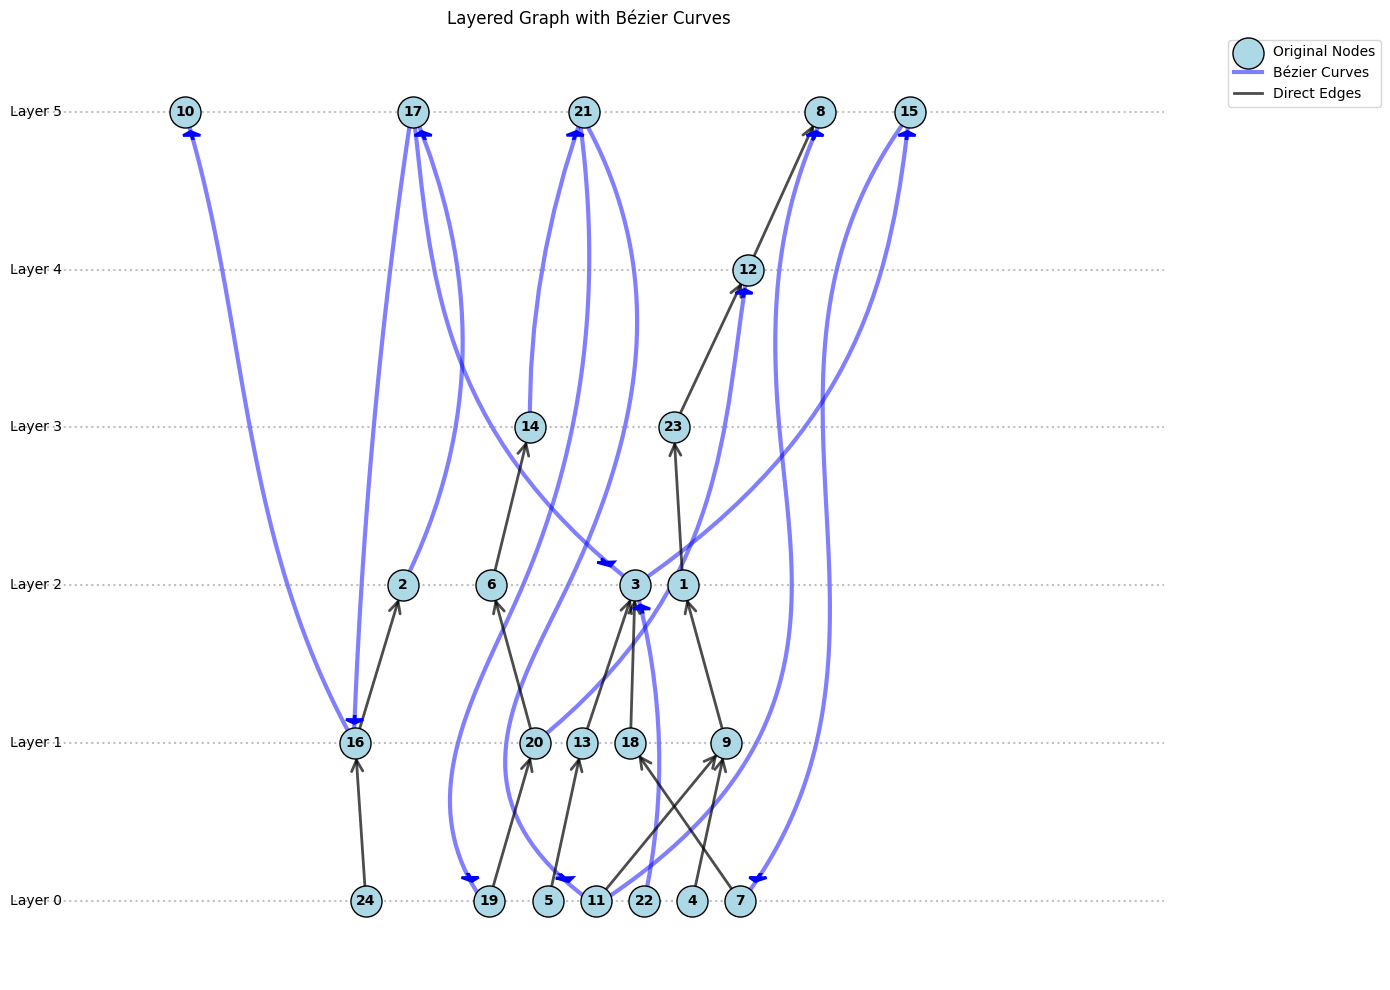

In [3]:
# Circular Layout
def parse_dot_file(file_path):
    """Parse DOT file and extract nodes and edges."""
    graph = pydot.graph_from_dot_file(file_path)[0]  
    nodes = set()
    edges = []

    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        nodes.add(src)
        nodes.add(dst)
        edges.append((src, dst))

    return list(nodes), edges

def nodes_edges(nodes, edges):
    print("Nodes: ", nodes)
    print("Edges: ", edges)

    n = set()
    e = []

    for ed in edges:
        # print(ed)
        




        src, dst = edge.get_source(), edge.get_destination()
        nodes.add(src)
        nodes.add(dst)
        edges.append((src, dst))

    return list(nodes), edges

def circular_visualize_graph(nodes, edges):
    """Plot the directed graph using Matplotlib."""
    V = len(nodes)
    
    # Assign positions to nodes (circular layout)
    theta = np.linspace(0, 2 * np.pi, V, endpoint=False)
    node_positions = {node: (np.cos(theta[i]), np.sin(theta[i])) for i, node in enumerate(nodes)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.title("circular_visualize_graph")
    plt.show()

#use a file
dot_file = data_name_9 
nodes, edges = parse_dot_file(dot_file)
circular_visualize_graph(nodes, edges)

# Resolve cycles with trivial heuristic

def find_loops(nodes, edges):
    """
    Find all distinct cycles in a directed graph using NetworkX.
    
    Args:
        nodes: List of nodes in the graph
        edges: List of edges as tuples (source, destination)
        
    Returns:
        list: All distinct cycles found in the graph
    """
    # Create a directed graph
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
    
    # Find all simple cycles
    cycles = list(nx.simple_cycles(G))
    
    return cycles

def reversed_edges(A, A_reverse):
    """Return the reversed edges that solve the loops"""
    A_reversed = [(dst, src) for src, dst in A_reverse]
    final_reversed = A_reversed + A
    
    return final_reversed

def circular_reverse_graph(nodes, edges, E_unchanged=None):
    """
    Plot the directed graph using Matplotlib.
    
    Parameters:
        nodes: List of nodes
        edges: List of all edges
        E_unchanged: List of edges that were not changed (to be drawn in black)
    """
    if E_unchanged is None:
        E_unchanged = []
    
    V = len(nodes)
    
    # Assign positions to nodes (circular layout)
    theta = np.linspace(0, 2 * np.pi, V, endpoint=False)
    node_positions = {node: (np.cos(theta[i]), np.sin(theta[i])) for i, node in enumerate(nodes)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        
        # Check if edge is in E_unchanged
        if (src, dst) in E_unchanged:
            edge_color = "black"  # Unchanged edges in black
        else:
            edge_color = "red"    # Changed edges in red
            
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color=edge_color, lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)


    plt.title("Circular Graph Visualization")
    plt.show()

def trivial_feedback_arc_set(nodes, edges):
    """
    Trivial heuristic to find a feedback arc set.
    
    Input:
        nodes: list of nodes
        edges: list of tuples (source_node, target_node)
    
    Output:
        A: list of edges to keep as they are
        A_reverse: list of edges to be reversed
    """
    # Create the graph as a dictionary {node: [adjacent_nodes]}
    graph = {node: [] for node in nodes}
    for source, target in edges:
        if source in graph:
            graph[source].append(target)
    
    # Create lists to store the edges
    A = []          # edges to keep
    A_reverse = []  # edges to reverse
    
    # Calculate indegree for each node
    in_degree = {node: 0 for node in graph}
    for node in graph:
        for neighbor in graph[node]:
            if neighbor in in_degree:  # Ensure the node exists in the dictionary
                in_degree[neighbor] = in_degree.get(neighbor, 0) + 1
    
    # Continue until there are no nodes left in the graph
    while graph:
        # Step 1: Find sink and source nodes
        sinks = [node for node in graph if not graph[node]]
        sources = [node for node in graph if in_degree[node] == 0]
        
        # Step 2: Remove sink nodes
        while sinks:
            sink = sinks.pop()
            # Add the incoming edges of the sink to A
            for node in list(graph.keys()):
                if sink in graph[node]:
                    A.append((node, sink))
                    graph[node].remove(sink)
                    in_degree[sink] -= 1
            # Remove the sink node from the graph
            del graph[sink]
        
        # Step 3: Remove isolated nodes
        isolated = [node for node in graph if not graph[node] and in_degree[node] == 0]
        for node in isolated:
            del graph[node]
        
        # Step 4: Remove source nodes
        while sources:
            source = sources.pop()
            # Add the outgoing edges of the source to A
            for neighbor in list(graph[source]):
                A.append((source, neighbor))
                graph[source].remove(neighbor)
                in_degree[neighbor] -= 1
                # Check if the neighbor has become a source
                if in_degree[neighbor] == 0 and neighbor in graph and neighbor not in sources:
                    sources.append(neighbor)
            # Remove the source node from the graph
            del graph[source]
        
        # Step 5: If there are still nodes, select the one with max(outdegree - indegree)
        if graph:
            # Calculate outdegree - indegree for each node
            diff_degree = {node: len(graph[node]) - in_degree[node] for node in graph}
            
            # Find the node with the maximum difference
            max_diff_node = max(diff_degree, key=diff_degree.get)
            
            # Add the node's edges to A_reverse
            for neighbor in list(graph[max_diff_node]):
                A_reverse.append((max_diff_node, neighbor))
                graph[max_diff_node].remove(neighbor)
                in_degree[neighbor] -= 1
            
            # Remove the node from the graph
            del graph[max_diff_node]
    
    return A, A_reverse

#Tesing with LeagueNetwork or noname

dot_file = data_name_9
nodes, edges = parse_dot_file(dot_file)

A, A_reverse = trivial_feedback_arc_set(nodes, edges)
final_edges = reversed_edges(A, A_reverse)
circular_reverse_graph(nodes, final_edges, A) # A Is the list of unchanged edges. The remaining edges have been reversed and coloured in red.
# check on the loops <- skipped because it takes too long
#print(f"list of looping nodes: {find_loops(nodes, final_edges)}")


# Layer Assignment

def find_sources(nodes, edges):
    """
    Find source nodes (nodes with no incoming edges).
    
    Input:
        nodes: list of nodes
        edges: list of tuples (source_node, target_node)
    
    Output:
        List of source nodes.
    """
    # Create a set of all nodes (from input nodes and those mentioned in edges)
    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    
    # Initialize incoming edge counts
    incoming_edges = {node: 0 for node in all_nodes}
    for src, dst in edges:
        incoming_edges[dst] += 1.
    return [node for node, count in incoming_edges.items() if count == 0]

def add_dummy_nodes(layers, edges):
    """
    Add dummy nodes for edges that span multiple layers.
    """
    # Create node to layer mapping
    node_to_layer = {}
    for i, layer in enumerate(layers):
        for node in layer:
            node_to_layer[node] = i
    
    modified_layers = [layer[:] for layer in layers]
    modified_edges = []
    dummy_mapping = {}  # Maps dummy nodes to original edges
    dummy_counter = 0
    
    for source, target in edges:
        source_layer = node_to_layer[source]
        target_layer = node_to_layer[target]
        
        if target_layer - source_layer > 1:
            # Edge spans multiple layers, need dummy nodes
            current = source
            for layer_idx in range(source_layer + 1, target_layer):
                dummy_name = f"dummy_{dummy_counter}"
                dummy_counter += 1
                
                # Add dummy node to layer
                modified_layers[layer_idx].append(dummy_name)
                
                # Add edge to dummy node
                modified_edges.append((current, dummy_name))
                dummy_mapping[dummy_name] = (source, target)
                current = dummy_name
            
            # Connect last dummy node to target
            modified_edges.append((current, target))
        else:
            modified_edges.append((source, target))
    
    return modified_layers, modified_edges, dummy_mapping

def find_sinks(nodes, edges):
    """
    Find sink nodes (nodes with no outgoing edges).
    
    Input:
        nodes: list of nodes
        edges: list of tuples (source_node, target_node)
    
    Output:
        List of sink nodes.
    """
    # Create a set of all nodes
    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    
    # Find nodes that appear as sources but not as destinations
    outgoing_edges = {node: 0 for node in all_nodes}
    for src, dst in edges:
        outgoing_edges[src] += 1
    return [node for node, count in outgoing_edges.items() if count == 0]

def sugiyama_layer_assignment(nodes, edges):
    """
    Enhanced Sugiyama layer assignment with dummy nodes and sink handling.
    """
    # Create a comprehensive set of all nodes
    all_nodes = set(nodes)
    for src, dst in edges:
        all_nodes.add(src)
        all_nodes.add(dst)
    
    # First, identify sink nodes
    sink_nodes = set(find_sinks(nodes, edges))
    
    # Remove sink nodes from consideration for initial layering
    working_nodes = all_nodes - sink_nodes
    working_edges = [(src, dst) for src, dst in edges if dst not in sink_nodes]
    
    layers = []  # Stores the final layers
    remaining_nodes = working_nodes.copy()
    remaining_edges = working_edges.copy()

    # Layer assignment for non-sink nodes
    while remaining_nodes:
        sources = find_sources(remaining_nodes, remaining_edges)
        
        if not sources:
            raise ValueError("Graph contains cycles or is disconnected.")
        
        layers.append(sources)
        remaining_nodes -= set(sources)
        remaining_edges = [(src, dst) for src, dst in remaining_edges if src not in sources]
    
    # Add sink nodes as the final layer
    if sink_nodes:
        layers.append(list(sink_nodes))
    
    # Add dummy nodes for long edges
    layers_with_dummies, modified_edges, dummy_mapping = add_dummy_nodes(layers, edges)
    
    return layers_with_dummies, modified_edges, dummy_mapping
def draw_layered_graph(layers, edges, dummy_mapping=None):
    """
    Draw the layered graph showing layer structure with dummy nodes.
    """
    plt.figure(figsize=(14, 10))
    node_positions = {}
    
    # Draw layers and nodes
    for layer_idx, layer_nodes in enumerate(layers):
        y_position = layer_idx
        
        # Layer line
        plt.axhline(y=y_position, color='gray', linestyle='dotted', alpha=0.5)
        
        # Calculate x-positions for nodes in this layer
        num_nodes = len(layer_nodes)
        x_positions = np.linspace(0.1, 0.9, num_nodes) if num_nodes > 1 else [0.5]
        
        # Place nodes
        for node_idx, node in enumerate(layer_nodes):
            x = x_positions[node_idx]
            y = y_position
            node_positions[node] = (x, y)
            
            is_dummy = str(node).startswith('dummy_')
            
            if is_dummy:
                # Dummy nodes as diamonds
                plt.scatter(x, y, s=200, color='lightyellow', 
                          edgecolor='gray', marker='D', zorder=3)
                plt.text(x, y-0.1, f'd{node[6:]}', ha='center', 
                        va='center', fontsize=8, color='gray')
            else:
                # Regular nodes as circles
                plt.scatter(x, y, s=500, color='lightblue', 
                          edgecolor='black', zorder=3)
                plt.text(x, y, node, ha='center', va='center', 
                        fontweight='bold', zorder=4)
    
    # Draw edges with arrows
    for source, target in edges:
        if source in node_positions and target in node_positions:
            x_source, y_source = node_positions[source]
            x_target, y_target = node_positions[target]
            
            is_dummy_edge = (str(source).startswith('dummy_') or 
                           str(target).startswith('dummy_'))
            
             # Draw arrow using annotate with larger arrows
            plt.annotate('', 
                xy=(x_target, y_target),  # arrow tip
                xytext=(x_source, y_source),  # arrow base
                arrowprops=dict(
                    arrowstyle='->',  # different arrow style for better visibility
                    color='gray' if is_dummy_edge else 'black',
                    alpha=0.3 if is_dummy_edge else 0.6,
                    connectionstyle='arc3,rad=0',  # straight lines
                    linewidth=2,  # increased line width
                    mutation_scale=20,  # increased arrow size
                    shrinkA=10,  # shrink start of arrow
                    shrinkB=10   # shrink end of arrow
                ),
                zorder=2
            )
    
    # Add layer numbers
    for i in range(len(layers)):
        plt.text(-0.05, i, f'Layer {i}', ha='right', va='center')
    
    # Legend
    plt.scatter([], [], s=500, color='lightblue', edgecolor='black', 
               label='Original Nodes')
    plt.scatter([], [], s=200, color='lightyellow', edgecolor='gray', 
               marker='D', label='Dummy Nodes')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.title('Layered Graph Layout with Dummy Nodes')
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.5, len(layers) - 0.5)
    plt.axis('off')
    plt.tight_layout()
    
    return node_positions


def count_edge_crossings(positions, edges):
    """
    Count the number of edge crossings in a layered graph and return the crossing edges.
    
    Parameters:
        positions: Dictionary mapping node IDs to (x, y) coordinates
        edges: List of tuples (source_node, target_node) representing edges
    
    Returns:
        tuple: (number of crossings, list of crossing edge pairs)
    """
    def line_segments_intersect(p1, p2, p3, p4):
        """
        Check if line segments (p1, p2) and (p3, p4) intersect.
        Each point is a tuple (x, y).
        """
        def orientation(p, q, r):
            # Calculate orientation of triplet (p, q, r)
            val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
            if val == 0: return 0   # Collinear
            return 1 if val > 0 else 2  # Clockwise or Counterclockwise
        
        def on_segment(p, q, r):
            # Check if point q lies on line segment pr
            return (q[0] <= max(p[0], r[0]) and q[0] >= min(p[0], r[0]) and
                    q[1] <= max(p[1], r[1]) and q[1] >= min(p[1], r[1]))
        
        # Find orientations
        o1 = orientation(p1, p2, p3)
        o2 = orientation(p1, p2, p4)
        o3 = orientation(p3, p4, p1)
        o4 = orientation(p3, p4, p2)
        
        # General case: different orientations
        if o1 != o2 and o3 != o4:
            return True
        
        # Special cases: collinearity
        if o1 == 0 and on_segment(p1, p3, p2): return True
        if o2 == 0 and on_segment(p1, p4, p2): return True
        if o3 == 0 and on_segment(p3, p1, p4): return True
        if o4 == 0 and on_segment(p3, p2, p4): return True
        
        return False  # No intersection
    
    crossings = 0
    crossing_edges = []
    
    # Check each pair of edges
    for i in range(len(edges)):
        src1, dst1 = edges[i]
        # Skip if we don't have position data for these nodes
        if src1 not in positions or dst1 not in positions:
            continue
            
        p1 = positions[src1]
        p2 = positions[dst1]
        
        for j in range(i+1, len(edges)):
            src2, dst2 = edges[j]
            # Skip if we don't have position data for these nodes
            if src2 not in positions or dst2 not in positions:
                continue
                
            p3 = positions[src2]
            p4 = positions[dst2]
            
            # Check if these edges share an endpoint
            if src1 == src2 or src1 == dst2 or dst1 == src2 or dst1 == dst2:
                continue  # Edges sharing endpoints don't count as crossings
            
            # Check if these line segments intersect
            if line_segments_intersect(p1, p2, p3, p4):
                crossings += 1
                crossing_edges.append(((src1, dst1), (src2, dst2)))
    
    return crossings, crossing_edges

#usage
dot_file = data_name_9
nodes, edges = parse_dot_file(dot_file)

A, A_reverse = trivial_feedback_arc_set(nodes, edges)
final_edges = reversed_edges(A, A_reverse)

layers, modified_edges, dummy_mapping  = sugiyama_layer_assignment(nodes, final_edges)
positions = draw_layered_graph(layers, modified_edges, dummy_mapping)

# Cross minimization
def get_node_order(layer):
    """Helper function to get the current order of nodes in a layer"""
    return {node: idx for idx, node in enumerate(layer)}

def get_median_position(node, connected_nodes, node_order):
    """Calculate median position for a node based on its connected nodes"""
    if not connected_nodes:
        return float('inf')
    positions = sorted([node_order[n] for n in connected_nodes])
    n = len(positions)
    if n % 2 == 1:
        return positions[n // 2]
    return (positions[(n-1) // 2] + positions[n // 2]) / 2

def get_barycenter_position(node, connected_nodes, node_order):
    """Calculate barycenter position for a node based on its connected nodes"""
    if not connected_nodes:
        return float('inf')
    return sum(node_order[n] for n in connected_nodes) / len(connected_nodes)

def count_crossings(layer1, layer2, edges):
    """Count number of edge crossings between two adjacent layers"""
    crossings = 0
    layer1_order = {node: idx for idx, node in enumerate(layer1)}
    layer2_order = {node: idx for idx, node in enumerate(layer2)}
    
    edges_between = [(s, t) for s, t in edges if s in layer1_order and t in layer2_order]
    for i, (s1, t1) in enumerate(edges_between):
        for s2, t2 in edges_between[i+1:]:
            if (layer1_order[s1] - layer1_order[s2]) * (layer2_order[t1] - layer2_order[t2]) < 0:
                crossings += 1
    return crossings

def count_all_crossings(layers, edges):
    """Count total crossings between all adjacent layers"""
    total = 0
    for i in range(len(layers) - 1):
        total += count_crossings(layers[i], layers[i+1], edges)
    return total

def minimize_crossings(layers, edges, max_iterations=10, method='barycenter'):
    """
    Minimize edge crossings using either barycenter or median heuristic
    Args:
        layers: List of layers, each containing nodes
        edges: List of (source, target) edge tuples
        max_iterations: Maximum number of sweep iterations
        method: 'barycenter' or 'median'
    """
    previous_down_crossings = float('inf')  # Add this line
    previous_up_crossings = float('inf')    # Add this line
    # Create adjacency lists for quick lookup
    successors = {node: [] for layer in layers for node in layer}
    predecessors = {node: [] for layer in layers for node in layer}
    
    for source, target in edges:
        successors[source].append(target)
        predecessors[target].append(source)
    
    position_func = get_barycenter_position if method == 'barycenter' else get_median_position
    
    initial_crossings = count_all_crossings(layers, edges)
    #print(f"\nInitial crossing count: {initial_crossings}")
    #print("-" * 40)
    
    for iteration in range(max_iterations):
        improved = False
        #print(f"\nIteration {iteration + 1}")
        
        # Sweep down
        for i in range(1, len(layers)):
            fixed_order = get_node_order(layers[i-1])
            current_layer = layers[i]
            
            positions = []
            for node in current_layer:
                pos = position_func(node, predecessors[node], fixed_order)
                positions.append((pos, node))
            
            positions.sort()
            new_order = [node for _, node in positions]
            
            if new_order != current_layer:
                layers[i] = new_order
                improved = True
        
        down_crossings = count_all_crossings(layers, edges)
        #print(f"After downward sweep: {down_crossings} crossings")
        
        # Sweep up
        for i in range(len(layers)-2, -1, -1):
            fixed_order = get_node_order(layers[i+1])
            current_layer = layers[i]
            
            positions = []
            for node in current_layer:
                pos = position_func(node, successors[node], fixed_order)
                positions.append((pos, node))
            
            positions.sort()
            new_order = [node for _, node in positions]
            
            if new_order != current_layer:
                layers[i] = new_order
                improved = True
        
        up_crossings = count_all_crossings(layers, edges)
        #print(f"After upward sweep: {up_crossings} crossings")
        
        # Check if pattern repeats (both down and up crossings are same as previous iteration)
        if down_crossings == previous_down_crossings and up_crossings == previous_up_crossings:
            #print("\nPattern repeats (same crossing counts as previous iteration), stopping...")
            break
            
        previous_down_crossings = down_crossings
        previous_up_crossings = up_crossings
        
        if not improved:
            print("\nNo node order changes, stopping...")
            break
    
    final_crossings = count_all_crossings(layers, edges)
    #print(f"\nFinal crossing count: {final_crossings}")
    #print(f"Total reduction: {initial_crossings - final_crossings} crossings")
    
    return layers

def stats_minimize_crossings(layers, edges, max_iterations=10, method='barycenter'):
    """
    Minimize edge crossings using either barycenter or median heuristic
    Args:
        layers: List of layers, each containing nodes
        edges: List of (source, target) edge tuples
        max_iterations: Maximum number of sweep iterations
        method: 'barycenter' or 'median'
    
    Returns:
        tuple: (optimized_layers, crossing_stats)
            - optimized_layers: Layers with minimized crossings
            - crossing_stats: List of dictionaries with crossing counts for each iteration
    """
    previous_down_crossings = float('inf')
    previous_up_crossings = float('inf')
    
    # Create adjacency lists for quick lookup
    successors = {node: [] for layer in layers for node in layer}
    predecessors = {node: [] for layer in layers for node in layer}
    
    for source, target in edges:
        successors[source].append(target)
        predecessors[target].append(source)
    
    position_func = get_barycenter_position if method == 'barycenter' else get_median_position
    
    initial_crossings = count_all_crossings(layers, edges)
    #print(f"\nInitial crossing count: {initial_crossings}")
    #print("-" * 40)
    
    # List to store crossing statistics for each iteration
    crossing_stats = []
    
    for iteration in range(max_iterations):
        improved = False
        print(f"\nIteration {iteration + 1}")
        
        iteration_stats = {
            "iteration": iteration + 1,
            "initial": initial_crossings if iteration == 0 else previous_up_crossings
        }
        
        # Sweep down
        for i in range(1, len(layers)):
            fixed_order = get_node_order(layers[i-1])
            current_layer = layers[i]
            
            positions = []
            for node in current_layer:
                pos = position_func(node, predecessors[node], fixed_order)
                positions.append((pos, node))
            
            positions.sort()
            new_order = [node for _, node in positions]
            
            if new_order != current_layer:
                layers[i] = new_order
                improved = True
        
        down_crossings = count_all_crossings(layers, edges)
        #print(f"After downward sweep: {down_crossings} crossings")
        iteration_stats["down_sweep"] = down_crossings
        
        # Sweep up
        for i in range(len(layers)-2, -1, -1):
            fixed_order = get_node_order(layers[i+1])
            current_layer = layers[i]
            
            positions = []
            for node in current_layer:
                pos = position_func(node, successors[node], fixed_order)
                positions.append((pos, node))
            
            positions.sort()
            new_order = [node for _, node in positions]
            
            if new_order != current_layer:
                layers[i] = new_order
                improved = True
        
        up_crossings = count_all_crossings(layers, edges)
        #print(f"After upward sweep: {up_crossings} crossings")
        iteration_stats["up_sweep"] = up_crossings
        
        # Calculate crossings reduced in this iteration
        crossings_reduced = iteration_stats["initial"] - up_crossings
        iteration_stats["crossings_reduced"] = crossings_reduced
        
        # Add stats to the list
        crossing_stats.append(iteration_stats)
        
        # Check if pattern repeats
        if down_crossings == previous_down_crossings and up_crossings == previous_up_crossings:
            #print("\nPattern repeats (same crossing counts as previous iteration), stopping...")
            break
            
        previous_down_crossings = down_crossings
        previous_up_crossings = up_crossings
        
        if not improved:
            #print("\nNo node order changes, stopping...")
            break
    
    final_crossings = count_all_crossings(layers, edges)
    #print(f"\nFinal crossing count: {final_crossings}")
    #print(f"Total reduction: {initial_crossings - final_crossings} crossings")
    
    # Add total summary to the stats
    crossing_stats.append({
        "iteration": "final",
        "initial": initial_crossings,
        "final": final_crossings,
        "total_reduction": initial_crossings - final_crossings
    })
    
    return crossing_stats

#usage
#apply the crossing minimization to the LeagueNetwork or noname network

layers, modified_edges, dummy_mapping = sugiyama_layer_assignment(nodes, final_edges)

# Apply crossing minimization
optimized_layers = minimize_crossings(
    layers=layers.copy(),  # Create a copy to preserve original
    edges=modified_edges,
    max_iterations=10,
    method='barycenter'  # or 'median'
)

# Visualize the result
positions = draw_layered_graph(optimized_layers, modified_edges, dummy_mapping)
plt.show()


#node postioning

def build_paths_from_layer_0(positions, modified_edges, dummy_mapping, max_depth=None):
    """
    For each node in layer 0, find ALL possible paths (u, d1, ..., dk, v) where:
    - u is a node in layer 0
    - d1, ..., dk are nodes (dummy or regular) along the path
    - v is any reachable node with no outgoing edges
    
    Parameters:
        positions: Dictionary mapping node IDs to (x, y) coordinates
        modified_edges: List of edges including dummy nodes
        dummy_mapping: Dictionary mapping dummy nodes to (source, target) tuples
        max_depth: Maximum path length (None for unlimited)
    
    Returns:
        List of paths, where each path is a dictionary with path information
    """
    import collections
    
    # Identify nodes in layer 0
    layer_0_nodes = [node for node, (_, y) in positions.items() if int(y) == 0]
    #print(f"Found {len(layer_0_nodes)} nodes in layer 0")
    
    # Build adjacency list from modified edges
    graph = collections.defaultdict(list)
    for src, dst in modified_edges:
        graph[src].append(dst)
    
    # Identify dummy nodes
    dummy_nodes = set(dummy_mapping.keys())
    
    # Get the layer for each node (will be used to ensure we only go forward)
    node_layers = {node: int(y) for node, (_, y) in positions.items()}
    
    # Track all found paths
    all_paths = []
    
    # DFS to find all paths from a source node
    def find_all_paths(source, current_path=None, visited=None):
        if current_path is None:
            current_path = [source]
        if visited is None:
            visited = set([source])
        
        # Check if we've reached maximum depth
        if max_depth is not None and len(current_path) >= max_depth:
            # Add the path if it has at least one edge
            if len(current_path) > 1:
                all_paths.append({
                    "source": current_path[0],
                    "target": current_path[-1],
                    "path": current_path.copy(),
                    "dummy_nodes": [n for n in current_path if n in dummy_nodes],
                    "length": len(current_path)
                })
            return
        
        # Check if this is a sink node (no outgoing edges)
        if not graph[current_path[-1]]:
            # We've reached the end of a path
            if len(current_path) > 1:  # Only add paths with at least one edge
                all_paths.append({
                    "source": current_path[0],
                    "target": current_path[-1],
                    "path": current_path.copy(),
                    "dummy_nodes": [n for n in current_path if n in dummy_nodes],
                    "length": len(current_path)
                })
            return
        
        # Current node and its layer
        current_node = current_path[-1]
        current_layer = node_layers[current_node]
        
        # Explore all neighbors
        for neighbor in graph[current_node]:
            # Skip if already visited (avoid cycles)
            if neighbor in visited:
                continue
            
            # Only go forward in layers to maintain DAG property
            if node_layers.get(neighbor, float('inf')) <= current_layer:
                continue
            
            # Add neighbor to path
            current_path.append(neighbor)
            visited.add(neighbor)
            
            # Recursively find all paths from neighbor
            find_all_paths(source, current_path, visited)
            
            # Backtrack
            current_path.pop()
            visited.remove(neighbor)
    
    # Process each layer 0 node
    for i, node in enumerate(layer_0_nodes):
        #print(f"Finding paths from node {node} ({i+1}/{len(layer_0_nodes)})")
        find_all_paths(node)
    
    # Sort paths by length (longest first)
    all_paths.sort(key=lambda x: x["length"], reverse=True)
    
    #print(f"Found {len(all_paths)} total paths from layer 0 nodes")
    return all_paths



# Build ALL paths from layer 0 nodes
paths = build_paths_from_layer_0(positions, modified_edges, dummy_mapping, max_depth=10)

def compute_ideal_path_positions_by_formula(paths, positions):
    """
    For each path, compute the ideal x-coordinate for each node that would
    make the path perfectly straight using the formula:
    X(i)_ideal = X(u) + (i/len(path)) * (X(v) - X(u))
    
    Parameters:
        paths: List of paths from build_paths_from_layer_0 function
        positions: Dictionary mapping node IDs to (x, y) coordinates
    
    Returns:
        Dictionary with path analysis and ideal positions for each node
    """
    import numpy as np
    
    #print("Computing ideal positions for all nodes in paths using the specified formula...")
    
    # Dictionary to store results for each path
    path_results = {}
    
    # Process each path
    for path_idx, path_info in enumerate(paths):
        path = path_info['path']
        path_length = len(path)
        
        # Skip paths that are too short
        if path_length <= 2:
            continue
            
        # Get source and target nodes
        source_node = path[0]
        target_node = path[-1]
        
        # Get their x-coordinates
        source_x = positions[source_node][0]
        target_x = positions[target_node][0]
        
        # Calculate the x-span
        x_span = target_x - source_x
        
        # Store analysis for each node in this path
        node_positions = []
        total_deviation = 0
        
        for i, node in enumerate(path):
            # Calculate ideal position using the formula:
            # X(i)_ideal = X(u) + (i/len(path)) * (X(v) - X(u))
            t = i / path_length
            ideal_x = source_x + t * x_span
            
            # Calculate deviation from current position
            current_x = positions[node][0]
            deviation = (current_x - ideal_x) ** 2
            total_deviation += deviation
            
            # Store analysis for this node
            node_positions.append({
                'node': node,
                'position': i,
                'current_x': current_x,
                'ideal_x': ideal_x,
                'deviation': deviation
            })
        
        # Store results for this path
        path_results[path_idx] = {
            'source': source_node,
            'target': target_node,
            'path_length': path_length,
            'x_span': x_span,
            'node_positions': node_positions,
            'total_deviation': total_deviation,
            'average_deviation': total_deviation / path_length
        }
    
    # Calculate overall statistics
    all_deviations = [
        node_info['deviation'] 
        for path_info in path_results.values() 
        for node_info in path_info['node_positions']
    ]
    
    overall_stats = {
        'total_paths': len(path_results),
        'total_nodes_analyzed': len(all_deviations),
        'total_deviation': sum(all_deviations),
        'average_deviation': np.mean(all_deviations) if all_deviations else 0,
        'max_deviation': max(all_deviations) if all_deviations else 0
    }
    
    #print(f"Analyzed {overall_stats['total_paths']} paths with {overall_stats['total_nodes_analyzed']} nodes")
    #print(f"Total squared deviation: {overall_stats['total_deviation']:.4f}")
    
    return {
        'paths': path_results,
        'stats': overall_stats
    }

def calculate_path_deviations(paths, positions):
    """
    For each path, calculate the total deviation of all nodes from their ideal positions
    that would make the path perfectly straight.
    
    Parameters:
        paths: List of paths from build_paths_from_layer_0 function
        positions: Dictionary mapping node IDs to (x, y) coordinates
    
    Returns:
        Dictionary with path deviations and details
    """
    import numpy as np
    
    #print("Calculating total deviation from straight lines for each path...")
    
    # Dictionary to store results
    path_deviations = {}
    
    # Process each path
    for path_idx, path_info in enumerate(paths):
        path = path_info['path']
        path_length = len(path)
        
        # Skip paths that are too short
        if path_length <= 2:
            continue
            
        # Get source and target nodes
        source_node = path[0]
        target_node = path[-1]
        
        # Get their x-coordinates
        source_x = positions[source_node][0]
        target_x = positions[target_node][0]
        
        # Calculate total deviation for this path (excluding source node)
        total_deviation = 0
        node_deviations = []
        
        # Skip the first node (source) as specified, start from i=1
        for i, node in enumerate(path[1:], 1):
            # Calculate ideal position using the formula:
            # X(i)_ideal = X(u) + (i/len(path)) * (X(v) - X(u))
            t = i / (path_length - 1)  # Normalized position (0 to 1)
            ideal_x = source_x + t * (target_x - source_x)
            
            # Calculate squared deviation from current position
            current_x = positions[node][0]
            deviation = (current_x - ideal_x) ** 2
            total_deviation += deviation
            
            # Store details for this node
            node_deviations.append({
                'node': node,
                'position': i,
                'current_x': current_x,
                'ideal_x': ideal_x,
                'deviation': deviation
            })
        
        # Store results for this path
        path_deviations[path_idx] = {
            'source': source_node,
            'target': target_node,
            'path': path,
            'path_length': path_length,
            'total_deviation': total_deviation,
            'node_deviations': node_deviations,
            'max_node_deviation': max([n['deviation'] for n in node_deviations]) if node_deviations else 0
        }
    
    # Calculate overall statistics
    sorted_paths = sorted(
        path_deviations.items(), 
        key=lambda x: x[1]['total_deviation'], 
        reverse=True
    )
    
    """print(f"Analyzed {len(path_deviations)} paths")
    print(f"Path with highest deviation: {sorted_paths[0][1]['source']} → {sorted_paths[0][1]['target']} "
          f"(deviation: {sorted_paths[0][1]['total_deviation']:.4f})")"""
    
    return {
        'path_deviations': path_deviations,
        'sorted_paths': sorted_paths
    }

def straighten_paths_quadratic_program(paths, positions, dummy_mapping, min_distance=0.05, max_iterations=500):
    """
    Use quadratic programming to minimize the total deviation of paths from straight lines,
    with integrated deviation calculations during the optimization process.
    
    Parameters:
        paths: List of paths from build_paths_from_layer_0 function
        positions: Dictionary mapping node IDs to (x, y) coordinates
        dummy_mapping: Dictionary mapping dummy nodes to (source, target) tuples
        min_distance: Minimum horizontal distance between consecutive nodes on same layer
        max_iterations: Maximum number of iterations for the optimizer
    
    Returns:
        Dictionary with new optimized positions
    """
    
    #print("Optimizing node positions to straighten paths...")
    
    # Group nodes by layer
    layers = defaultdict(list)
    for node, (x, y) in positions.items():
        layer = int(y)
        layers[layer].append(node)
    
    # Sort nodes within each layer by x-coordinate
    for layer in layers:
        layers[layer].sort(key=lambda node: positions[node][0])
    
    # Create a mapping from node names to indices in the optimization vector
    nodes_list = sorted(positions.keys(), key=lambda node: (positions[node][1], positions[node][0]))
    node_indices = {node: i for i, node in enumerate(nodes_list)}
    
    #print(f"Preparing optimization for {len(nodes_list)} nodes across {len(layers)} layers")
    
    # Define a function to calculate current positions from x-values vector
    def get_positions_from_x_values(x_values):
        current_positions = {}
        for node, idx in node_indices.items():
            _, y = positions[node]  # Keep original y-coordinate
            current_positions[node] = (x_values[idx], y)
        return current_positions
    
    # Define a function to calculate path deviations based on positions
    def calculate_deviations(current_positions):
        path_deviations = OrderedDict()
        
        for path_idx, path_info in enumerate(paths):
            path = path_info['path']
            if len(path) <= 2:
                continue
                
            source_node = path[0]
            target_node = path[-1]
            source_x = current_positions[source_node][0]
            target_x = current_positions[target_node][0]
            
            total_deviation = 0
            node_deviations = []
            
            for i, node in enumerate(path[1:], 1):
                t = i / (len(path) - 1)
                ideal_x = source_x + t * (target_x - source_x)
                
                current_x = current_positions[node][0]
                deviation = (current_x - ideal_x) ** 2
                total_deviation += deviation
                
                node_deviations.append({
                    'node': node,
                    'deviation': deviation
                })
            
            path_deviations[path_idx] = {
                'total_deviation': total_deviation,
                'node_deviations': node_deviations
            }
        
        # Calculate total deviation across all paths
        total_deviation = sum(p['total_deviation'] for p in path_deviations.values())
        return total_deviation, path_deviations
    
    # Objective function for the optimizer
    def objective(x_values):
        # Get current positions from x_values
        current_positions = get_positions_from_x_values(x_values)
        
        # Calculate total deviation
        total_deviation, _ = calculate_deviations(current_positions)
        
        # Add small regularization term to maintain stability
        reg_weight = 0.1
        reg_term = 0
        for i, node in enumerate(nodes_list):
            orig_x = positions[node][0]
            new_x = x_values[i]
            reg_term += reg_weight * (new_x - orig_x) ** 2
            
        return total_deviation + reg_term
    
    # Create constraints for minimum distance between consecutive nodes in same layer
    constraints = []
    for layer, layer_nodes in layers.items():
        for i in range(len(layer_nodes) - 1):
            left_node = layer_nodes[i]
            right_node = layer_nodes[i + 1]
            
            # Constraint: right_node.x - left_node.x >= min_distance
            constraints.append({
                'type': 'ineq',
                'fun': lambda x, i1=node_indices[left_node], i2=node_indices[right_node]: 
                       x[i2] - x[i1] - min_distance
            })
    
    #print(f"Created {len(constraints)} ordering constraints")
    
    # Initial values = current x-coordinates
    x0 = [positions[node][0] for node in nodes_list]
    
    # Calculate initial deviation for comparison
    initial_positions = positions.copy()
    initial_total_deviation, initial_path_deviations = calculate_deviations(initial_positions)
    #print(f"Initial total deviation: {initial_total_deviation:.4f}")
    
    # Set bounds to prevent extreme movement
    min_x = min(pos[0] for pos in positions.values())
    max_x = max(pos[0] for pos in positions.values())
    margin = 0.2 * (max_x - min_x)  # Allow 20% margin on each side
    bounds = [(min_x - margin, max_x + margin) for _ in range(len(x0))]
    
    # Callback to monitor progress
    iteration_data = {'iterations': 0, 'best_deviation': initial_total_deviation}
    
    def callback(x):
        iteration_data['iterations'] += 1
        if iteration_data['iterations'] % 10 == 0:  # Report every 10 iterations
            current_positions = get_positions_from_x_values(x)
            current_deviation, _ = calculate_deviations(current_positions)
            improvement = (initial_total_deviation - current_deviation) / initial_total_deviation * 100
            
            if current_deviation < iteration_data['best_deviation']:
                iteration_data['best_deviation'] = current_deviation
                
            """print(f"Iteration {iteration_data['iterations']}: "
                  f"Deviation = {current_deviation:.4f} "
                  f"(Improved by {improvement:.2f}%)")"""
    
    #print("Starting optimization...")
    
    # Solve the optimization problem
    try:
        result = optimize.minimize(
            objective,
            x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            callback=callback,
            options={
                'disp': True,
                'maxiter': max_iterations,
                'ftol': 1e-6
            }
        )
        
        if result.success:
            #print(f"Optimization succeeded: {result.message}")
            
            # Create new positions with optimized x-coordinates
            new_positions = get_positions_from_x_values(result.x)
            
            # Calculate final deviation metrics
            final_total_deviation, final_path_deviations = calculate_deviations(new_positions)
            
            # Calculate improvement
            improvement = (initial_total_deviation - final_total_deviation) / initial_total_deviation * 100
            
            # Count moved nodes
            moved_nodes = 0
            for node in nodes_list:
                if abs(positions[node][0] - new_positions[node][0]) > 0.0001:
                    moved_nodes += 1
            
            #print(f"Moved {moved_nodes} out of {len(nodes_list)} nodes")
            
            # Identify paths with greatest improvement
            path_improvements = []
            for path_idx in initial_path_deviations:
                if path_idx in final_path_deviations:
                    initial_dev = initial_path_deviations[path_idx]['total_deviation']
                    final_dev = final_path_deviations[path_idx]['total_deviation']
                    path_improvements.append((
                        path_idx,
                        initial_dev - final_dev,
                        (initial_dev - final_dev) / initial_dev * 100 if initial_dev > 0 else 0
                    ))
            
            # Sort by absolute improvement amount
            path_improvements.sort(key=lambda x: x[1], reverse=True)
            
            
            # Verify layer ordering is maintained
            for layer, nodes in layers.items():
                sorted_nodes = sorted(nodes, key=lambda n: new_positions[n][0])
                if sorted_nodes != nodes:
                    print(f"Warning: Node ordering changed in layer {layer}")
            
            return new_positions
            
        else:
            print(f"Optimization failed: {result.message}")
            return positions
            
    except Exception as e:
        print(f"Error during optimization: {str(e)}")
        return positions

# First get all paths
paths = build_paths_from_layer_0(positions, modified_edges, dummy_mapping, max_depth=10)

# Optimize positions to straighten paths
optimized_positions = straighten_paths_quadratic_program(
    paths, 
    positions, 
    dummy_mapping, 
    min_distance=0.05,
    max_iterations=300
)

def positions_draw_layered_graph(layers, edges, dummy_mapping=None, new_positions=None):
    """
    Draw the layered graph showing layer structure with dummy nodes.
    Optional: Use pre-calculated x-coordinates from new_positions
    """
    plt.figure(figsize=(14, 10))
    node_positions = {}
    
    # Draw layers and nodes
    for layer_idx, layer_nodes in enumerate(layers):
        y_position = layer_idx
        
        # Layer line
        plt.axhline(y=y_position, color='gray', linestyle='dotted', alpha=0.5)
        
        # Place nodes - modified to use new_positions when available
        for node_idx, node in enumerate(layer_nodes):
            # Get x-coordinate - either from new_positions or calculate it
            if new_positions and node in new_positions:
                # Use provided x-coordinate
                x = new_positions[node][0]
            else:
                # Fall back to calculated positions
                num_nodes = len(layer_nodes)
                x_positions = np.linspace(0.1, 0.9, num_nodes) if num_nodes > 1 else [0.5]
                x = x_positions[node_idx]
                
            y = y_position
            node_positions[node] = (x, y)
            
            is_dummy = str(node).startswith('dummy_')
            
            if is_dummy:
                # Dummy nodes as diamonds
                plt.scatter(x, y, s=200, color='lightyellow', 
                          edgecolor='gray', marker='D', zorder=3)
                plt.text(x, y-0.1, f'd{node[6:]}', ha='center', 
                        va='center', fontsize=8, color='gray')
            else:
                # Regular nodes as circles
                plt.scatter(x, y, s=500, color='lightblue', 
                          edgecolor='black', zorder=3)
                plt.text(x, y, node, ha='center', va='center', 
                        fontweight='bold', zorder=4)
    
    # Draw edges with arrows
    for source, target in edges:
        if source in node_positions and target in node_positions:
            x_source, y_source = node_positions[source]
            x_target, y_target = node_positions[target]
            
            is_dummy_edge = (str(source).startswith('dummy_') or 
                           str(target).startswith('dummy_'))
            
             # Draw arrow using annotate with larger arrows
            plt.annotate('', 
                xy=(x_target, y_target),  # arrow tip
                xytext=(x_source, y_source),  # arrow base
                arrowprops=dict(
                    arrowstyle='->',  # different arrow style for better visibility
                    color='gray' if is_dummy_edge else 'black',
                    alpha=0.3 if is_dummy_edge else 0.6,
                    connectionstyle='arc3,rad=0',  # straight lines
                    linewidth=2,  # increased line width
                    mutation_scale=20,  # increased arrow size
                    shrinkA=10,  # shrink start of arrow
                    shrinkB=10   # shrink end of arrow
                ),
                zorder=2
            )
    
    # Add layer numbers
    for i in range(len(layers)):
        plt.text(-0.05, i, f'Layer {i}', ha='right', va='center')
    
    # Legend
    plt.scatter([], [], s=500, color='lightblue', edgecolor='black', 
               label='Original Nodes')
    plt.scatter([], [], s=200, color='lightyellow', edgecolor='gray', 
               marker='D', label='Dummy Nodes')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.title('Layered Graph Layout with Dummy Nodes')
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.5, len(layers) - 0.5)
    plt.axis('off')
    plt.tight_layout()
    
    if not new_positions:
        return node_positions

#usage
positions_draw_layered_graph(optimized_layers, modified_edges, dummy_mapping, optimized_positions)

# Edge reversing & drawing

def positions_draw_layered_graph_with_bezier(new_positions, layers, edges, dummy_mapping, original_edges=None, show_dummies=False):
    """
    Draw the layered graph showing Bézier curves with optional display of dummy nodes.
    
    Parameters:
        layers: List of lists representing node ordering in each layer
        edges: List of edges including dummy edges
        dummy_mapping: Dictionary mapping dummy nodes to original edges
        original_edges: List of original edges to determine direction (optional)
        show_dummies: Whether to show dummy nodes and their connecting edges (default: False)
    
    Returns:
        Dictionary of node positions
    """
    plt.figure(figsize=(14, 10))
    node_positions = {}
    
    # Draw layers and nodes
    for layer_idx, layer_nodes in enumerate(layers):
        y_position = layer_idx
        
        # Layer line
        plt.axhline(y=y_position, color='gray', linestyle='dotted', alpha=0.5)
        
        # Place nodes - modified to use new_positions when available
        for node_idx, node in enumerate(layer_nodes):
            # Get x-coordinate - either from new_positions or calculate it
            if new_positions and node in new_positions:
                # Use provided x-coordinate
                x = new_positions[node][0]
            else:
                # Fall back to calculated positions
                num_nodes = len(layer_nodes)
                x_positions = np.linspace(0.1, 0.9, num_nodes) if num_nodes > 1 else [0.5]
                x = x_positions[node_idx]
                
            y = y_position
            node_positions[node] = (x, y)

            is_dummy = node in dummy_mapping
            
            # Draw node if it's a real node or if show_dummies is True
            if not is_dummy or show_dummies:
                node_color = 'lightyellow' if is_dummy else 'lightblue'
                node_size = 200 if is_dummy else 500
                node_shape = 'D' if is_dummy else 'o'
                
                plt.scatter(x, y, s=node_size, color=node_color, 
                          edgecolor='gray' if is_dummy else 'black', 
                          marker=node_shape, zorder=3)
                
                # Node labels
                if is_dummy:
                    if show_dummies:
                        plt.text(x, y-0.1, f'd{node[6:]}', ha='center', 
                                va='center', fontsize=8, color='gray')
                else:
                    plt.text(x, y, node, ha='center', va='center', 
                            fontweight='bold', zorder=4)
    
    # Group dummy nodes by their original edge
    edge_paths = {}
    for dummy, (src, dst) in dummy_mapping.items():
        if (src, dst) not in edge_paths:
            edge_paths[(src, dst)] = []
        edge_paths[(src, dst)].append(dummy)
    
    # Sort dummy nodes for each edge by their layer
    for edge, dummies in edge_paths.items():
        dummies.sort(key=lambda d: node_positions[d][1] if d in node_positions else 0)
    
    # Draw direct edges (those not involving dummy nodes)
    for src, dst in edges:
        if src not in dummy_mapping and dst not in dummy_mapping:
            if src in node_positions and dst in node_positions:
                x_src, y_src = node_positions[src]
                x_dst, y_dst = node_positions[dst]
                
                # Draw direct edge
                plt.annotate('', 
                    xy=(x_dst, y_dst),
                    xytext=(x_src, y_src),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='black',
                        alpha=0.7,
                        connectionstyle='arc3,rad=0',
                        linewidth=2,
                        mutation_scale=20,
                        shrinkA=10,
                        shrinkB=10
                    ),
                    zorder=2
                )
    
    # Draw dummy edges if requested
    if show_dummies:
        for src, dst in edges:
            if (src in dummy_mapping or dst in dummy_mapping) and src in node_positions and dst in node_positions:
                x_src, y_src = node_positions[src]
                x_dst, y_dst = node_positions[dst]
                
                # Draw dummy edge
                plt.annotate('', 
                    xy=(x_dst, y_dst),
                    xytext=(x_src, y_src),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='gray',
                        alpha=0.4,
                        connectionstyle='arc3,rad=0',
                        linewidth=1.5,
                        mutation_scale=15,
                        shrinkA=10,
                        shrinkB=10
                    ),
                    zorder=1
                )
    
    # Import required libraries
    from matplotlib.path import Path
    import matplotlib.patches as patches
    from scipy.interpolate import splprep, splev
    
    # Draw smoothed Bézier curves for edges with dummy nodes
    for (src, dst), dummies in edge_paths.items():
        if src in node_positions and dst in node_positions:
            # Check if direction should be reversed based on original edges
            reverse_direction = False
            if original_edges is not None:
                src_dst_in_original = (src, dst) in original_edges
                dst_src_in_original = (dst, src) in original_edges
                
                if dst_src_in_original and not src_dst_in_original:
                    reverse_direction = True
            
            # Get path points with correct direction
            if reverse_direction:
                path_nodes = [dst] + list(reversed(dummies)) + [src]
                path_points = [node_positions[node] for node in path_nodes if node in node_positions]
            else:
                path_nodes = [src] + dummies + [dst]
                path_points = [node_positions[node] for node in path_nodes if node in node_positions]
            
            # Need at least start and end points
            if len(path_points) < 2:
                continue
            
            # For simple paths with few points, use standard Bézier curves
            if len(path_points) <= 4:
                points = np.array(path_points)
                
                if len(points) == 2:
                    # Simple line for just source and target
                    codes = [Path.MOVETO, Path.LINETO]
                    
                elif len(points) == 3:
                    # Quadratic Bézier for source, one dummy, and target
                    codes = [Path.MOVETO, Path.CURVE3, Path.CURVE3]
                    
                elif len(points) == 4:
                    # Cubic Bézier for source, two dummies, and target
                    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
                
                # Create and draw the path
                path = Path(points, codes)
                patch = patches.PathPatch(path, facecolor='none', edgecolor='blue', 
                                         lw=3, alpha=0.5, zorder=1)
                plt.gca().add_patch(patch)
                
                # Get interpolated points along the curve for arrow placement
                interpolated = path.interpolated(50).vertices
                
            # For complex paths with many points, use smooth spline interpolation
            else:
                # Convert to numpy array
                points = np.array(path_points)
                
                # Use scipy's spline representation for a smoother curve
                try:
                    # Parameterize with more points for smoother curves
                    # s=0 means no smoothing, but we'll add a small value for smoother curves
                    tck, u = splprep([points[:, 0], points[:, 1]], s=0.001)
                    
                    # Create more points along the spline
                    u_new = np.linspace(0, 1, 100)
                    x_new, y_new = splev(u_new, tck)
                    
                    # Draw the smoothed curve
                    plt.plot(x_new, y_new, '-', color='blue', lw=3, alpha=0.5, zorder=1)
                    
                    # Save points for arrow placement
                    interpolated = np.column_stack([x_new, y_new])
                    
                except Exception:
                    # Fallback to piecewise linear if spline fails
                    plt.plot(points[:, 0], points[:, 1], '-', color='blue', lw=3, alpha=0.5, zorder=1)
                    interpolated = points
            
            # Add arrow near the end, following the curve's direction
            if len(interpolated) >= 2:
                # Get points near the end for proper direction along curve
                end_idx = len(interpolated) - 1
                dir_idx = max(0, end_idx - 5)  # 5 points from the end for direction
                
                end = interpolated[end_idx]
                before_end = interpolated[dir_idx]
                
                # Calculate direction and normalize
                direction = end - before_end
                length = np.sqrt(np.sum(direction**2))
                if length > 0:
                    direction = direction / length
                    
                    # Calculate position for arrow that's offset from the target node
                    node_radius = 0.15  # Approximate radius of the node
                    arrow_pos = end - direction * node_radius
                    
                    # Draw larger arrow head
                    arrow_size = 0.01
                    plt.arrow(arrow_pos[0] - direction[0]*arrow_size*2, 
                             arrow_pos[1] - direction[1]*arrow_size*2,
                             direction[0]*arrow_size*2, direction[1]*arrow_size*2,
                             head_width=arrow_size*1.8,  # Wider arrow head
                             head_length=arrow_size*2.5, # Longer arrow head
                             fc='blue', ec='blue', zorder=2,
                             linewidth=2)  # Thicker line
    
    # Add layer numbers
    for i in range(len(layers)):
        plt.text(-0.05, i, f'Layer {i}', ha='right', va='center')
    
    # Legend
    plt.scatter([], [], s=500, color='lightblue', edgecolor='black', 
               label='Original Nodes')
    
    if show_dummies:
        plt.scatter([], [], s=200, color='lightyellow', edgecolor='gray', 
                   marker='D', label='Dummy Nodes')
        plt.plot([], [], color='gray', lw=1.5, alpha=0.4, label='Dummy Edges')
        
    plt.plot([], [], 'b-', lw=3, alpha=0.5, label='Bézier Curves')
    plt.plot([], [], 'k-', lw=2, alpha=0.7, label='Direct Edges')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    title = 'Layered Graph with Bézier Curves'
    if show_dummies:
        title += ' and Dummy Nodes'
    plt.title(title)
    
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.5, len(layers) - 0.5)
    plt.axis('off')
    plt.tight_layout()
    
    return node_positions

#usage
# Usage example:
positions = positions_draw_layered_graph_with_bezier(
    optimized_positions,
    optimized_layers, 
    modified_edges, 
    dummy_mapping,
    original_edges=edges,  # Pass original edges to determine direction
    show_dummies=False  # Set to True to show dummy nodes
)
plt.show()

## step 5

----------- edo: change the titles of the graphs (iteration 1 doesn't make sanse)

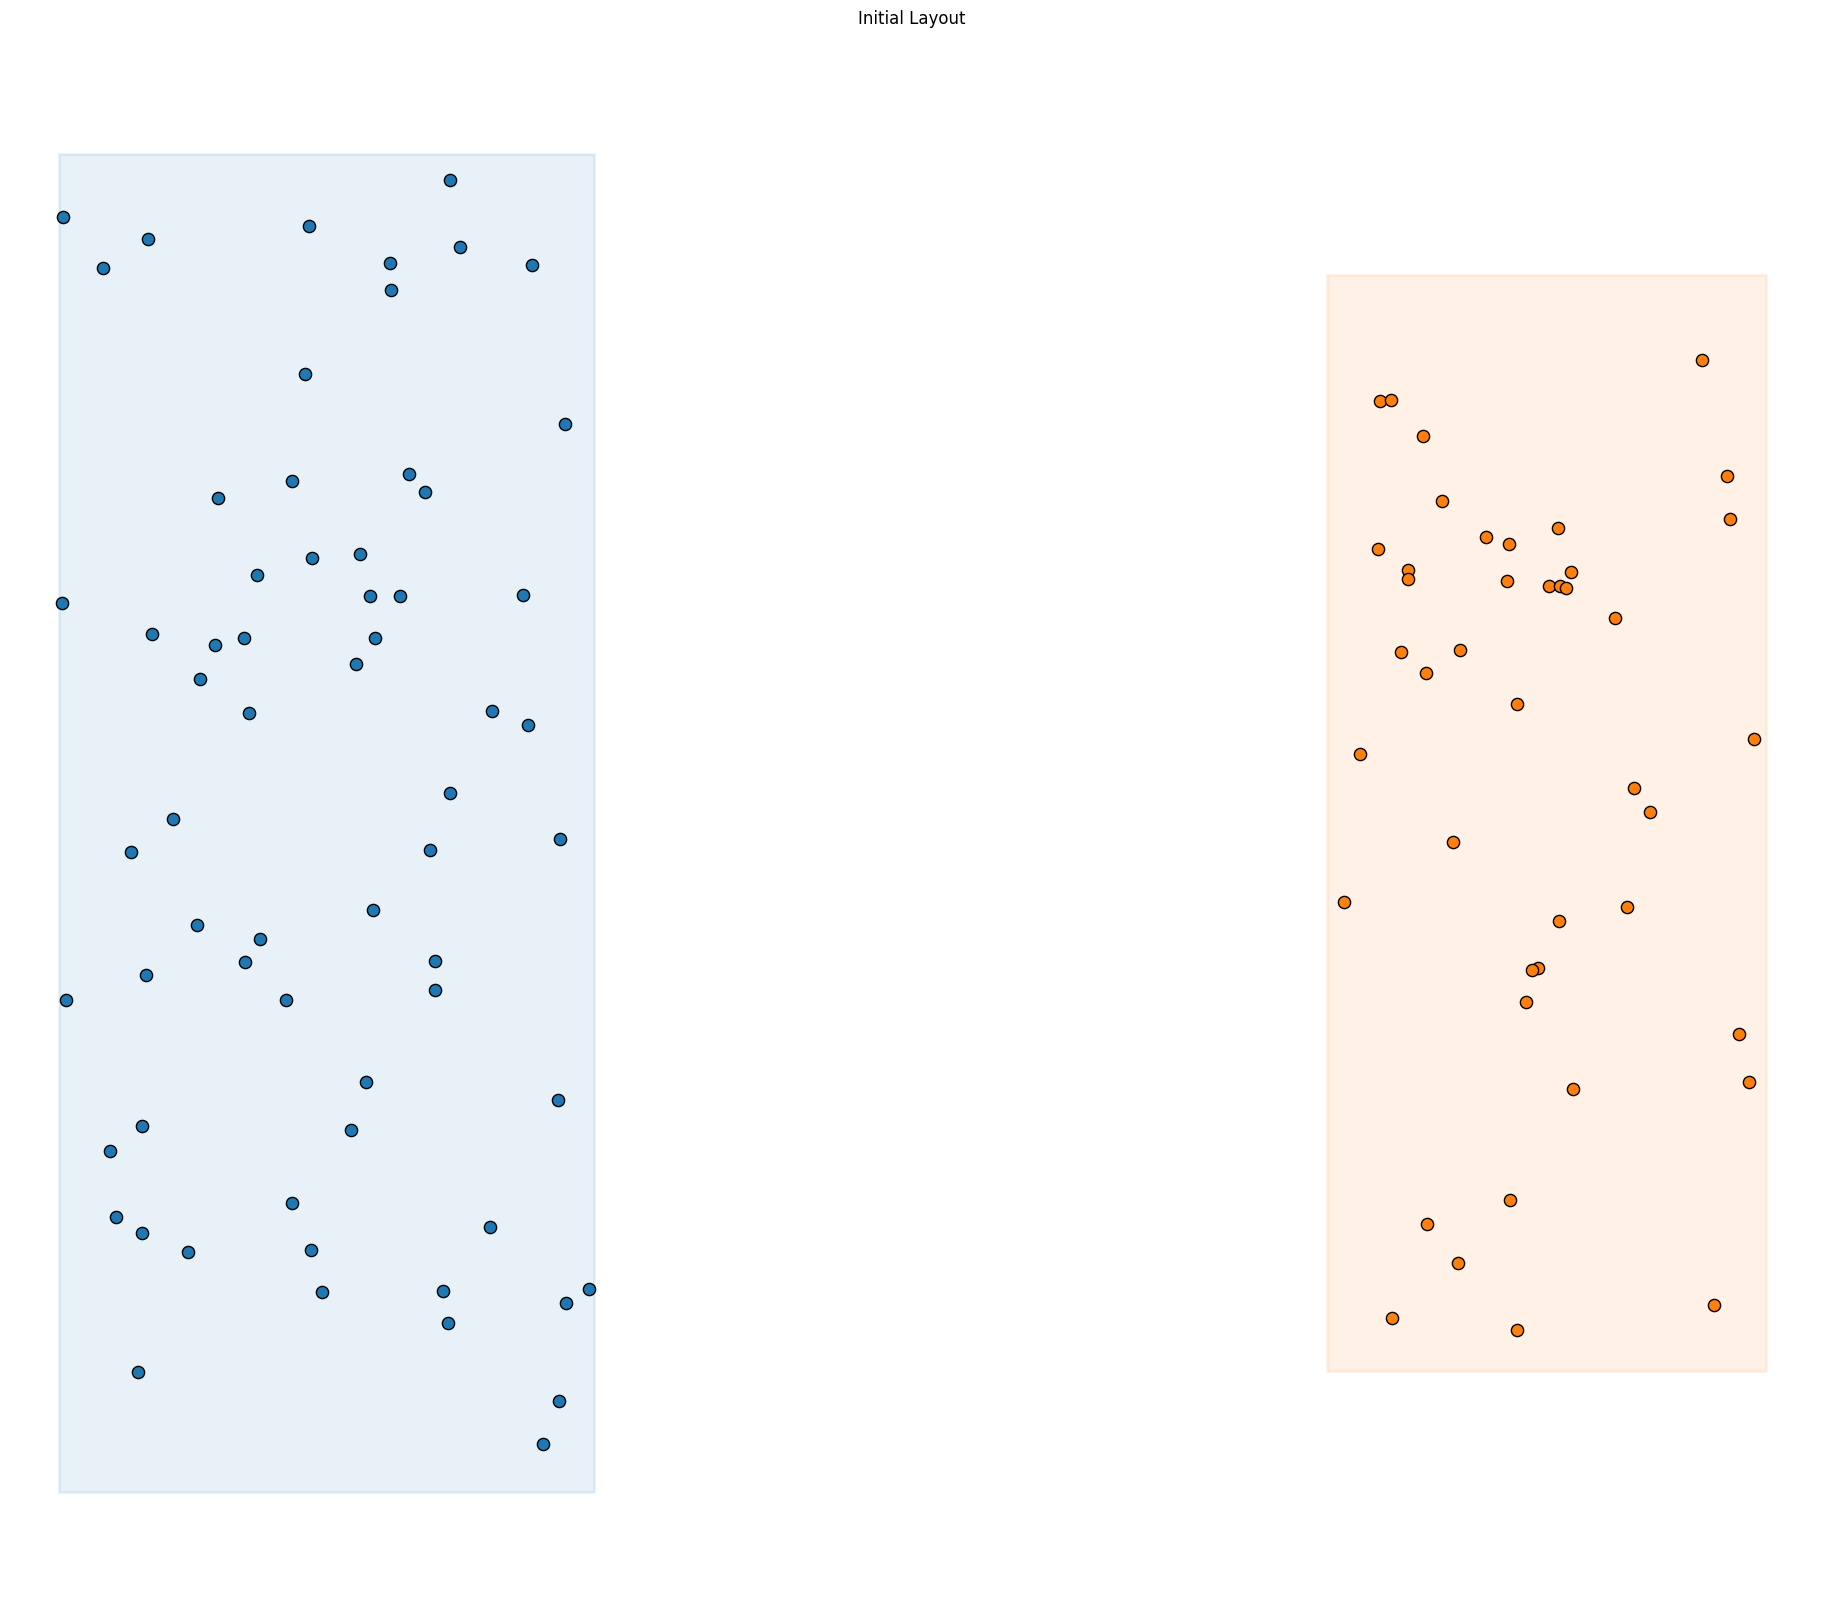

Subgraph 'Youngest Devonian Strata' converged at iteration 1 with max movement 0.000000
Subgraph 'Youngest Devonian Strata' newly converged at iteration 1
Subgraph 'Gap in the Sequence of Devonshi' converged at iteration 1 with max movement 0.000000
Subgraph 'Gap in the Sequence of Devonshi' newly converged at iteration 1


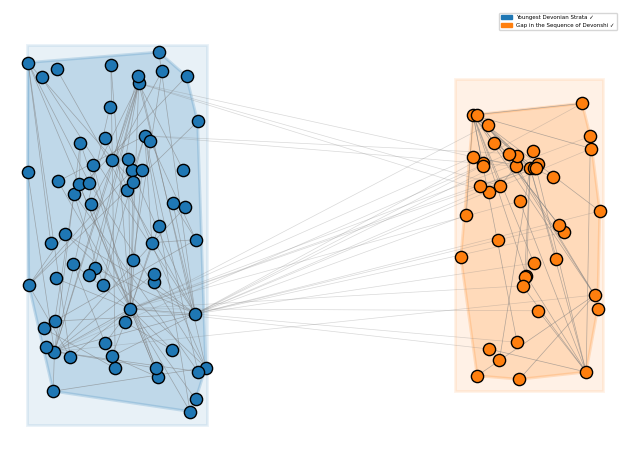

Saved final layout to devonshire_subgraphs_layout.png


<Figure size 640x480 with 0 Axes>

In [15]:
# Example usage
dot_file_path = data_name_3
subgraph_names = ["Youngest Devonian Strata", "Gap in the Sequence of Devonshi"]

# Process the DOT file and get subgraphs data
subgraphs_data = process_dot_file_for_subgraphs(dot_file_path, subgraph_names)

# array needed for further visualizations:
visualization_elements = []
# Visualize the subgraphs and get the graph and positions
G, pos, visualization_elements = draw_colorful_FDG_FR_inertia_subgraphs(
    subgraphs_data,
    output_name="devonshire_subgraphs_layout.png",
    iterations=300,
    display_node_id=False,
    save_frames=False,
    output_dir="../Output_subgraphs",
    separation_factor=2.0,
    subgraph_spacing=1.5,
    convergence_threshold=0.0005
)

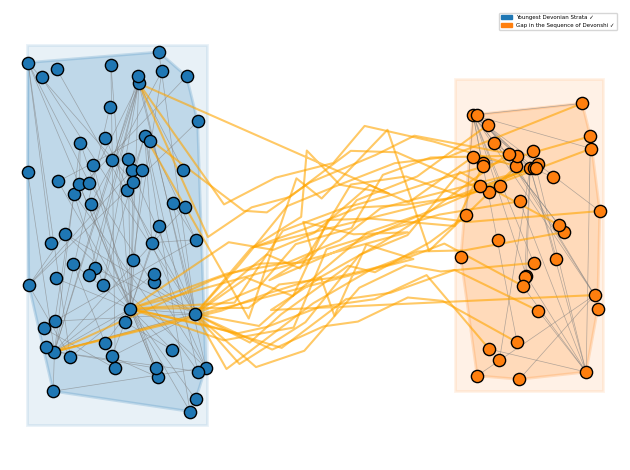

In [16]:
# Get nodes in each cluster
cluster1_nodes = [node for node, attrs in subgraphs_data['subgraphs'][subgraph_names[0]]]
cluster2_nodes = [node for node, attrs in subgraphs_data['subgraphs'][subgraph_names[1]]]
inter_cluster_edges = [(u, v) for u, v in G.edges() if (u in cluster1_nodes and v in cluster2_nodes) or (u in cluster1_nodes and v in cluster2_nodes)]
#inter_cluster_edges

# Apply FDEB to inter-cluster edges
bundled_edges = apply_fdeb_to_inter_cluster_edges(G, pos, cluster1_nodes, cluster2_nodes, P=5, S=0.1, I=50, compatibility_threshold=0.6)

# drawing: 
actual_drawing_boundled(*visualization_elements, bundled_edges)

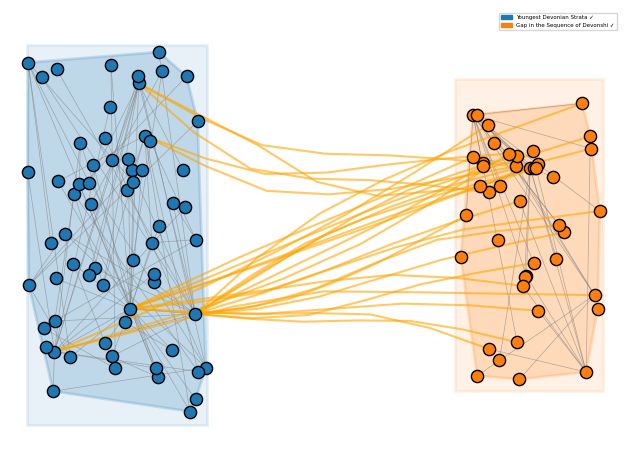

In [17]:
smoothed_bundled_edges = bundled_edges
# Apply additional smoothing to the already smoothed bundled edges
further_smoothed_edges = perform_additional_smoothing(
    smoothed_bundled_edges, 
    smooth_iterations=2, 
    kernel_width=7,  # Slightly wider kernel for second pass
    sigma=1.5        # Larger sigma for more aggressive smoothing
)

# drawing: 
actual_drawing_boundled(*visualization_elements, further_smoothed_edges)

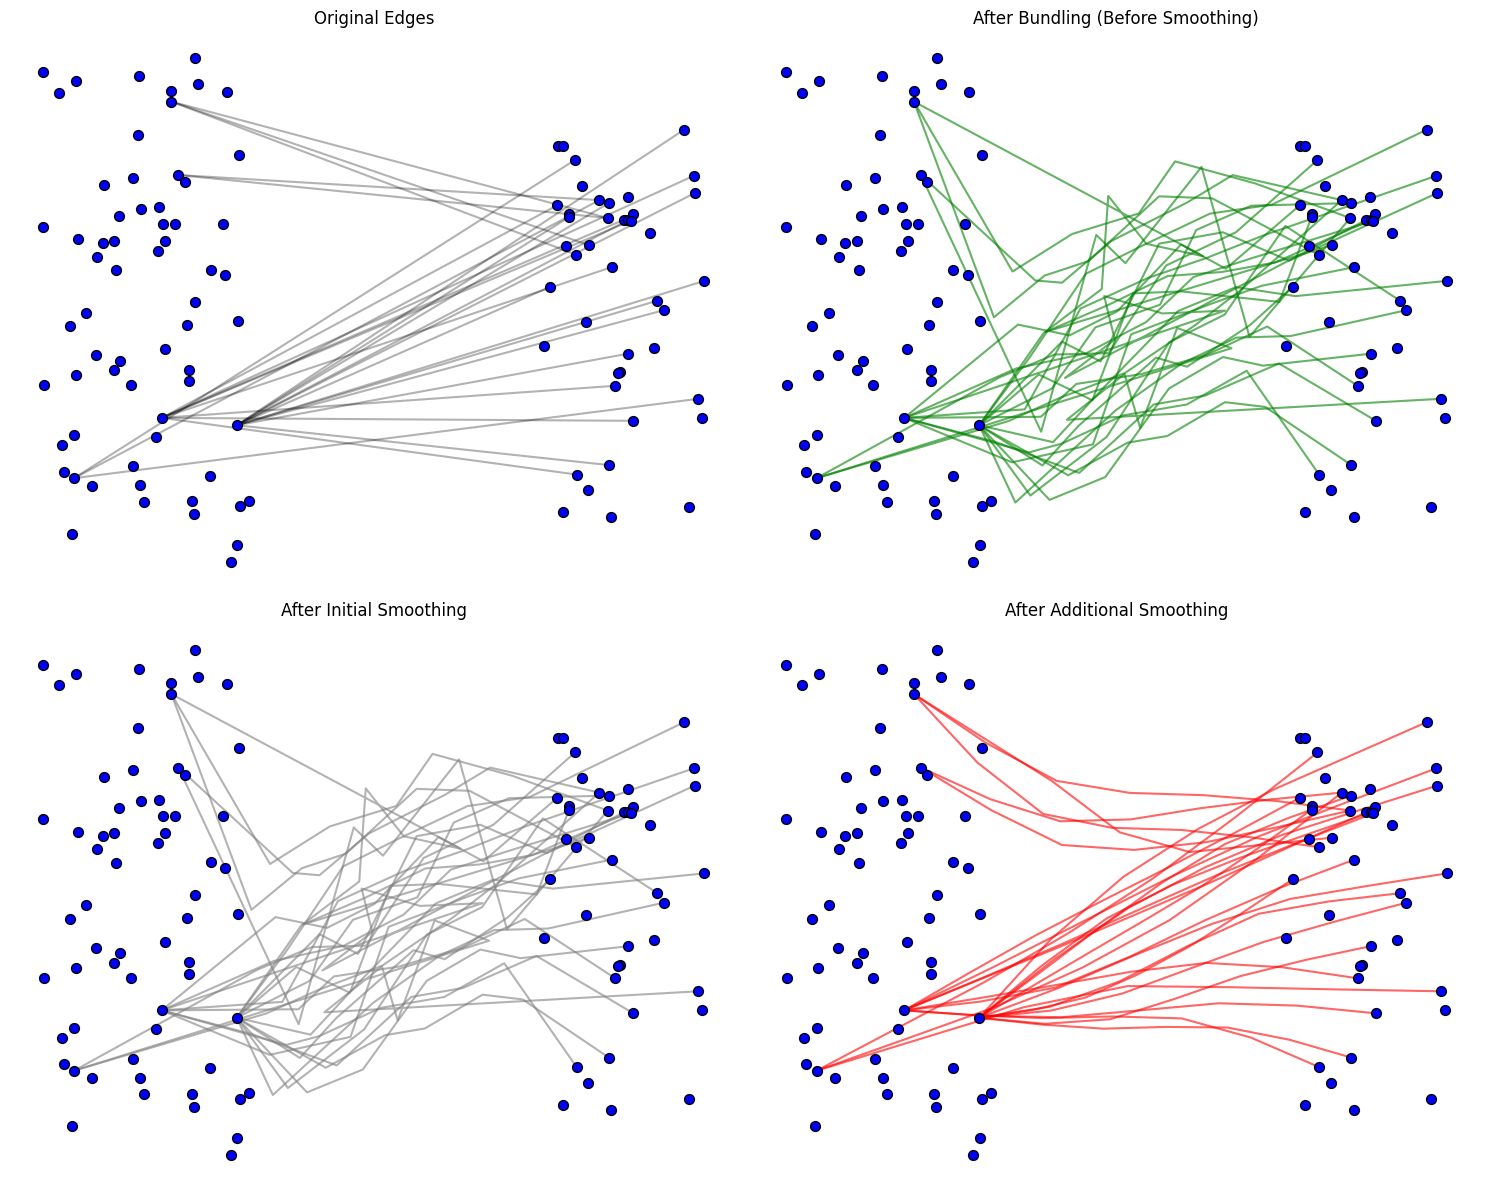

In [18]:
# Optional: Create a more detailed comparison of the smoothing progression
plt.figure(figsize=(15, 12))

# Get the original edges (before any bundling)
inter_cluster_edges = [(u, v) for u, v in G.edges() 
                      if (u in cluster1_nodes and v in cluster2_nodes) or 
                         (u in cluster2_nodes and v in cluster1_nodes)]

# Plot 1: Original edges
plt.subplot(2, 2, 1)
plt.title("Original Edges")

# Draw nodes
for node in G.nodes():
    plt.scatter(pos[node][0], pos[node][1], s=50, color='blue', edgecolor='black', zorder=2)

# Draw original edges
for u, v in inter_cluster_edges:
    plt.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color='black', alpha=0.3, zorder=1)

plt.axis('off')

# Plot 2: After bundling but before smoothing
# We need to extract the initial bundled edges without smoothing
bundled_edges_only = apply_fdeb_to_inter_cluster_edges(
    G, pos, cluster1_nodes, cluster2_nodes,
    P=5, S=0.1, I=50, compatibility_threshold=0.6
)

plt.subplot(2, 2, 2)
plt.title("After Bundling (Before Smoothing)")

# Draw nodes
for node in G.nodes():
    plt.scatter(pos[node][0], pos[node][1], s=50, color='blue', edgecolor='black', zorder=2)

# Draw bundled edges (without smoothing)
for e, control_points in bundled_edges_only.items():
    xs, ys = zip(*control_points)
    plt.plot(xs, ys, color='green', alpha=0.6, zorder=1)

plt.axis('off')

# Plot 3: After initial smoothing
plt.subplot(2, 2, 3)
plt.title("After Initial Smoothing")

# Draw nodes
for node in G.nodes():
    plt.scatter(pos[node][0], pos[node][1], s=50, color='blue', edgecolor='black', zorder=2)

# Draw initial smoothed bundled edges
for e, control_points in smoothed_bundled_edges.items():
    xs, ys = zip(*control_points)
    plt.plot(xs, ys, color='grey', alpha=0.6, zorder=1)

plt.axis('off')

# Plot 4: After additional smoothing
plt.subplot(2, 2, 4)
plt.title("After Additional Smoothing")

# Draw nodes
for node in G.nodes():
    plt.scatter(pos[node][0], pos[node][1], s=50, color='blue', edgecolor='black', zorder=2)

# Draw further smoothed bundled edges
for e, control_points in further_smoothed_edges.items():
    xs, ys = zip(*control_points)
    plt.plot(xs, ys, color='red', alpha=0.6, zorder=1)

plt.axis('off')

plt.tight_layout()
plt.show()

Applying smoothing pass 1/11 with kernel_width=3, sigma=0.8, iterations=1


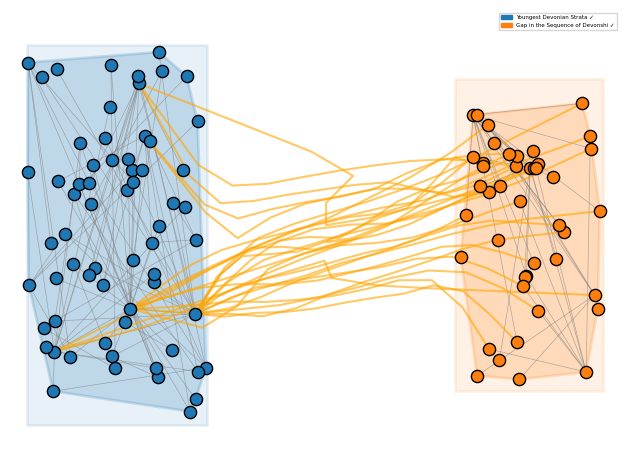

Applying smoothing pass 2/11 with kernel_width=5, sigma=1.0, iterations=1


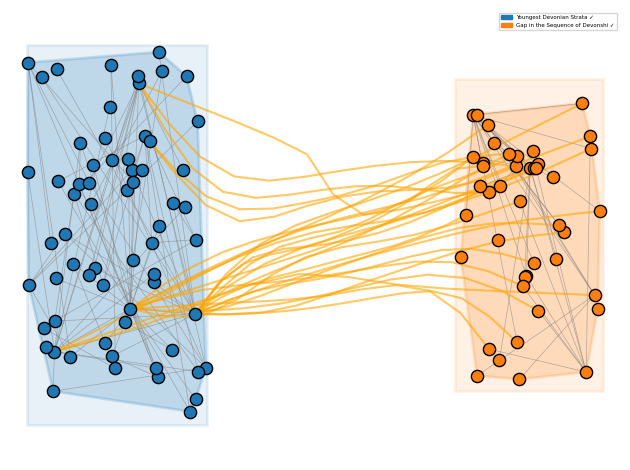

Applying smoothing pass 3/11 with kernel_width=7, sigma=1.2000000000000002, iterations=1


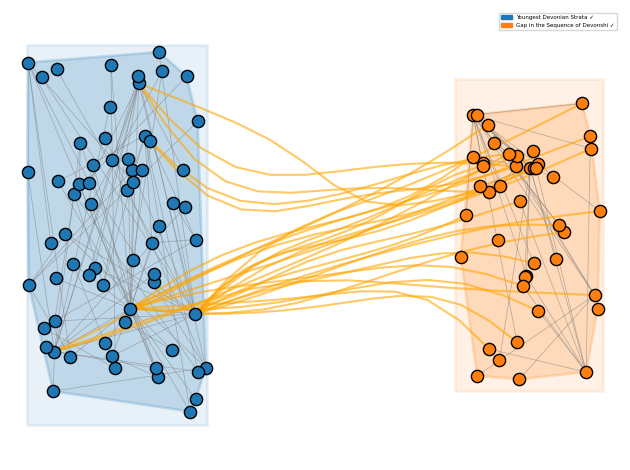

Applying smoothing pass 4/11 with kernel_width=9, sigma=1.4000000000000001, iterations=1


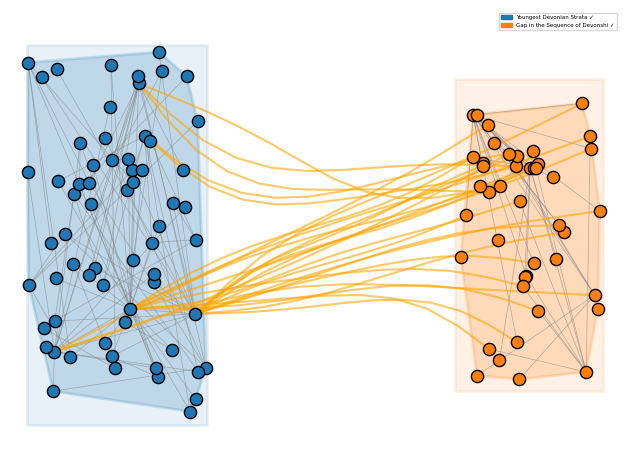

Applying smoothing pass 5/11 with kernel_width=11, sigma=1.6, iterations=1


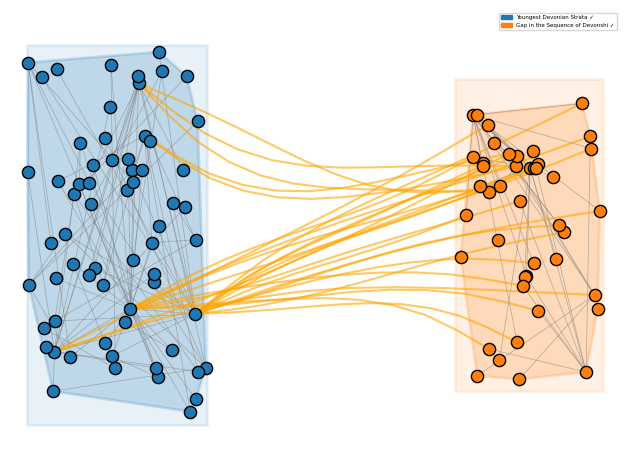

Applying smoothing pass 6/11 with kernel_width=13, sigma=1.8, iterations=1


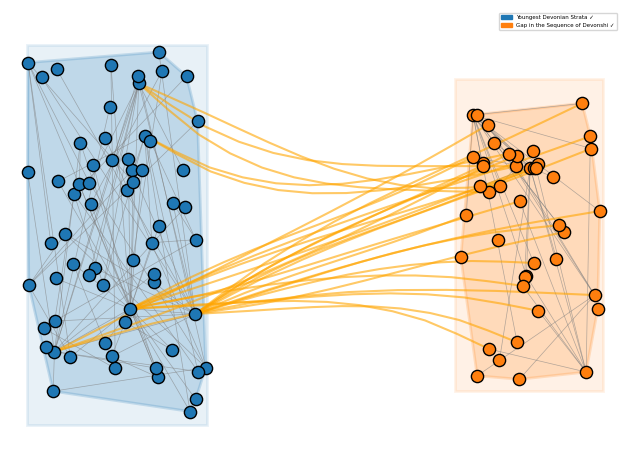

Applying smoothing pass 7/11 with kernel_width=15, sigma=2.0, iterations=1


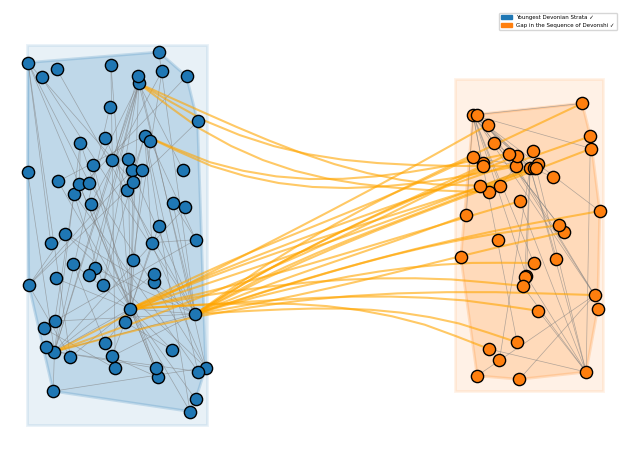

Applying smoothing pass 8/11 with kernel_width=17, sigma=2.2, iterations=1


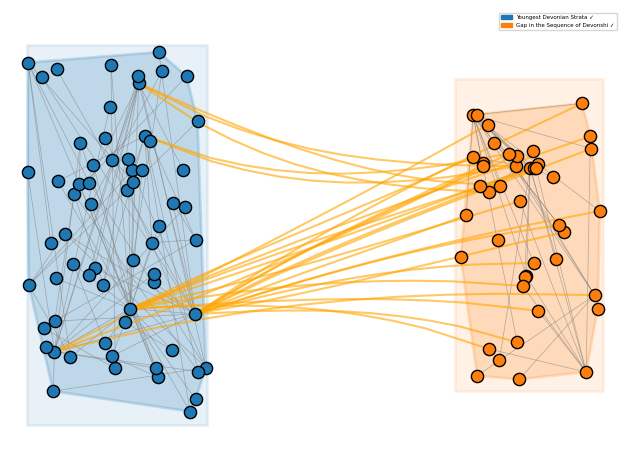

Applying smoothing pass 9/11 with kernel_width=19, sigma=2.4000000000000004, iterations=1


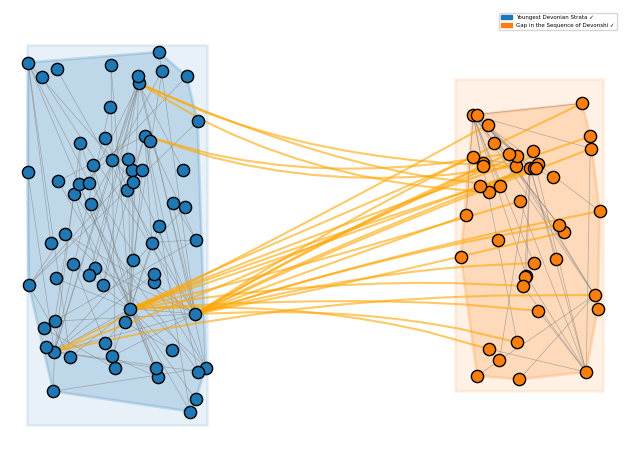

Applying smoothing pass 10/11 with kernel_width=21, sigma=2.6, iterations=1


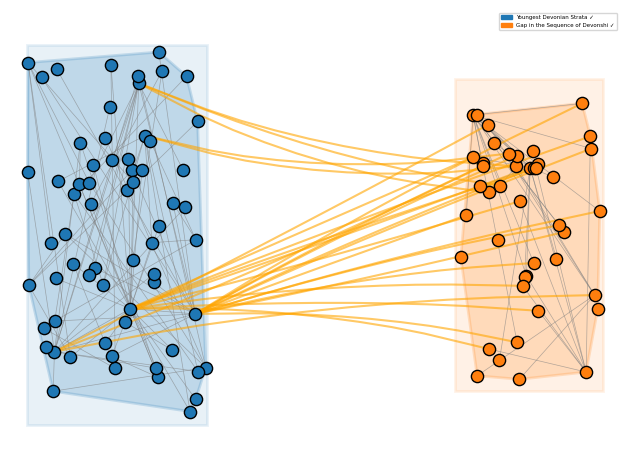

Applying smoothing pass 11/11 with kernel_width=23, sigma=2.8, iterations=1


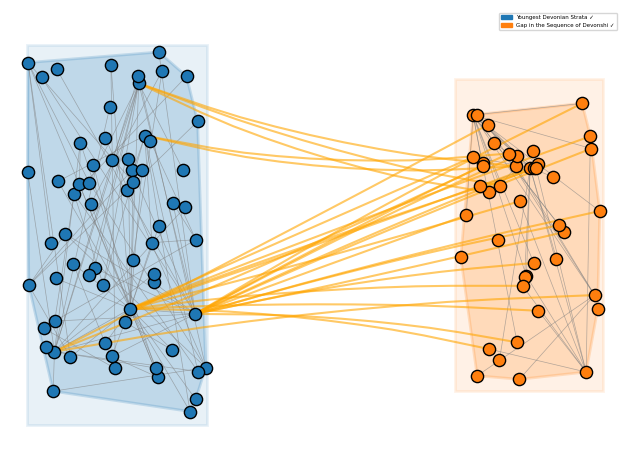

[({('n66', 'n303'): [array([3.69895298, 4.30561114]), array([7.16682892, 1.93190439]), array([6.85895994, 3.04780779]), array([7.81685737, 3.17346614]), array([8.65928724, 3.31311192]), array([9.38133519, 3.33825656]), array([10.45912894,  3.47695768]), array([11.25334956,  3.59009258]), array([11.91245933,  3.51916873]), array([12.6355085 ,  3.48323965]), array([13.39953917,  3.27004582]), array([15.31749893,  3.85001144])], ('n66', 'n332'): [array([3.69895298, 4.30561114]), array([5.89309394, 2.91566335]), array([6.55774177, 3.09491426]), array([7.43900099, 3.1837569 ]), array([8.24850228, 3.27832951]), array([9.04902298, 3.35791658]), array([10.11760496,  3.40576175]), array([10.8465569 ,  3.48617315]), array([11.62502103,  3.65781349]), array([12.47971881,  3.94020412]), array([13.40624257,  4.03354107]), array([15.09043112,  4.0397275 ])], ('n152', 'n144'): [array([15.75797128,  3.83184238]), array([8.92417377, 2.50843045]), array([9.02370986, 2.6058428 ]), array([9.30658656, 2.67

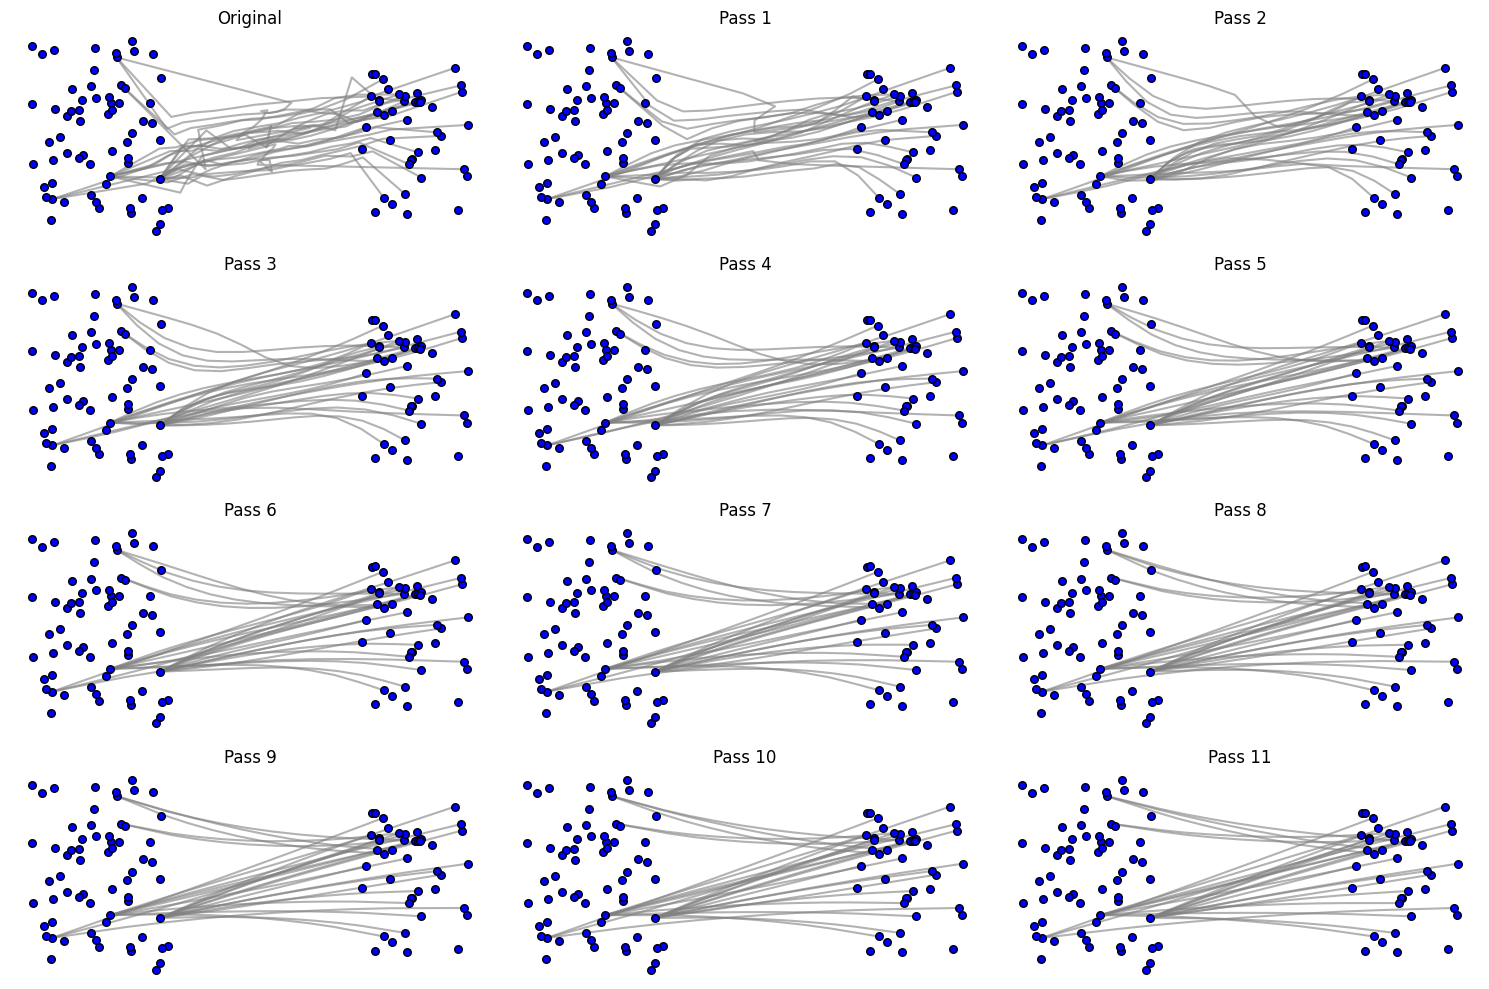

In [19]:
# Define the number of iterations
num_iterations = 11  # User-defined number of times the smoothing takes place

# setting the parameters for the smoothings passes:
#fdeb_params = {'P': 10, 'S': 0.1, 'I': 50, 'compatibility_threshold': 0.6}
fdeb_params = {'P': 10, 'S': 0.03, 'I': 15, 'compatibility_threshold': 0.06}

"""
parameters meaning:
- P: number of control points per edge
- S: spring constant
- I: number of iterations for force-directed edge bundling to take place
- compatibility_threshold: threshold for edge compatibility
"""

# Call the edge smoothing function
final_smoothed_edges = edge_smoothing_with_iterations(
    G, pos, cluster1_nodes, cluster2_nodes, iterations=num_iterations, fdeb_params=fdeb_params
)

## step 6

### distance matrix e preparation for DR algorithms

Graph is undirected
Number of nodes: 198
Original Number of Edges:  2742 
 -- after doubling edges -- 
Number of edges: 5484


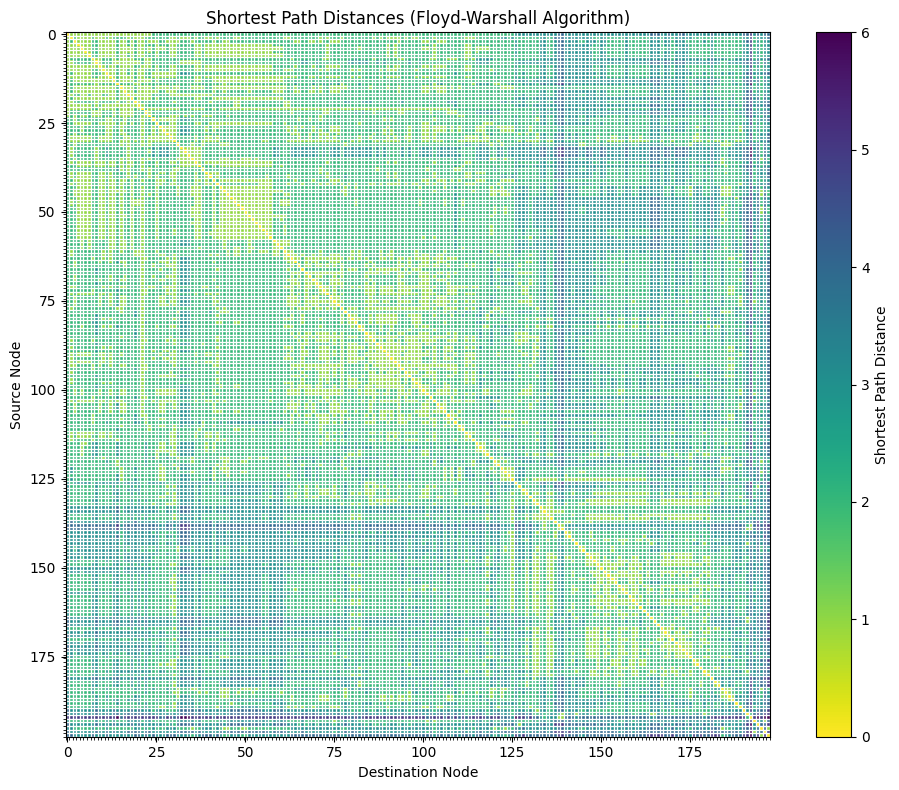

In [20]:
nodes_dict, edges_dict, nodes, edges = data_processing(data_name_1)
distance_matrix, node_ids = floyd_warshall(nodes_dict, edges_dict)
fig, ax = plot_coloured_distance_matrix(distance_matrix, node_ids)
plt.show()

In [21]:
# Convert the distance matrix to a NumPy array (for t-SNE and ISOMAP) and creates a folder to store the projections
distance_matrix_np = np.array(distance_matrix)

output_dir = folder_for_projections(file_name)

Created main directory: c:\Users\Hari\Desktop\dataVisproj\Data-Visualization-CurryPasta\Step6_outputs-LesMiserables.dot
Created directory: c:\Users\Hari\Desktop\dataVisproj\Data-Visualization-CurryPasta\Step6_outputs-LesMiserables.dot\MDS
Created directory: c:\Users\Hari\Desktop\dataVisproj\Data-Visualization-CurryPasta\Step6_outputs-LesMiserables.dot\tSNE
Created directory: c:\Users\Hari\Desktop\dataVisproj\Data-Visualization-CurryPasta\Step6_outputs-LesMiserables.dot\ISOMAP
Created directory: c:\Users\Hari\Desktop\dataVisproj\Data-Visualization-CurryPasta\Step6_outputs-LesMiserables.dot\ISOMAP\2D
Created directory: c:\Users\Hari\Desktop\dataVisproj\Data-Visualization-CurryPasta\Step6_outputs-LesMiserables.dot\ISOMAP\3D


### mds

Dimesnion of X after MDS =  (198, 2)


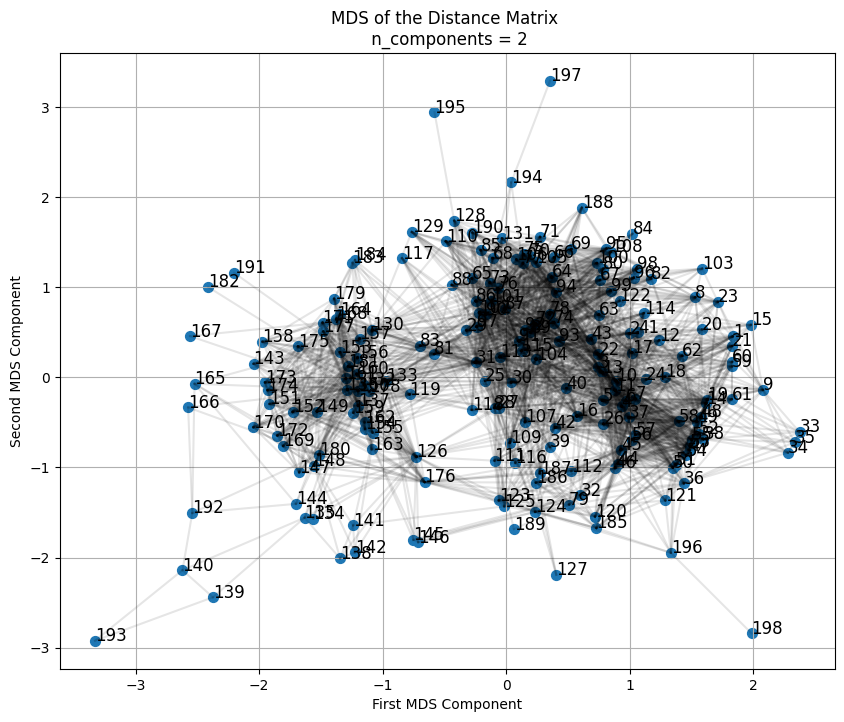

Plot saved as: c:\Users\Hari\Desktop\dataVisproj\Data-Visualization-CurryPasta\Step6_outputs-LesMiserables.dot\MDS/mds_visualization_1.png


In [22]:
mds_distance_matrix_reduced = mds_2d_projection(distance_matrix, node_ids, edges, output_dir)

### t-sne

In [23]:
# Define the perplexity range based on the number of nodes
lower = max(2, int(0.05 * len(node_ids))) # 5%
upper = max(3, int(0.10 * len(node_ids))) # 10%

print(f"Adviced perplexity range: {lower} to {upper}")

Adviced perplexity range: 9 to 19


Dimesnion of X after t-SNE =  (198, 2)


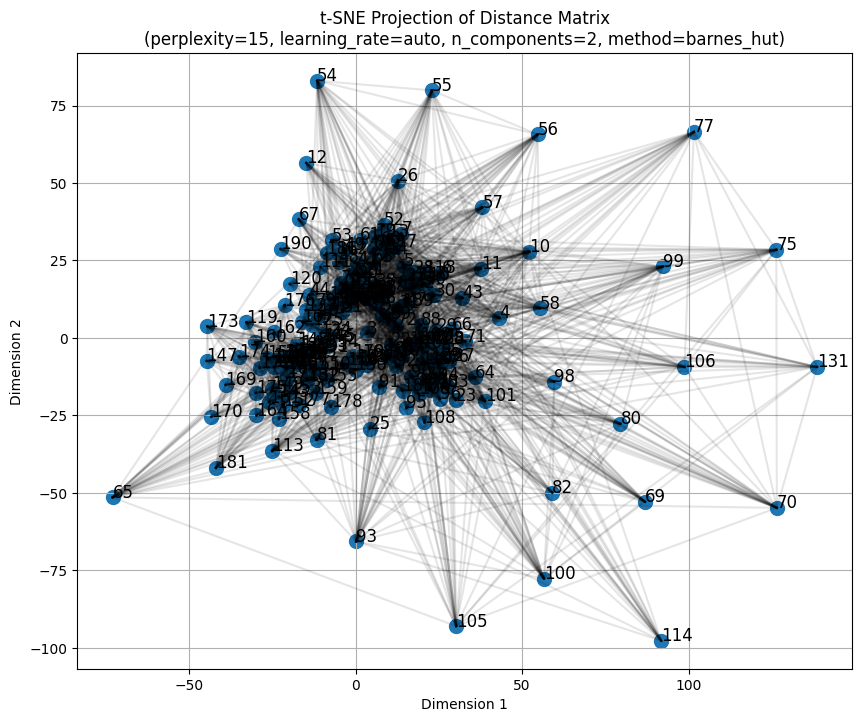

Plot saved as: c:\Users\Hari\Desktop\dataVisproj\Data-Visualization-CurryPasta\Step6_outputs-LesMiserables.dot\tSNE/tsne_visualization_1.png


In [24]:
tsne_distance_matrix_reduced = tsne_2d_projection(distance_matrix_np, node_ids, edges, output_dir, perplexity=15, angle=0.5)

### isomap

#### 2D

Dimension of X after Isomap = (198, 2)


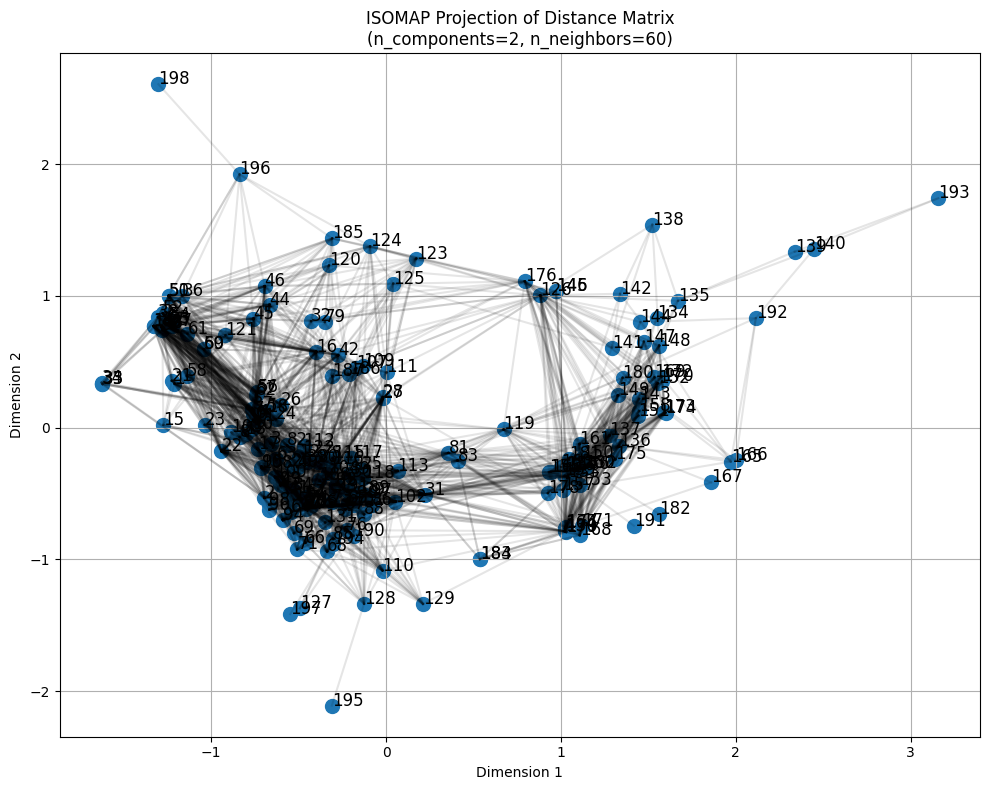

Plot saved in 2D folder as: c:\Users\Hari\Desktop\dataVisproj\Data-Visualization-CurryPasta\Step6_outputs-LesMiserables.dot\ISOMAP/2D/ISOMAP_visualization_1_comp2_neigh60.png


In [25]:
isomap_distance_matrix_reduced_2d = isomap_2d_projection(distance_matrix_np, node_ids, edges, output_dir, n_neighbors=60)

#### 3D

Dimension of X after Isomap = (198, 3)


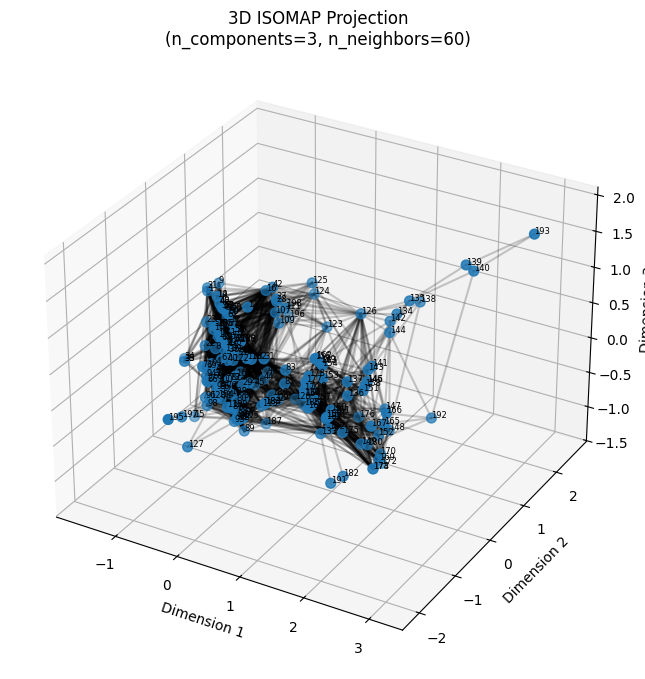

3D plot saved as: c:\Users\Hari\Desktop\dataVisproj\Data-Visualization-CurryPasta\Step6_outputs-LesMiserables.dot\ISOMAP/3D/ISOMAP_3D_1_comp3_neigh60.png


In [26]:
isomap_distance_matrix_reduced_3d = isomap_3d_projection(distance_matrix_np, node_ids, edges, output_dir, n_neighbors=60)

## step 7 <- run step 6 before

### DR Projections quality metrics

#### Normalized stress

In [27]:
# MDS
mds_stress = normalized_stress(distance_matrix_np, mds_distance_matrix_reduced)
print(f"Normalized Stress for MDS: {mds_stress:.4f}")

# t-SNE
tsne_stress = normalized_stress(distance_matrix_np, tsne_distance_matrix_reduced)
print(f"Normalized Stress for t-SNE: {tsne_stress:.4f}")

# isomap 2D
isomap_stress = normalized_stress(distance_matrix_np, isomap_distance_matrix_reduced_2d)
print(f"Normalized Stress for t-SNE: {isomap_stress:.4f}")

Normalized Stress for MDS: 0.7116
Normalized Stress for t-SNE: 11.0713
Normalized Stress for t-SNE: 0.7805


#### Shepard diagram

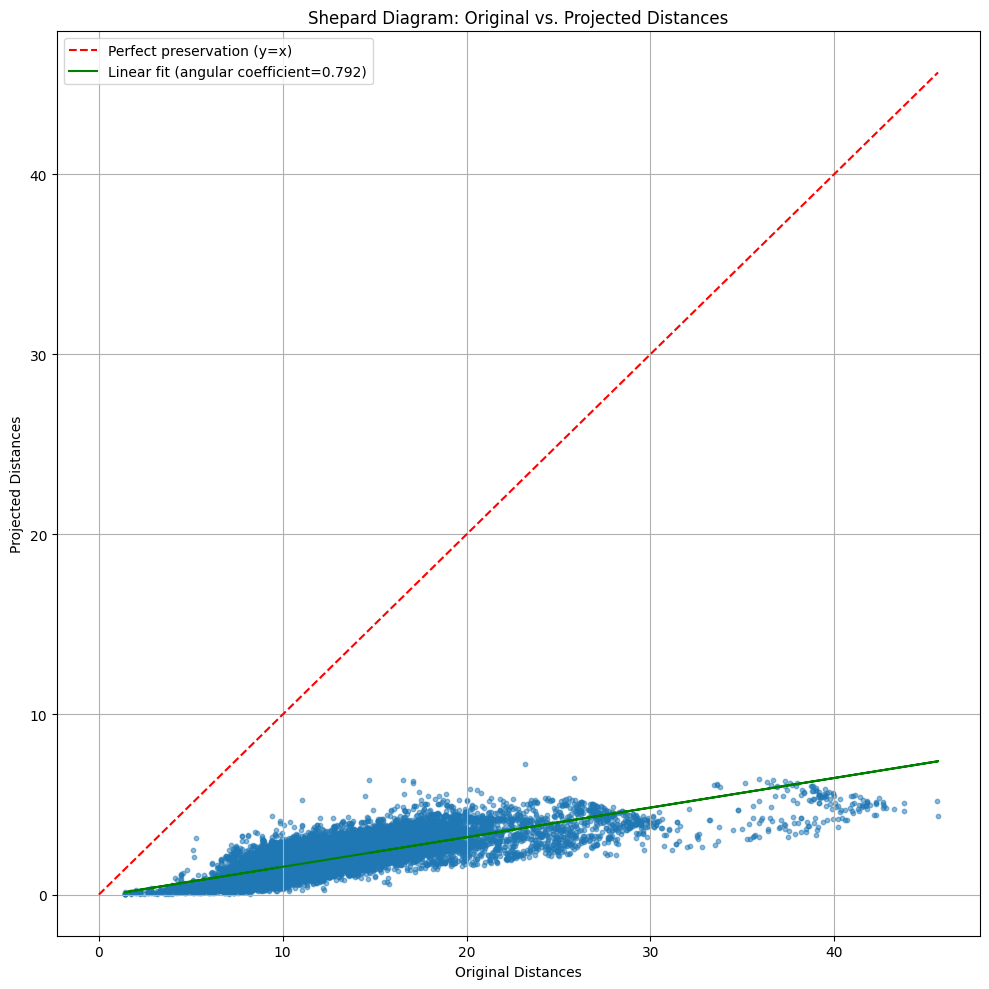

In [28]:
# MDS
fig, ax = plot_shepard_diagram(distance_matrix_np, mds_distance_matrix_reduced)
plt.show()

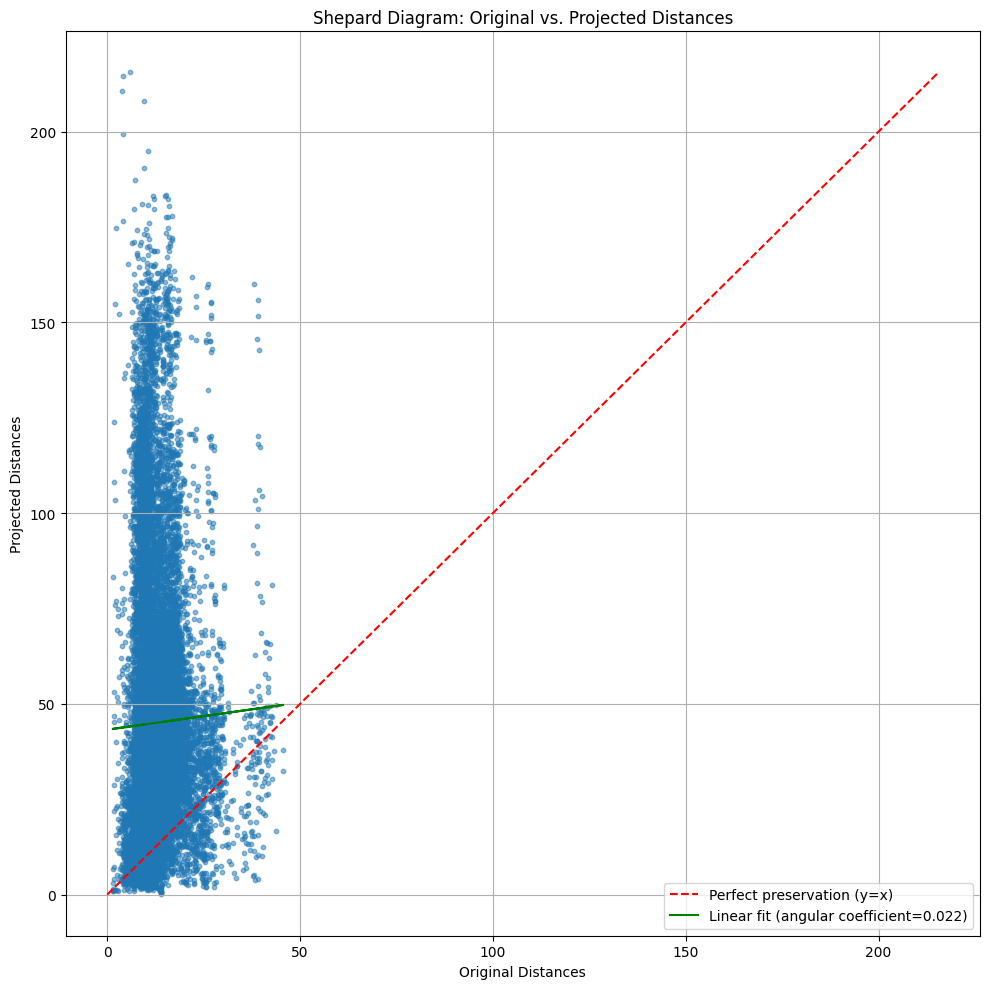

In [29]:
# t-SNE
fig, ax = plot_shepard_diagram(distance_matrix_np, tsne_distance_matrix_reduced)
plt.show()

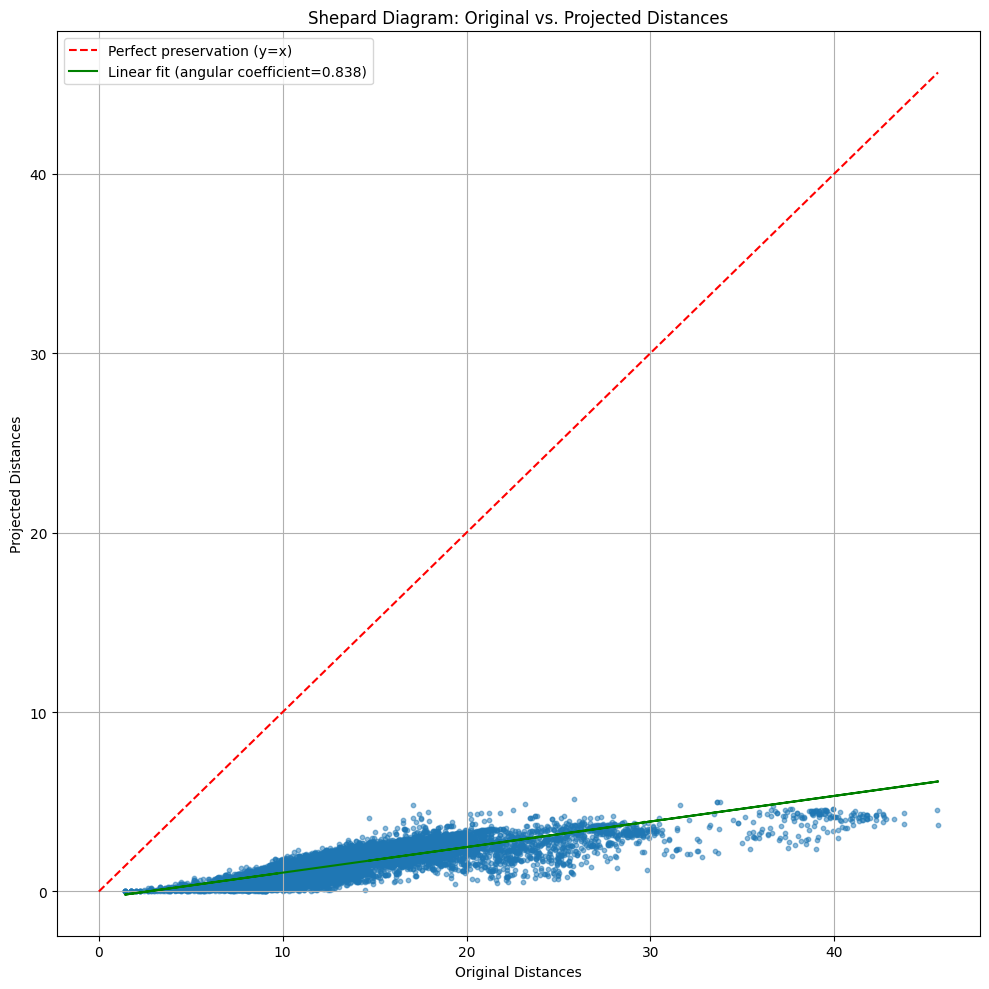

In [30]:
# isomap 2D
fig, ax = plot_shepard_diagram(distance_matrix_np, isomap_distance_matrix_reduced_2d)
plt.show()

#### Trustworthiness

In [31]:
# MDS
trust_score_MDS = trustworthiness(distance_matrix_np, mds_distance_matrix_reduced, n_neighbors=10)
print(f"Trustworthiness score of MDS: {trust_score_MDS:.4f}")

# t-SNE
trust_score_tsne = trustworthiness(distance_matrix_np, tsne_distance_matrix_reduced, n_neighbors=10)
print(f"Trustworthiness score of t-SNE: {trust_score_tsne:.4f}")

# isomap 2D
trust_score_isomap = trustworthiness(distance_matrix_np, isomap_distance_matrix_reduced_2d, n_neighbors=10)
print(f"Trustworthiness score of ISOMAP: {trust_score_isomap:.4f}")

Trustworthiness score of MDS: 0.9776
Trustworthiness score of t-SNE: 0.8332
Trustworthiness score of ISOMAP: 0.9451


#### Continuity

In [32]:
# MDS
cont_score_MDS = continuity(distance_matrix_np, mds_distance_matrix_reduced, n_neighbors=10)
print(f"Continuity score of MDS: {trust_score_MDS:.4f}")

# t-SNE
cont_score_tsne = continuity(distance_matrix_np, tsne_distance_matrix_reduced, n_neighbors=10)
print(f"Continuity score of t-SNE: {trust_score_tsne:.4f}")

# isomap 2D
cont_score_isomap = continuity(distance_matrix_np, isomap_distance_matrix_reduced_2d, n_neighbors=10)
print(f"Continuity score of ISOMAP: {cont_score_isomap:.4f}")

Continuity score of MDS: 0.9776
Continuity score of t-SNE: 0.8332
Continuity score of ISOMAP: 0.9666


### Other graph related quality metrics